In [1]:
!pip install yfinance

  Using cached yfinance-0.2.66-py2.py3-none-any.whl.metadata (6.0 kB)
  Using cached multitasking-0.0.12-py3-none-any.whl
  Using cached peewee-3.18.3-cp311-cp311-linux_x86_64.whl
  Using cached curl_cffi-0.13.0-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
Using cached yfinance-0.2.66-py2.py3-none-any.whl (123 kB)
Using cached curl_cffi-0.13.0-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (8.3 MB)


In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import requests

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

In [3]:
text = """
Symbol	Security	GICS Sector	GICS Sub-Industry	Headquarters Location	Date added	CIK	Founded
MMM	3M	Industrials	Industrial Conglomerates	Saint Paul, Minnesota	1957-03-04	0000066740	1902
AOS	A. O. Smith	Industrials	Building Products	Milwaukee, Wisconsin	2017-07-26	0000091142	1916
ABT	Abbott Laboratories	Health Care	Health Care Equipment	North Chicago, Illinois	1957-03-04	0000001800	1888
ABBV	AbbVie	Health Care	Biotechnology	North Chicago, Illinois	2012-12-31	0001551152	2013 (1888)
ACN	Accenture	Information Technology	IT Consulting & Other Services	Dublin, Ireland	2011-07-06	0001467373	1989
ADBE	Adobe Inc.	Information Technology	Application Software	San Jose, California	1997-05-05	0000796343	1982
AMD	Advanced Micro Devices	Information Technology	Semiconductors	Santa Clara, California	2017-03-20	0000002488	1969
AES	AES Corporation	Utilities	Independent Power Producers & Energy Traders	Arlington, Virginia	1998-10-02	0000874761	1981
AFL	Aflac	Financials	Life & Health Insurance	Columbus, Georgia	1999-05-28	0000004977	1955
A	Agilent Technologies	Health Care	Life Sciences Tools & Services	Santa Clara, California	2000-06-05	0001090872	1999
APD	Air Products	Materials	Industrial Gases	Upper Macungie Township, Pennsylvania	1985-04-30	0000002969	1940
ABNB	Airbnb	Consumer Discretionary	Hotels, Resorts & Cruise Lines	San Francisco, California	2023-09-18	0001559720	2008
AKAM	Akamai Technologies	Information Technology	Internet Services & Infrastructure	Cambridge, Massachusetts	2007-07-12	0001086222	1998
ALB	Albemarle Corporation	Materials	Specialty Chemicals	Charlotte, North Carolina	2016-07-01	0000915913	1994
ARE	Alexandria Real Estate Equities	Real Estate	Office REITs	Pasadena, California	2017-03-20	0001035443	1994
ALGN	Align Technology	Health Care	Health Care Supplies	Tempe, Arizona	2017-06-19	0001097149	1997
ALLE	Allegion	Industrials	Building Products	Dublin, Ireland	2013-12-02	0001579241	1908
LNT	Alliant Energy	Utilities	Electric Utilities	Madison, Wisconsin	2016-07-01	0000352541	1917
ALL	Allstate	Financials	Property & Casualty Insurance	Northbrook, Illinois	1995-07-13	0000899051	1931
GOOGL	Alphabet Inc. (Class A)	Communication Services	Interactive Media & Services	Mountain View, California	2006-04-03	0001652044	1998
GOOG	Alphabet Inc. (Class C)	Communication Services	Interactive Media & Services	Mountain View, California	2014-04-03	0001652044	1998
MO	Altria	Consumer Staples	Tobacco	Richmond, Virginia	1957-03-04	0000764180	1985
AMZN	Amazon	Consumer Discretionary	Broadline Retail	Seattle, Washington	2005-11-18	0001018724	1994
AMCR	Amcor	Materials	Paper & Plastic Packaging Products & Materials	Warmley, Bristol, United Kingdom	2019-06-07	0001748790	2019 (1860)
AEE	Ameren	Utilities	Multi-Utilities	St. Louis, Missouri	1991-09-19	0001002910	1902
AEP	American Electric Power	Utilities	Electric Utilities	Columbus, Ohio	1957-03-04	0000004904	1906
AXP	American Express	Financials	Consumer Finance	New York City, New York	1976-06-30	0000004962	1850
AIG	American International Group	Financials	Multi-line Insurance	New York City, New York	1980-03-31	0000005272	1919
AMT	American Tower	Real Estate	Telecom Tower REITs	Boston, Massachusetts	2007-11-19	0001053507	1995
AWK	American Water Works	Utilities	Water Utilities	Camden, New Jersey	2016-03-04	0001410636	1886
AMP	Ameriprise Financial	Financials	Asset Management & Custody Banks	Minneapolis, Minnesota	2005-10-03	0000820027	1894
AME	Ametek	Industrials	Electrical Components & Equipment	Berwyn, Pennsylvania	2013-09-23	0001037868	1930
AMGN	Amgen	Health Care	Biotechnology	Thousand Oaks, California	1992-01-02	0000318154	1980
APH	Amphenol	Information Technology	Electronic Components	Wallingford, Connecticut	2008-09-30	0000820313	1932
ADI	Analog Devices	Information Technology	Semiconductors	Wilmington, Massachusetts	1999-10-12	0000006281	1965
AON	Aon plc	Financials	Insurance Brokers	London, United Kingdom	1996-04-23	0000315293	1982 (1919)
APA	APA Corporation	Energy	Oil & Gas Exploration & Production	Houston, Texas	1997-07-28	0001841666	1954
APO	Apollo Global Management	Financials	Asset Management & Custody Banks	New York City, New York	2024-12-23	0001858681	1990
AAPL	Apple Inc.	Information Technology	Technology Hardware, Storage & Peripherals	Cupertino, California	1982-11-30	0000320193	1977
AMAT	Applied Materials	Information Technology	Semiconductor Materials & Equipment	Santa Clara, California	1995-03-16	0000006951	1967
APP	AppLovin	Information Technology	Application Software	Palo Alto, California	2025-09-22	0001751008	2012
APTV	Aptiv	Consumer Discretionary	Automotive Parts & Equipment	Dublin, Ireland	2012-12-24	0001521332	1994
ACGL	Arch Capital Group	Financials	Property & Casualty Insurance	Hamilton, Bermuda	2022-11-01	0000947484	1995
ADM	Archer Daniels Midland	Consumer Staples	Agricultural Products & Services	Chicago, Illinois	1957-03-04	0000007084	1902
ANET	Arista Networks	Information Technology	Communications Equipment	Santa Clara, California	2018-08-28	0001596532	2004
AJG	Arthur J. Gallagher & Co.	Financials	Insurance Brokers	Rolling Meadows, Illinois	2016-05-31	0000354190	1927
AIZ	Assurant	Financials	Multi-line Insurance	Atlanta, Georgia	2007-04-10	0001267238	1892
T	AT&T	Communication Services	Integrated Telecommunication Services	Dallas, Texas	1983-11-30	0000732717	1983 (1885)
ATO	Atmos Energy	Utilities	Gas Utilities	Dallas, Texas	2019-02-15	0000731802	1906
ADSK	Autodesk	Information Technology	Application Software	San Francisco, California	1989-12-01	0000769397	1982
ADP	Automatic Data Processing	Industrials	Human Resource & Employment Services	Roseland, New Jersey	1981-03-31	0000008670	1949
AZO	AutoZone	Consumer Discretionary	Automotive Retail	Memphis, Tennessee	1997-01-02	0000866787	1979
AVB	AvalonBay Communities	Real Estate	Multi-Family Residential REITs	Arlington, Virginia	2007-01-10	0000915912	1978
AVY	Avery Dennison	Materials	Paper & Plastic Packaging Products & Materials	Mentor, Ohio	1987-12-31	0000008818	1935
AXON	Axon Enterprise	Industrials	Aerospace & Defense	Scottsdale, Arizona	2023-05-04	0001069183	1993
BKR	Baker Hughes	Energy	Oil & Gas Equipment & Services	Houston, Texas	2017-07-07	0001701605	2017
BALL	Ball Corporation	Materials	Metal, Glass & Plastic Containers	Broomfield, Colorado	1984-10-31	0000009389	1880
BAC	Bank of America	Financials	Diversified Banks	Charlotte, North Carolina	1976-06-30	0000070858	1998 (1923 / 1874)
BAX	Baxter International	Health Care	Health Care Equipment	Deerfield, Illinois	1972-09-30	0000010456	1931
BDX	Becton Dickinson	Health Care	Health Care Equipment	Franklin Lakes, New Jersey	1972-09-30	0000010795	1897
BRK.B	Berkshire Hathaway	Financials	Multi-Sector Holdings	Omaha, Nebraska	2010-02-16	0001067983	1839
BBY	Best Buy	Consumer Discretionary	Computer & Electronics Retail	Richfield, Minnesota	1999-06-29	0000764478	1966
TECH	Bio-Techne	Health Care	Life Sciences Tools & Services	Minneapolis, Minnesota	2021-08-30	0000842023	1976
BIIB	Biogen	Health Care	Biotechnology	Cambridge, Massachusetts	2003-11-13	0000875045	1978
BLK	BlackRock	Financials	Asset Management & Custody Banks	New York City, New York	2011-04-04	0002012383	1988
BX	Blackstone Inc.	Financials	Asset Management & Custody Banks	New York City, New York	2023-09-18	0001393818	1985
XYZ	Block, Inc.	Financials	Transaction & Payment Processing Services	none	2025-07-23	0001512673	2009
BK	BNY Mellon	Financials	Asset Management & Custody Banks	New York City, New York	1995-03-31	0001390777	1784
BA	Boeing	Industrials	Aerospace & Defense	Arlington, Virginia	1957-03-04	0000012927	1916
BKNG	Booking Holdings	Consumer Discretionary	Hotels, Resorts & Cruise Lines	Norwalk, Connecticut	2009-11-06	0001075531	1996
BSX	Boston Scientific	Health Care	Health Care Equipment	Marlborough, Massachusetts	1995-02-24	0000885725	1979
BMY	Bristol Myers Squibb	Health Care	Pharmaceuticals	New York City, New York	1957-03-04	0000014272	1989 (1887)
AVGO	Broadcom	Information Technology	Semiconductors	Palo Alto, California	2014-05-08	0001730168	1961
BR	Broadridge Financial Solutions	Industrials	Data Processing & Outsourced Services	Lake Success, New York	2018-06-18	0001383312	1962
BRO	Brown & Brown	Financials	Insurance Brokers	Daytona Beach, Florida	2021-09-20	0000079282	1939
BF.B	Brown–Forman	Consumer Staples	Distillers & Vintners	Louisville, Kentucky	1982-10-31	0000014693	1870
BLDR	Builders FirstSource	Industrials	Building Products	Irving, Texas	2023-12-18	0001316835	1998
BG	Bunge Global	Consumer Staples	Agricultural Products & Services	Chesterfield, Missouri	2023-03-15	0001996862	1818
BXP	BXP, Inc.	Real Estate	Office REITs	Boston, Massachusetts	2006-04-03	0001037540	1970
CHRW	C.H. Robinson	Industrials	Air Freight & Logistics	Eden Prairie, Minnesota	2007-03-02	0001043277	1905
CDNS	Cadence Design Systems	Information Technology	Application Software	San Jose, California	2017-09-18	0000813672	1988
CPT	Camden Property Trust	Real Estate	Multi-Family Residential REITs	Houston, Texas	2022-04-04	0000906345	1981
CPB	Campbell's Company (The)	Consumer Staples	Packaged Foods & Meats	Camden, New Jersey	1957-03-04	0000016732	1869
COF	Capital One	Financials	Consumer Finance	Tysons Corner, Virginia	1998-07-01	0000927628	1994
CAH	Cardinal Health	Health Care	Health Care Distributors	Dublin, Ohio	1997-05-27	0000721371	1971
CCL	Carnival	Consumer Discretionary	Hotels, Resorts & Cruise Lines	Miami, Florida	1998-12-22	0000815097	1972
CARR	Carrier Global	Industrials	Building Products	Palm Beach Gardens, Florida	2020-04-03	0001783180	2020 (1915, United Technologies spinoff)
CAT	Caterpillar Inc.	Industrials	Construction Machinery & Heavy Transportation Equipment	Irving, Texas	1957-03-04	0000018230	1925
CBOE	Cboe Global Markets	Financials	Financial Exchanges & Data	Chicago, Illinois	2017-03-01	0001374310	1973
CBRE	CBRE Group	Real Estate	Real Estate Services	Dallas, Texas	2006-11-10	0001138118	1906
CDW	CDW Corporation	Information Technology	Technology Distributors	Vernon Hills, Illinois	2019-09-23	0001402057	1984
COR	Cencora	Health Care	Health Care Distributors	Conshohocken, Pennsylvania	2001-08-30	0001140859	1985
CNC	Centene Corporation	Health Care	Managed Health Care	St. Louis, Missouri	2016-03-30	0001071739	1984
CNP	CenterPoint Energy	Utilities	Multi-Utilities	Houston, Texas	1985-07-31	0001130310	1882
CF	CF Industries	Materials	Fertilizers & Agricultural Chemicals	Deerfield, Illinois	2008-08-27	0001324404	1946
CRL	Charles River Laboratories	Health Care	Life Sciences Tools & Services	Wilmington, Massachusetts	2021-05-14	0001100682	1947
SCHW	Charles Schwab Corporation	Financials	Investment Banking & Brokerage	Westlake, Texas	1997-06-02	0000316709	1971
CHTR	Charter Communications	Communication Services	Cable & Satellite	Stamford, Connecticut	2016-09-08	0001091667	1993
CVX	Chevron Corporation	Energy	Integrated Oil & Gas	Houston, Texas	1957-03-04	0000093410	1879
CMG	Chipotle Mexican Grill	Consumer Discretionary	Restaurants	Newport Beach, California	2011-04-28	0001058090	1993
CB	Chubb Limited	Financials	Property & Casualty Insurance	Zurich, Switzerland	2010-07-15	0000896159	1985
CHD	Church & Dwight	Consumer Staples	Household Products	Ewing, New Jersey	2015-12-29	0000313927	1847
CI	Cigna	Health Care	Health Care Services	Bloomfield, Connecticut	1976-06-30	0001739940	1982
CINF	Cincinnati Financial	Financials	Property & Casualty Insurance	Fairfield, Ohio	1997-12-18	0000020286	1950
CTAS	Cintas	Industrials	Diversified Support Services	Mason, Ohio	2001-03-01	0000723254	1929
CSCO	Cisco	Information Technology	Communications Equipment	San Jose, California	1993-12-01	0000858877	1984
C	Citigroup	Financials	Diversified Banks	New York City, New York	1988-05-31	0000831001	1998
CFG	Citizens Financial Group	Financials	Regional Banks	Providence, Rhode Island	2016-01-29	0000759944	1828
CLX	Clorox	Consumer Staples	Household Products	Oakland, California	1969-03-31	0000021076	1913
CME	CME Group	Financials	Financial Exchanges & Data	Chicago, Illinois	2006-08-11	0001156375	1848
CMS	CMS Energy	Utilities	Multi-Utilities	Jackson, Michigan	1957-03-04	0000811156	1886
KO	Coca-Cola Company (The)	Consumer Staples	Soft Drinks & Non-alcoholic Beverages	Atlanta, Georgia	1957-03-04	0000021344	1886
CTSH	Cognizant	Information Technology	IT Consulting & Other Services	Teaneck, New Jersey	2006-11-17	0001058290	1994
COIN	Coinbase	Financials	Financial Exchanges & Data	New York City, New York	2025-05-19	0001679788	2012
CL	Colgate-Palmolive	Consumer Staples	Household Products	New York City, New York	1957-03-04	0000021665	1806
CMCSA	Comcast	Communication Services	Cable & Satellite	Philadelphia, Pennsylvania	2002-11-19	0001166691	1963
CAG	Conagra Brands	Consumer Staples	Packaged Foods & Meats	Chicago, Illinois	1983-08-31	0000023217	1919
COP	ConocoPhillips	Energy	Oil & Gas Exploration & Production	Houston, Texas	1957-03-04	0001163165	2002
ED	Consolidated Edison	Utilities	Multi-Utilities	New York City, New York	1957-03-04	0001047862	1823
STZ	Constellation Brands	Consumer Staples	Distillers & Vintners	Rochester, New York	2005-07-01	0000016918	1945
CEG	Constellation Energy	Utilities	Electric Utilities	Baltimore, Maryland	2022-02-02	0001868275	1999
COO	Cooper Companies (The)	Health Care	Health Care Supplies	San Ramon, California	2016-09-23	0000711404	1958
CPRT	Copart	Industrials	Diversified Support Services	Dallas, Texas	2018-07-02	0000900075	1982
GLW	Corning Inc.	Information Technology	Electronic Components	Corning, New York	1995-02-27	0000024741	1851
CPAY	Corpay	Financials	Transaction & Payment Processing Services	Atlanta, Georgia	2018-06-20	0001175454	2000
CTVA	Corteva	Materials	Fertilizers & Agricultural Chemicals	Indianapolis, Indiana	2019-06-03	0001755672	2019
CSGP	CoStar Group	Real Estate	Real Estate Services	Washington, D.C.	2022-09-19	0001057352	1987
COST	Costco	Consumer Staples	Consumer Staples Merchandise Retail	Issaquah, Washington	1993-10-01	0000909832	1976
CTRA	Coterra	Energy	Oil & Gas Exploration & Production	Houston, Texas	2008-06-23	0000858470	2021 (1989)
CRWD	CrowdStrike	Information Technology	Systems Software	Austin, Texas	2024-06-24	0001535527	2011
CCI	Crown Castle	Real Estate	Telecom Tower REITs	Houston, Texas	2012-03-14	0001051470	1994
CSX	CSX Corporation	Industrials	Rail Transportation	Jacksonville, Florida	1957-03-04	0000277948	1980
CMI	Cummins	Industrials	Construction Machinery & Heavy Transportation Equipment	Columbus, Indiana	1965-03-31	0000026172	1919
CVS	CVS Health	Health Care	Health Care Services	Woonsocket, Rhode Island	1957-03-04	0000064803	1996
DHR	Danaher Corporation	Health Care	Life Sciences Tools & Services	Washington, D.C.	1998-11-18	0000313616	1969
DRI	Darden Restaurants	Consumer Discretionary	Restaurants	Orlando, Florida	1995-05-31	0000940944	1938
DDOG	Datadog	Information Technology	Application Software	New York City, New York	2025-07-09	0001561550	2010
DVA	DaVita	Health Care	Health Care Services	Denver, Colorado	2008-07-31	0000927066	1979
DAY	Dayforce	Industrials	Human Resource & Employment Services	Minneapolis, Minnesota	2021-09-20	0001725057	1992
DECK	Deckers Brands	Consumer Discretionary	Footwear	Goleta, California	2024-03-18	0000910521	1973
DE	Deere & Company	Industrials	Agricultural & Farm Machinery	Moline, Illinois	1957-03-04	0000315189	1837
DELL	Dell Technologies	Information Technology	Technology Hardware, Storage & Peripherals	Round Rock, Texas	2024-09-23	0001571996	2016
DAL	Delta Air Lines	Industrials	Passenger Airlines	Atlanta, Georgia	2013-09-11	0000027904	1929
DVN	Devon Energy	Energy	Oil & Gas Exploration & Production	Oklahoma City, Oklahoma	2000-08-30	0001090012	1971
DXCM	Dexcom	Health Care	Health Care Equipment	San Diego, California	2020-05-12	0001093557	1999
FANG	Diamondback Energy	Energy	Oil & Gas Exploration & Production	Midland, Texas	2018-12-03	0001539838	2007
DLR	Digital Realty	Real Estate	Data Center REITs	Austin, Texas	2016-05-18	0001297996	2004
DG	Dollar General	Consumer Staples	Consumer Staples Merchandise Retail	Goodlettsville, Tennessee	2012-12-03	0000029534	1939
DLTR	Dollar Tree	Consumer Staples	Consumer Staples Merchandise Retail	Chesapeake, Virginia	2011-12-19	0000935703	1986
D	Dominion Energy	Utilities	Multi-Utilities	Richmond, Virginia	2016-11-30	0000715957	1983
DPZ	Domino's	Consumer Discretionary	Restaurants	Ann Arbor, Michigan	2020-05-12	0001286681	1960
DASH	DoorDash	Consumer Discretionary	Specialized Consumer Services	San Francisco, California	2025-03-24	0001792789	2012
DOV	Dover Corporation	Industrials	Industrial Machinery & Supplies & Components	Downers Grove, Illinois	1985-10-31	0000029905	1955
DOW	Dow Inc.	Materials	Commodity Chemicals	Midland, Michigan	2019-04-01	0001751788	2019 (1897)
DHI	D. R. Horton	Consumer Discretionary	Homebuilding	Arlington, Texas	2005-06-22	0000882184	1978
DTE	DTE Energy	Utilities	Multi-Utilities	Detroit, Michigan	1957-03-04	0000936340	1995
DUK	Duke Energy	Utilities	Electric Utilities	Charlotte, North Carolina	1976-06-30	0001326160	1904
DD	DuPont	Materials	Specialty Chemicals	Wilmington, Delaware	2019-06-03	0001666700	2017 (1802)
ETN	Eaton Corporation	Industrials	Electrical Components & Equipment	Dublin, Ireland	1957-03-04	0001551182	1911
EBAY	eBay Inc.	Consumer Discretionary	Broadline Retail	San Jose, California	2002-07-22	0001065088	1995
ECL	Ecolab	Materials	Specialty Chemicals	Saint Paul, Minnesota	1989-01-31	0000031462	1923
EIX	Edison International	Utilities	Electric Utilities	Rosemead, California	1957-03-04	0000827052	1886
EW	Edwards Lifesciences	Health Care	Health Care Equipment	Irvine, California	2011-04-01	0001099800	1958
EA	Electronic Arts	Communication Services	Interactive Home Entertainment	Redwood City, California	2002-07-22	0000712515	1982
ELV	Elevance Health	Health Care	Managed Health Care	Indianapolis, Indiana	2002-07-25	0001156039	2014 (1946)
EME	Emcor	Industrials	Construction & Engineering	Norwalk, Connecticut	2025-09-22	0000105634	1994
EMR	Emerson Electric	Industrials	Electrical Components & Equipment	Ferguson, Missouri	1965-03-31	0000032604	1890
ETR	Entergy	Utilities	Electric Utilities	New Orleans, Louisiana	1957-03-04	0000065984	1913
EOG	EOG Resources	Energy	Oil & Gas Exploration & Production	Houston, Texas	2000-11-02	0000821189	1999
EPAM	EPAM Systems	Information Technology	IT Consulting & Other Services	Newtown, Pennsylvania	2021-12-14	0001352010	1993
EQT	EQT Corporation	Energy	Oil & Gas Exploration & Production	Pittsburgh, Pennsylvania	2022-10-03	0000033213	1888
EFX	Equifax	Industrials	Research & Consulting Services	Atlanta, Georgia	1997-06-19	0000033185	1899
EQIX	Equinix	Real Estate	Data Center REITs	Redwood City, California	2015-03-20	0001101239	1998
EQR	Equity Residential	Real Estate	Multi-Family Residential REITs	Chicago, Illinois	2001-12-03	0000906107	1969
ERIE	Erie Indemnity	Financials	Insurance Brokers	Erie, Pennsylvania	2024-09-23	0000922621	1925
ESS	Essex Property Trust	Real Estate	Multi-Family Residential REITs	San Mateo, California	2014-04-02	0000920522	1971
EL	Estée Lauder Companies (The)	Consumer Staples	Personal Care Products	New York City, New York	2006-01-05	0001001250	1946
EG	Everest Group	Financials	Reinsurance	Hamilton, Bermuda	2017-06-19	0001095073	1973
EVRG	Evergy	Utilities	Electric Utilities	Kansas City, Missouri	2018-06-05	0001711269	1909
ES	Eversource Energy	Utilities	Electric Utilities	Hartford, Connecticut	2009-07-24	0000072741	1966
EXC	Exelon	Utilities	Electric Utilities	Chicago, Illinois	1957-03-04	0001109357	2000
EXE	Expand Energy	Energy	Oil & Gas Exploration & Production	Oklahoma City, Oklahoma	2025-03-24	0000895126	1989
EXPE	Expedia Group	Consumer Discretionary	Hotels, Resorts & Cruise Lines	Seattle, Washington	2007-10-02	0001324424	1996
EXPD	Expeditors International	Industrials	Air Freight & Logistics	Seattle, Washington	2007-10-10	0000746515	1979
EXR	Extra Space Storage	Real Estate	Self-Storage REITs	Salt Lake City, Utah	2016-01-19	0001289490	1977
XOM	ExxonMobil	Energy	Integrated Oil & Gas	Irving, Texas	1957-03-04	0000034088	1999
FFIV	F5, Inc.	Information Technology	Communications Equipment	Seattle, Washington	2010-12-20	0001048695	1996
FDS	FactSet	Financials	Financial Exchanges & Data	Norwalk, Connecticut	2021-12-20	0001013237	1978
FICO	Fair Isaac	Information Technology	Application Software	Bozeman, Montana	2023-03-20	0000814547	1956
FAST	Fastenal	Industrials	Trading Companies & Distributors	Winona, Minnesota	2008-09-15	0000815556	1967
FRT	Federal Realty Investment Trust	Real Estate	Retail REITs	Rockville, Maryland	2016-02-01	0000034903	1962
FDX	FedEx	Industrials	Air Freight & Logistics	Memphis, Tennessee	1980-12-31	0001048911	1971
FIS	Fidelity National Information Services	Financials	Transaction & Payment Processing Services	Jacksonville, Florida	2006-11-10	0001136893	1968
FITB	Fifth Third Bancorp	Financials	Regional Banks	Cincinnati, Ohio	1996-03-29	0000035527	1858
FSLR	First Solar	Information Technology	Semiconductors	Tempe, Arizona	2022-12-19	0001274494	1999
FE	FirstEnergy	Utilities	Electric Utilities	Akron, Ohio	1997-11-28	0001031296	1997
FISV	Fiserv	Financials	Transaction & Payment Processing Services	Brookfield, Wisconsin	2001-04-02	0000798354	1984
F	Ford Motor Company	Consumer Discretionary	Automobile Manufacturers	Dearborn, Michigan	1957-03-04	0000037996	1903
FTNT	Fortinet	Information Technology	Systems Software	Sunnyvale, California	2018-10-11	0001262039	2000
FTV	Fortive	Industrials	Industrial Machinery & Supplies & Components	Everett, Washington	2016-07-01	0001659166	2016
FOXA	Fox Corporation (Class A)	Communication Services	Broadcasting	New York City, New York	2019-03-19	0001754301	2019
FOX	Fox Corporation (Class B)	Communication Services	Broadcasting	New York City, New York	2019-03-19	0001754301	2019
BEN	Franklin Resources	Financials	Asset Management & Custody Banks	San Mateo, California	1998-04-30	0000038777	1947
FCX	Freeport-McMoRan	Materials	Copper	Phoenix, Arizona	2011-07-01	0000831259	1912
GRMN	Garmin	Consumer Discretionary	Consumer Electronics	Schaffhausen, Switzerland	2012-12-12	0001121788	1989
IT	Gartner	Information Technology	IT Consulting & Other Services	Stamford, Connecticut	2017-04-05	0000749251	1979
GE	GE Aerospace	Industrials	Aerospace & Defense	Evendale, Ohio	1957-03-04	0000040545	1892
GEHC	GE HealthCare	Health Care	Health Care Equipment	Chicago, Illinois	2023-01-04	0001932393	1994
GEV	GE Vernova	Industrials	Heavy Electrical Equipment	Cambridge, Massachusetts	2024-04-02	0001996810	2024
GEN	Gen Digital	Information Technology	Systems Software	Tempe, Arizona	2003-03-25	0000849399	1982
GNRC	Generac	Industrials	Electrical Components & Equipment	Waukesha, Wisconsin	2021-03-22	0001474735	1959
GD	General Dynamics	Industrials	Aerospace & Defense	Reston, Virginia	1957-03-04	0000040533	1899
GIS	General Mills	Consumer Staples	Packaged Foods & Meats	Golden Valley, Minnesota	1957-03-04	0000040704	1856
GM	General Motors	Consumer Discretionary	Automobile Manufacturers	Detroit, Michigan	2013-06-06	0001467858	1908
GPC	Genuine Parts Company	Consumer Discretionary	Distributors	Atlanta, Georgia	1973-12-31	0000040987	1925
GILD	Gilead Sciences	Health Care	Biotechnology	Foster City, California	2004-07-01	0000882095	1987
GPN	Global Payments	Financials	Transaction & Payment Processing Services	Atlanta, Georgia	2016-04-25	0001123360	2000
GL	Globe Life	Financials	Life & Health Insurance	McKinney, Texas	1989-04-30	0000320335	1900
GDDY	GoDaddy	Information Technology	Internet Services & Infrastructure	Tempe, Arizona	2024-06-24	0001609711	1997
GS	Goldman Sachs	Financials	Investment Banking & Brokerage	New York City, New York	2002-07-22	0000886982	1869
HAL	Halliburton	Energy	Oil & Gas Equipment & Services	Houston, Texas	1957-03-04	0000045012	1919
HIG	Hartford (The)	Financials	Property & Casualty Insurance	Hartford, Connecticut	1957-03-04	0000874766	1810
HAS	Hasbro	Consumer Discretionary	Leisure Products	Pawtucket, Rhode Island	1984-09-30	0000046080	1923
HCA	HCA Healthcare	Health Care	Health Care Facilities	Nashville, Tennessee	2015-01-27	0000860730	1968
DOC	Healthpeak Properties	Real Estate	Health Care REITs	Denver, Colorado	2008-03-31	0000765880	1985
HSIC	Henry Schein	Health Care	Health Care Distributors	Melville, New York	2015-03-17	0001000228	1932
HSY	Hershey Company (The)	Consumer Staples	Packaged Foods & Meats	Hershey, Pennsylvania	1957-03-04	0000047111	1894
HPE	Hewlett Packard Enterprise	Information Technology	Technology Hardware, Storage & Peripherals	Houston, Texas	2015-11-02	0001645590	2015
HLT	Hilton Worldwide	Consumer Discretionary	Hotels, Resorts & Cruise Lines	Tysons Corner, Virginia	2017-06-19	0001585689	1919
HOLX	Hologic	Health Care	Health Care Equipment	Marlborough, Massachusetts	2016-03-30	0000859737	1985
HD	Home Depot (The)	Consumer Discretionary	Home Improvement Retail	Atlanta, Georgia	1988-03-31	0000354950	1978
HON	Honeywell	Industrials	Industrial Conglomerates	Charlotte, North Carolina	1957-03-04	0000773840	1906
HRL	Hormel Foods	Consumer Staples	Packaged Foods & Meats	Austin, Minnesota	2009-03-04	0000048465	1891
HST	Host Hotels & Resorts	Real Estate	Hotel & Resort REITs	Bethesda, Maryland	2007-03-20	0001070750	1993
HWM	Howmet Aerospace	Industrials	Aerospace & Defense	Pittsburgh, Pennsylvania	2016-10-21	0000004281	1888
HPQ	HP Inc.	Information Technology	Technology Hardware, Storage & Peripherals	Palo Alto, California	1974-12-31	0000047217	1939 (2015)
HUBB	Hubbell Incorporated	Industrials	Industrial Machinery & Supplies & Components	Shelton, Connecticut	2023-10-18	0000048898	1888
HUM	Humana	Health Care	Managed Health Care	Louisville, Kentucky	2012-12-10	0000049071	1961
HBAN	Huntington Bancshares	Financials	Regional Banks	Columbus, Ohio; Detroit, Michigan	1997-08-28	0000049196	1866
HII	Huntington Ingalls Industries	Industrials	Aerospace & Defense	Newport News, Virginia	2018-01-03	0001501585	2011
IBM	IBM	Information Technology	IT Consulting & Other Services	Armonk, New York	1957-03-04	0000051143	1911
IEX	IDEX Corporation	Industrials	Industrial Machinery & Supplies & Components	Northbrook, Illinois	2019-08-09	0000832101	1988
IDXX	Idexx Laboratories	Health Care	Health Care Equipment	Westbrook, Maine	2017-01-05	0000874716	1983
ITW	Illinois Tool Works	Industrials	Industrial Machinery & Supplies & Components	Glenview, Illinois	1986-02-28	0000049826	1912
INCY	Incyte	Health Care	Biotechnology	Wilmington, Delaware	2017-02-28	0000879169	1991
IR	Ingersoll Rand	Industrials	Industrial Machinery & Supplies & Components	Davidson, North Carolina	2020-03-03	0001699150	1859
PODD	Insulet Corporation	Health Care	Health Care Equipment	Acton, Massachusetts	2023-03-15	0001145197	2000
INTC	Intel	Information Technology	Semiconductors	Santa Clara, California	1976-12-31	0000050863	1968
IBKR	Interactive Brokers	Financials	Investment Banking & Brokerage	Greenwich, Connecticut	2025-08-28	0001381197	1977
ICE	Intercontinental Exchange	Financials	Financial Exchanges & Data	Atlanta, Georgia	2007-09-26	0001571949	2000
IFF	International Flavors & Fragrances	Materials	Specialty Chemicals	New York City, New York	1976-03-31	0000051253	1958 (1889)
IP	International Paper	Materials	Paper & Plastic Packaging Products & Materials	Memphis, Tennessee	1957-03-04	0000051434	1898
IPG	Interpublic Group of Companies (The)	Communication Services	Advertising	New York City, New York	1992-10-01	0000051644	1961 (1930)
INTU	Intuit	Information Technology	Application Software	Mountain View, California	2000-12-05	0000896878	1983
ISRG	Intuitive Surgical	Health Care	Health Care Equipment	Sunnyvale, California	2008-06-02	0001035267	1995
IVZ	Invesco	Financials	Asset Management & Custody Banks	Atlanta, Georgia	2008-08-21	0000914208	1935
INVH	Invitation Homes	Real Estate	Single-Family Residential REITs	Dallas, Texas	2022-09-19	0001687229	2012
IQV	IQVIA	Health Care	Life Sciences Tools & Services	Durham, North Carolina	2017-08-29	0001478242	1982
IRM	Iron Mountain	Real Estate	Other Specialized REITs	Portsmouth, New Hampshire	2009-01-06	0001020569	1951
JBHT	J.B. Hunt	Industrials	Cargo Ground Transportation	Lowell, Arkansas	2015-07-01	0000728535	1961
JBL	Jabil	Information Technology	Electronic Manufacturing Services	St. Petersburg, Florida	2023-12-18	0000898293	1966
JKHY	Jack Henry & Associates	Financials	Transaction & Payment Processing Services	Monett, Missouri	2018-11-13	0000779152	1976
J	Jacobs Solutions	Industrials	Construction & Engineering	Dallas, Texas	2007-10-26	0000052988	1947
JNJ	Johnson & Johnson	Health Care	Pharmaceuticals	New Brunswick, New Jersey	1973-06-30	0000200406	1886
JCI	Johnson Controls	Industrials	Building Products	Cork, Ireland	2010-08-27	0000833444	1885
JPM	JPMorgan Chase	Financials	Diversified Banks	New York City, New York	1975-06-30	0000019617	2000 (1799 / 1871)
K	Kellanova	Consumer Staples	Packaged Foods & Meats	Chicago, Illinois	1989-09-11	0000055067	1906
KVUE	Kenvue	Consumer Staples	Personal Care Products	Skillman, New Jersey	2023-08-25	0001944048	2022 (Johnson & Johnson spinoff)
KDP	Keurig Dr Pepper	Consumer Staples	Soft Drinks & Non-alcoholic Beverages	Burlington, Massachusetts	2022-06-21	0001418135	1981
KEY	KeyCorp	Financials	Regional Banks	Cleveland, Ohio	1994-03-01	0000091576	1825
KEYS	Keysight Technologies	Information Technology	Electronic Equipment & Instruments	Santa Rosa, California	2018-11-06	0001601046	2014 (1939)
KMB	Kimberly-Clark	Consumer Staples	Household Products	Irving, Texas	1957-03-04	0000055785	1872
KIM	Kimco Realty	Real Estate	Retail REITs	Jericho, New York	2006-04-04	0000879101	1958
KMI	Kinder Morgan	Energy	Oil & Gas Storage & Transportation	Houston, Texas	2012-05-25	0001506307	1997
KKR	KKR & Co.	Financials	Asset Management & Custody Banks	New York City, New York	2024-06-24	0001404912	1976
KLAC	KLA Corporation	Information Technology	Semiconductor Materials & Equipment	Milpitas, California	1997-09-30	0000319201	1975/1977 (1997)
KHC	Kraft Heinz	Consumer Staples	Packaged Foods & Meats	Chicago, Illinois; Pittsburgh, Pennsylvania	2015-07-06	0001637459	2015 (1869)
KR	Kroger	Consumer Staples	Food Retail	Cincinnati, Ohio	1957-03-04	0000056873	1883
LHX	L3Harris	Industrials	Aerospace & Defense	Melbourne, Florida	2008-09-22	0000202058	2019 (L3 1997, Harris 1895)
LH	Labcorp	Health Care	Health Care Services	Burlington, North Carolina	2004-11-01	0000920148	1978
LRCX	Lam Research	Information Technology	Semiconductor Materials & Equipment	Fremont, California	2012-06-29	0000707549	1980
LW	Lamb Weston	Consumer Staples	Packaged Foods & Meats	Eagle, Idaho	2018-12-03	0001679273	2016 (1950)
LVS	Las Vegas Sands	Consumer Discretionary	Casinos & Gaming	Las Vegas, Nevada	2019-10-03	0001300514	1988
LDOS	Leidos	Industrials	Diversified Support Services	Reston, Virginia	2019-08-09	0001336920	1969
LEN	Lennar	Consumer Discretionary	Homebuilding	Miami, Florida	2005-10-04	0000920760	1954
LII	Lennox International	Industrials	Building Products	Richardson, Texas	2024-12-23	0001069202	1895
LLY	Lilly (Eli)	Health Care	Pharmaceuticals	Indianapolis, Indiana	1970-12-31	0000059478	1876
LIN	Linde plc	Materials	Industrial Gases	Guildford, United Kingdom	1992-07-01	0001707925	1879
LYV	Live Nation Entertainment	Communication Services	Movies & Entertainment	Beverly Hills, California	2019-12-23	0001335258	2010
LKQ	LKQ Corporation	Consumer Discretionary	Distributors	Nashville, Tennessee	2016-05-23	0001065696	1998
LMT	Lockheed Martin	Industrials	Aerospace & Defense	Bethesda, Maryland	1957-03-04	0000936468	1995
L	Loews Corporation	Financials	Multi-line Insurance	New York City, New York	1995-05-31	0000060086	1959
LOW	Lowe's	Consumer Discretionary	Home Improvement Retail	Mooresville, North Carolina	1984-02-29	0000060667	1904/1946/1959
LULU	Lululemon Athletica	Consumer Discretionary	Apparel, Accessories & Luxury Goods	Vancouver, Canada	2023-10-18	0001397187	1998
LYB	LyondellBasell	Materials	Specialty Chemicals	Rotterdam, Netherlands	2012-09-05	0001489393	2007
MTB	M&T Bank	Financials	Regional Banks	Buffalo, New York	2004-02-23	0000036270	1856
MPC	Marathon Petroleum	Energy	Oil & Gas Refining & Marketing	Findlay, Ohio	2011-07-01	0001510295	2009 (1887)
MAR	Marriott International	Consumer Discretionary	Hotels, Resorts & Cruise Lines	Bethesda, Maryland	1998-05-29	0001048286	1927
MMC	Marsh McLennan	Financials	Insurance Brokers	New York City, New York	1987-08-31	0000062709	1905
MLM	Martin Marietta Materials	Materials	Construction Materials	Raleigh, North Carolina	2014-07-02	0000916076	1993
MAS	Masco	Industrials	Building Products	Livonia, Michigan	1981-06-30	0000062996	1929
MA	Mastercard	Financials	Transaction & Payment Processing Services	Harrison, New York	2008-07-18	0001141391	1966
MTCH	Match Group	Communication Services	Interactive Media & Services	Dallas, Texas	2021-09-20	0000891103	1986
MKC	McCormick & Company	Consumer Staples	Packaged Foods & Meats	Hunt Valley, Maryland	2003-03-20	0000063754	1889
MCD	McDonald's	Consumer Discretionary	Restaurants	Chicago, Illinois	1970-06-30	0000063908	1940
MCK	McKesson Corporation	Health Care	Health Care Distributors	Irving, Texas	1999-01-13	0000927653	1833
MDT	Medtronic	Health Care	Health Care Equipment	Dublin, Ireland	1986-10-31	0001613103	1949
MRK	Merck & Co.	Health Care	Pharmaceuticals	Kenilworth, New Jersey	1957-03-04	0000310158	1891
META	Meta Platforms	Communication Services	Interactive Media & Services	Menlo Park, California	2013-12-23	0001326801	2004
MET	MetLife	Financials	Life & Health Insurance	New York City, New York	2000-12-11	0001099219	1868
MTD	Mettler Toledo	Health Care	Life Sciences Tools & Services	Columbus, Ohio	2016-09-06	0001037646	1945
MGM	MGM Resorts	Consumer Discretionary	Casinos & Gaming	Paradise, Nevada	2017-07-26	0000789570	1986
MCHP	Microchip Technology	Information Technology	Semiconductors	Chandler, Arizona	2007-09-07	0000827054	1989
MU	Micron Technology	Information Technology	Semiconductors	Boise, Idaho	1994-09-27	0000723125	1978
MSFT	Microsoft	Information Technology	Systems Software	Redmond, Washington	1994-06-01	0000789019	1975
MAA	Mid-America Apartment Communities	Real Estate	Multi-Family Residential REITs	Memphis, Tennessee	2016-12-02	0000912595	1977
MRNA	Moderna	Health Care	Biotechnology	Cambridge, Massachusetts	2021-07-21	0001682852	2010
MHK	Mohawk Industries	Consumer Discretionary	Home Furnishings	Calhoun, Georgia	2013-12-23	0000851968	1878
MOH	Molina Healthcare	Health Care	Managed Health Care	Long Beach, California	2022-03-02	0001179929	1980
TAP	Molson Coors Beverage Company	Consumer Staples	Brewers	Chicago, Illinois	1976-06-30	0000024545	2005 (Molson 1786, Coors 1873)
MDLZ	Mondelez International	Consumer Staples	Packaged Foods & Meats	Chicago, Illinois	2012-10-02	0001103982	2012
MPWR	Monolithic Power Systems	Information Technology	Semiconductors	Kirkland, Washington	2021-02-12	0001280452	1997
MNST	Monster Beverage	Consumer Staples	Soft Drinks & Non-alcoholic Beverages	Corona, California	2012-06-28	0000865752	2012 (1935)
MCO	Moody's Corporation	Financials	Financial Exchanges & Data	New York City, New York	1998-07-01	0001059556	1909
MS	Morgan Stanley	Financials	Investment Banking & Brokerage	New York City, New York	1993-07-29	0000895421	1935
MOS	Mosaic Company (The)	Materials	Fertilizers & Agricultural Chemicals	Tampa, Florida	2011-09-26	0001285785	2004 (1865 / 1909)
MSI	Motorola Solutions	Information Technology	Communications Equipment	Chicago, Illinois	1957-03-04	0000068505	1928 (2011)
MSCI	MSCI Inc.	Financials	Financial Exchanges & Data	New York City, New York	2018-04-04	0001408198	1969
NDAQ	Nasdaq, Inc.	Financials	Financial Exchanges & Data	New York City, New York	2008-10-22	0001120193	1971
NTAP	NetApp	Information Technology	Technology Hardware, Storage & Peripherals	San Jose, California	1999-06-25	0001002047	1992
NFLX	Netflix	Communication Services	Movies & Entertainment	Los Gatos, California	2010-12-20	0001065280	1997
NEM	Newmont	Materials	Gold	Denver, Colorado	1969-06-30	0001164727	1921
NWSA	News Corp (Class A)	Communication Services	Publishing	New York City, New York	2013-08-01	0001564708	2013 (News Corporation 1980)
NWS	News Corp (Class B)	Communication Services	Publishing	New York City, New York	2015-09-18	0001564708	2013 (News Corporation 1980)
NEE	NextEra Energy	Utilities	Multi-Utilities	Juno Beach, Florida	1976-06-30	0000753308	1984 (1925)
NKE	Nike, Inc.	Consumer Discretionary	Apparel, Accessories & Luxury Goods	Washington County, Oregon	1988-11-30	0000320187	1964
NI	NiSource	Utilities	Multi-Utilities	Merrillville, Indiana	2000-11-02	0001111711	1912
NDSN	Nordson Corporation	Industrials	Industrial Machinery & Supplies & Components	Westlake, Ohio	2022-02-15	0000072331	1935
NSC	Norfolk Southern	Industrials	Rail Transportation	Atlanta, Georgia	1957-03-04	0000702165	1881/1894 (1980)
NTRS	Northern Trust	Financials	Asset Management & Custody Banks	Chicago, Illinois	1998-01-30	0000073124	1889
NOC	Northrop Grumman	Industrials	Aerospace & Defense	West Falls Church, Virginia[3]	1957-03-04	0001133421	1994 (Northrop 1939, Grumman 1930)
NCLH	Norwegian Cruise Line Holdings	Consumer Discretionary	Hotels, Resorts & Cruise Lines	Miami-Dade County, Florida[4]	2017-10-13	0001513761	2011 (1966)
NRG	NRG Energy	Utilities	Independent Power Producers & Energy Traders	Houston, Texas	2010-01-29	0001013871	1992
NUE	Nucor	Materials	Steel	Charlotte, North Carolina	1985-04-30	0000073309	1940
NVDA	Nvidia	Information Technology	Semiconductors	Santa Clara, California	2001-11-30	0001045810	1993
NVR	NVR, Inc.	Consumer Discretionary	Homebuilding	Reston, Virginia	2019-09-26	0000906163	1980
NXPI	NXP Semiconductors	Information Technology	Semiconductors	Eindhoven, Netherlands	2021-03-22	0001413447	1953
ORLY	O’Reilly Automotive	Consumer Discretionary	Automotive Retail	Springfield, Missouri	2009-03-27	0000898173	1957
OXY	Occidental Petroleum	Energy	Oil & Gas Exploration & Production	Houston, Texas	1957-03-04	0000797468	1920
ODFL	Old Dominion	Industrials	Cargo Ground Transportation	Thomasville, North Carolina	2019-12-09	0000878927	1934
OMC	Omnicom Group	Communication Services	Advertising	New York City, New York	1997-12-31	0000029989	1986
ON	ON Semiconductor	Information Technology	Semiconductors	Phoenix, Arizona	2022-06-21	0001097864	1999
OKE	Oneok	Energy	Oil & Gas Storage & Transportation	Tulsa, Oklahoma	2010-03-15	0001039684	1906
ORCL	Oracle Corporation	Information Technology	Application Software	Austin, Texas	1989-08-31	0001341439	1977
OTIS	Otis Worldwide	Industrials	Industrial Machinery & Supplies & Components	Farmington, Connecticut	2020-04-03	0001781335	2020 (1853, United Technologies spinoff)
PCAR	Paccar	Industrials	Construction Machinery & Heavy Transportation Equipment	Bellevue, Washington	1980-12-31	0000075362	1905
PKG	Packaging Corporation of America	Materials	Paper & Plastic Packaging Products & Materials	Lake Forest, Illinois	2017-07-26	0000075677	1959
PLTR	Palantir Technologies	Information Technology	Application Software	Denver, Colorado	2024-09-23	0001321655	2003
PANW	Palo Alto Networks	Information Technology	Systems Software	Santa Clara, California	2023-06-20	0001327567	2005
PSKY	Paramount Skydance Corporation	Communication Services	Movies & Entertainment	Los Angeles, California	1994-09-30	0002041610	2025 (Paramount Pictures 1912)
PH	Parker Hannifin	Industrials	Industrial Machinery & Supplies & Components	Cleveland, Ohio	1985-11-30	0000076334	1917
PAYX	Paychex	Industrials	Human Resource & Employment Services	Penfield, New York	1998-10-01	0000723531	1971
PAYC	Paycom	Industrials	Human Resource & Employment Services	Oklahoma City, Oklahoma	2020-01-28	0001590955	1998
PYPL	PayPal	Financials	Transaction & Payment Processing Services	San Jose, California	2015-07-20	0001633917	1998
PNR	Pentair	Industrials	Industrial Machinery & Supplies & Components	Worsley, United Kingdom	2012-10-01	0000077360	1966
PEP	PepsiCo	Consumer Staples	Soft Drinks & Non-alcoholic Beverages	Purchase, New York	1957-03-04	0000077476	1898
PFE	Pfizer	Health Care	Pharmaceuticals	New York City, New York	1957-03-04	0000078003	1849
PCG	PG&E Corporation	Utilities	Multi-Utilities	Oakland, California	2022-10-03	0001004980	1905
PM	Philip Morris International	Consumer Staples	Tobacco	New York City, New York	2008-03-31	0001413329	2008 (1847)
PSX	Phillips 66	Energy	Oil & Gas Refining & Marketing	Houston, Texas	2012-05-01	0001534701	2012 (1917)
PNW	Pinnacle West Capital	Utilities	Multi-Utilities	Phoenix, Arizona	1999-10-04	0000764622	1985
PNC	PNC Financial Services	Financials	Diversified Banks	Pittsburgh, Pennsylvania	1988-04-30	0000713676	1845
POOL	Pool Corporation	Consumer Discretionary	Distributors	Covington, Louisiana	2020-10-07	0000945841	1993
PPG	PPG Industries	Materials	Specialty Chemicals	Pittsburgh, Pennsylvania	1957-03-04	0000079879	1883
PPL	PPL Corporation	Utilities	Electric Utilities	Allentown, Pennsylvania	2001-10-01	0000922224	1920
PFG	Principal Financial Group	Financials	Life & Health Insurance	Des Moines, Iowa	2002-07-22	0001126328	1879
PG	Procter & Gamble	Consumer Staples	Personal Care Products	Cincinnati, Ohio	1957-03-04	0000080424	1837
PGR	Progressive Corporation	Financials	Property & Casualty Insurance	Mayfield Village, Ohio	1997-08-04	0000080661	1937
PLD	Prologis	Real Estate	Industrial REITs	San Francisco, California	2003-07-17	0001045609	1983
PRU	Prudential Financial	Financials	Life & Health Insurance	Newark, New Jersey	2002-07-22	0001137774	1875
PEG	Public Service Enterprise Group	Utilities	Electric Utilities	Newark, New Jersey	1957-03-04	0000788784	1903
PTC	PTC Inc.	Information Technology	Application Software	Boston, Massachusetts	2021-04-20	0000857005	1985
PSA	Public Storage	Real Estate	Self-Storage REITs	Glendale, California	2005-08-19	0001393311	1972
PHM	PulteGroup	Consumer Discretionary	Homebuilding	Atlanta, Georgia	1984-04-30	0000822416	1956
PWR	Quanta Services	Industrials	Construction & Engineering	Houston, Texas	2009-07-01	0001050915	1997
QCOM	Qualcomm	Information Technology	Semiconductors	San Diego, California	1999-07-22	0000804328	1985
DGX	Quest Diagnostics	Health Care	Health Care Services	Secaucus, New Jersey	2002-12-12	0001022079	1967
Q	Qnity Electronics	Information Technology	Semiconductor Materials & Equipment	Wilmington, Delaware	2025-11-03	0002058873	2025
RL	Ralph Lauren Corporation	Consumer Discretionary	Apparel, Accessories & Luxury Goods	New York City, New York	2007-02-02	0001037038	1967
RJF	Raymond James Financial	Financials	Investment Banking & Brokerage	St. Petersburg, Florida	2017-03-20	0000720005	1962
RTX	RTX Corporation	Industrials	Aerospace & Defense	Waltham, Massachusetts	1957-03-04	0000101829	1922
O	Realty Income	Real Estate	Retail REITs	San Diego, California	2015-04-07	0000726728	1969
REG	Regency Centers	Real Estate	Retail REITs	Jacksonville, Florida	2017-03-02	0000910606	1963
REGN	Regeneron Pharmaceuticals	Health Care	Biotechnology	Tarrytown, New York	2013-05-01	0000872589	1988
RF	Regions Financial Corporation	Financials	Regional Banks	Birmingham, Alabama	1998-08-28	0001281761	1971
RSG	Republic Services	Industrials	Environmental & Facilities Services	Phoenix, Arizona	2008-12-05	0001060391	1998 (1981)
RMD	ResMed	Health Care	Health Care Equipment	San Diego, California	2017-07-26	0000943819	1989
RVTY	Revvity	Health Care	Health Care Equipment	Waltham, Massachusetts	1985-05-31	0000031791	1937
HOOD	Robinhood Markets	Financials	Investment Banking & Brokerage	Menlo Park, California	2025-09-22	0001783879	2013
ROK	Rockwell Automation	Industrials	Electrical Components & Equipment	Milwaukee, Wisconsin	2000-03-12	0001024478	1903
ROL	Rollins, Inc.	Industrials	Environmental & Facilities Services	Atlanta, Georgia	2018-10-01	0000084839	1948
ROP	Roper Technologies	Information Technology	Electronic Equipment & Instruments	Sarasota, Florida	2009-12-23	0000882835	1981
ROST	Ross Stores	Consumer Discretionary	Apparel Retail	Dublin, California	2009-12-21	0000745732	1982
RCL	Royal Caribbean Group	Consumer Discretionary	Hotels, Resorts & Cruise Lines	Miami, Florida	2014-12-05	0000884887	1997
SPGI	S&P Global	Financials	Financial Exchanges & Data	New York City, New York	1957-03-04	0000064040	1917
CRM	Salesforce	Information Technology	Application Software	San Francisco, California	2008-09-15	0001108524	1999
SBAC	SBA Communications	Real Estate	Telecom Tower REITs	Boca Raton, Florida	2017-09-01	0001034054	1989
SLB	Schlumberger	Energy	Oil & Gas Equipment & Services	Houston, Texas	1957-03-04	0000087347	1926
STX	Seagate Technology	Information Technology	Technology Hardware, Storage & Peripherals	Dublin, Ireland	2012-07-02	0001137789	1979
SRE	Sempra	Utilities	Multi-Utilities	San Diego, California	2017-03-17	0001032208	1998
NOW	ServiceNow	Information Technology	Systems Software	Santa Clara, California	2019-11-21	0001373715	2003
SHW	Sherwin-Williams	Materials	Specialty Chemicals	Cleveland, Ohio	1964-06-30	0000089800	1866
SPG	Simon Property Group	Real Estate	Retail REITs	Indianapolis, Indiana	2002-06-26	0001063761	2003
SWKS	Skyworks Solutions	Information Technology	Semiconductors	Irvine, California	2015-03-12	0000004127	2002
SJM	J.M. Smucker Company (The)	Consumer Staples	Packaged Foods & Meats	Orrville, Ohio	2008-11-06	0000091419	1897
SW	Smurfit Westrock	Materials	Paper & Plastic Packaging Products & Materials	Dublin, Ireland	2024-07-08	0002005951	1934
SNA	Snap-on	Industrials	Industrial Machinery & Supplies & Components	Kenosha, Wisconsin	1982-09-30	0000091440	1920
SOLS	Solstice Advanced Materials	Materials	TBD	Morris Plains, New Jersey	2025-10-30	0002064953	2025
SOLV	Solventum	Health Care	Health Care Technology	Saint Paul, Minnesota	2024-04-01	0001964738	2023
SO	Southern Company	Utilities	Electric Utilities	Atlanta, Georgia	1957-03-04	0000092122	1945
LUV	Southwest Airlines	Industrials	Passenger Airlines	Dallas, Texas	1994-07-01	0000092380	1967
SWK	Stanley Black & Decker	Industrials	Industrial Machinery & Supplies & Components	New Britain, Connecticut	1982-09-30	0000093556	1843
SBUX	Starbucks	Consumer Discretionary	Restaurants	Seattle, Washington	2000-06-07	0000829224	1971
STT	State Street Corporation	Financials	Asset Management & Custody Banks	Boston, Massachusetts	2003-03-14	0000093751	1792
STLD	Steel Dynamics	Materials	Steel	Fort Wayne, Indiana	2022-12-22	0001022671	1993
STE	Steris	Health Care	Health Care Equipment	Dublin, Ireland	2019-12-23	0001757898	1985
SYK	Stryker Corporation	Health Care	Health Care Equipment	Kalamazoo, Michigan	2000-12-12	0000310764	1941
SMCI	Supermicro	Information Technology	Technology Hardware, Storage & Peripherals	San Jose, California	2024-03-18	0001375365	1993
SYF	Synchrony Financial	Financials	Consumer Finance	Stamford, Connecticut	2015-11-18	0001601712	2003
SNPS	Synopsys	Information Technology	Application Software	Sunnyvale, California	2017-03-16	0000883241	1986
SYY	Sysco	Consumer Staples	Food Distributors	Houston, Texas	1986-12-31	0000096021	1969
TMUS	T-Mobile US	Communication Services	Wireless Telecommunication Services	Bellevue, Washington	2019-07-15	0001283699	1994
TROW	T. Rowe Price	Financials	Asset Management & Custody Banks	Baltimore, Maryland	2019-07-29	0001113169	1937
TTWO	Take-Two Interactive	Communication Services	Interactive Home Entertainment	New York City, New York	2018-03-19	0000946581	1993
TPR	Tapestry, Inc.	Consumer Discretionary	Apparel, Accessories & Luxury Goods	New York City, New York	2004-09-01	0001116132	2017
TRGP	Targa Resources	Energy	Oil & Gas Storage & Transportation	Houston, Texas	2022-10-12	0001389170	2005
TGT	Target Corporation	Consumer Staples	Consumer Staples Merchandise Retail	Minneapolis, Minnesota	1976-12-31	0000027419	1902
TEL	TE Connectivity	Information Technology	Electronic Manufacturing Services	Galway, Ireland	2011-10-17	0001385157	2007
TDY	Teledyne Technologies	Information Technology	Electronic Equipment & Instruments	Thousand Oaks, California	2020-06-22	0001094285	1960
TER	Teradyne	Information Technology	Semiconductor Materials & Equipment	North Reading, Massachusetts	2020-09-21	0000097210	1960
TSLA	Tesla, Inc.	Consumer Discretionary	Automobile Manufacturers	Austin, Texas	2020-12-21	0001318605	2003
TXN	Texas Instruments	Information Technology	Semiconductors	Dallas, Texas	2001-03-12	0000097476	1930
TPL	Texas Pacific Land Corporation	Energy	Oil & Gas Exploration & Production	Dallas, Texas	2024-11-26	0001811074	1888
TXT	Textron	Industrials	Aerospace & Defense	Providence, Rhode Island	1978-12-31	0000217346	1923
TMO	Thermo Fisher Scientific	Health Care	Life Sciences Tools & Services	Waltham, Massachusetts	2004-08-03	0000097745	2006 (1902)
TJX	TJX Companies	Consumer Discretionary	Apparel Retail	Framingham, Massachusetts	1985-09-30	0000109198	1987
TKO	TKO Group Holdings	Communication Services	Movies & Entertainment	New York City, New York	2025-03-24	0001973266	2023
TTD	Trade Desk (The)	Communication Services	Advertising	Ventura, California	2025-07-18	0001671933	2009
TSCO	Tractor Supply	Consumer Discretionary	Other Specialty Retail	Brentwood, Tennessee	2014-01-24	0000916365	1938
TT	Trane Technologies	Industrials	Building Products	Dublin, Ireland	2010-11-17	0001466258	1871
TDG	TransDigm Group	Industrials	Aerospace & Defense	Cleveland, Ohio	2016-06-03	0001260221	1993
TRV	Travelers Companies (The)	Financials	Property & Casualty Insurance	New York City, New York	2002-08-21	0000086312	1853
TRMB	Trimble Inc.	Information Technology	Electronic Equipment & Instruments	Westminster, Colorado	2021-01-21	0000864749	1978
TFC	Truist Financial	Financials	Diversified Banks	Charlotte, North Carolina	1997-12-04	0000092230	1872
TYL	Tyler Technologies	Information Technology	Application Software	Plano, Texas	2020-06-22	0000860731	1966
TSN	Tyson Foods	Consumer Staples	Packaged Foods & Meats	Springdale, Arkansas	2005-08-10	0000100493	1935
USB	U.S. Bancorp	Financials	Diversified Banks	Minneapolis, Minnesota	1999-11-01	0000036104	1968
UBER	Uber	Industrials	Passenger Ground Transportation	San Francisco, California	2023-12-18	0001543151	2009
UDR	UDR, Inc.	Real Estate	Multi-Family Residential REITs	Highlands Ranch, Colorado	2016-03-07	0000074208	1972
ULTA	Ulta Beauty	Consumer Discretionary	Other Specialty Retail	Bolingbrook, Illinois	2016-04-18	0001403568	1990
UNP	Union Pacific Corporation	Industrials	Rail Transportation	Omaha, Nebraska	1957-03-04	0000100885	1862
UAL	United Airlines Holdings	Industrials	Passenger Airlines	Chicago, Illinois	2015-09-03	0000100517	1967
UPS	United Parcel Service	Industrials	Air Freight & Logistics	Sandy Springs, Georgia	2002-07-22	0001090727	1907
URI	United Rentals	Industrials	Trading Companies & Distributors	Stamford, Connecticut	2014-09-20	0001067701	1997
UNH	UnitedHealth Group	Health Care	Managed Health Care	Eden Prairie, Minnesota	1994-07-01	0000731766	1977
UHS	Universal Health Services	Health Care	Health Care Facilities	King of Prussia, Pennsylvania	2014-09-20	0000352915	1979
VLO	Valero Energy	Energy	Oil & Gas Refining & Marketing	San Antonio, Texas	2002-12-20	0001035002	1980
VTR	Ventas	Real Estate	Health Care REITs	Chicago, Illinois	2009-03-04	0000740260	1998
VLTO	Veralto	Industrials	Environmental & Facilities Services	Waltham, Massachusetts	2023-10-02	0001967680	2023
VRSN	Verisign	Information Technology	Internet Services & Infrastructure	Reston, Virginia	2006-02-01	0001014473	1995
VRSK	Verisk Analytics	Industrials	Research & Consulting Services	Jersey City, New Jersey	2015-10-08	0001442145	1971
VZ	Verizon	Communication Services	Integrated Telecommunication Services	New York City, New York	1983-11-30	0000732712	1983 (1877)
VRTX	Vertex Pharmaceuticals	Health Care	Biotechnology	Boston, Massachusetts	2013-09-23	0000875320	1989
VTRS	Viatris	Health Care	Pharmaceuticals	Pittsburgh, Pennsylvania	2004-04-23	0001792044	1961
VICI	Vici Properties	Real Estate	Hotel & Resort REITs	New York City, New York	2022-06-08	0001705696	2017
V	Visa Inc.	Financials	Transaction & Payment Processing Services	San Francisco, California	2009-12-21	0001403161	1958
VST	Vistra Corp.	Utilities	Electric Utilities	Irving, Texas	2024-05-08	0001692819	2016
VMC	Vulcan Materials Company	Materials	Construction Materials	Birmingham, Alabama	1999-06-30	0001396009	1909
WRB	W. R. Berkley Corporation	Financials	Property & Casualty Insurance	Greenwich, Connecticut	2019-12-05	0000011544	1967
GWW	W. W. Grainger	Industrials	Industrial Machinery & Supplies & Components	Lake Forest, Illinois	1981-06-30	0000277135	1927
WAB	Wabtec	Industrials	Construction Machinery & Heavy Transportation Equipment	Pittsburgh, Pennsylvania	2019-02-27	0000943452	1999 (1869)
WMT	Walmart	Consumer Staples	Consumer Staples Merchandise Retail	Bentonville, Arkansas	1982-08-31	0000104169	1962
DIS	Walt Disney Company (The)	Communication Services	Movies & Entertainment	Burbank, California	1976-06-30	0001744489	1923
WBD	Warner Bros. Discovery	Communication Services	Broadcasting	New York City, New York	2022-04-11	0001437107	2022 (Warner Bros. 1923)
WM	Waste Management	Industrials	Environmental & Facilities Services	Houston, Texas	1998-08-31	0000823768	1968
WAT	Waters Corporation	Health Care	Life Sciences Tools & Services	Milford, Massachusetts	2002-01-02	0001000697	1958
WEC	WEC Energy Group	Utilities	Electric Utilities	Milwaukee, Wisconsin	2008-10-31	0000783325	1896
WFC	Wells Fargo	Financials	Diversified Banks	San Francisco, California	1976-06-30	0000072971	1852
WELL	Welltower	Real Estate	Health Care REITs	Toledo, Ohio	2009-01-30	0000766704	1970
WST	West Pharmaceutical Services	Health Care	Health Care Supplies	Exton, Pennsylvania	2020-05-22	0000105770	1923
WDC	Western Digital	Information Technology	Technology Hardware, Storage & Peripherals	San Jose, California	2009-07-01	0000106040	1970
WY	Weyerhaeuser	Real Estate	Timber REITs	Seattle, Washington	1979-10-01	0000106535	1900
WSM	Williams-Sonoma, Inc.	Consumer Discretionary	Homefurnishing Retail	San Francisco, California	2025-03-24	0000719955	1956
WMB	Williams Companies	Energy	Oil & Gas Storage & Transportation	Tulsa, Oklahoma	1975-03-31	0000107263	1908
WTW	Willis Towers Watson	Financials	Insurance Brokers	London, United Kingdom	2016-01-05	0001140536	2016
WDAY	Workday, Inc.	Information Technology	Application Software	Pleasanton, California	2024-12-23	0001327811	2005
WYNN	Wynn Resorts	Consumer Discretionary	Casinos & Gaming	Paradise, Nevada	2008-11-14	0001174922	2002
XEL	Xcel Energy	Utilities	Multi-Utilities	Minneapolis, Minnesota	1957-03-04	0000072903	1909
XYL	Xylem Inc.	Industrials	Industrial Machinery & Supplies & Components	White Plains, New York	2011-11-01	0001524472	2011
YUM	Yum! Brands	Consumer Discretionary	Restaurants	Louisville, Kentucky	1997-10-06	0001041061	1997
ZBRA	Zebra Technologies	Information Technology	Electronic Equipment & Instruments	Lincolnshire, Illinois	2019-12-23	0000877212	1969
ZBH	Zimmer Biomet	Health Care	Health Care Equipment	Warsaw, Indiana	2001-08-07	0001136869	1927
ZTS	Zoetis	Health Care	Pharmaceuticals	Parsippany, New Jersey	2013-06-21	0001555280	1952
"""
text_list = [x.split('\t') for x in text.split('\n')[1:-1]]
sp500_info = pd.DataFrame(text_list[1:], columns=text_list[0])
sp500_info

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,0000066740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,0000091142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,0000001800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,0001551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,0001467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,0001524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,0001041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,0000877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,0001136869,1927


In [3]:
df = yf.download("^GSPC", start="2020-01-01", end=None, interval='1d', auto_adjust=True)
df.shape

[*********************100%***********************]  1 of 1 completed


(1469, 5)

In [4]:
df.columns = [x.lower() for x, y in df.columns]
df

,close,high,low,open,volume
Date,,,,,
2020-01-02,3257.850098,3258.139893,3235.530029,3244.669922,3459930000
2020-01-03,3234.850098,3246.149902,3222.340088,3226.360107,3484700000
2020-01-06,3246.280029,3246.840088,3214.639893,3217.550049,3702460000
2020-01-07,3237.179932,3244.909912,3232.429932,3241.860107,3435910000
2020-01-08,3253.050049,3267.070068,3236.669922,3238.590088,3726840000
...,...,...,...,...,...
2025-10-29,6890.589844,6920.339844,6851.910156,6910.950195,6280130000
2025-10-30,6822.339844,6880.750000,6820.689941,6860.500000,6052700000
2025-10-31,6840.200195,6879.169922,6814.259766,6879.169922,6398280000


# Financial Features

## Returns / Log Returns

In [5]:
df['r1'] = df['close'].pct_change(1)
df['r1_ln'] = np.log(1 + df['close'].pct_change(1))
df.tail(10)

,close,high,low,open,volume,r1,r1_ln
Date,,,,,,,
2025-10-22,6699.399902,6741.750000,6655.689941,6741.339844,5710010000,-0.005338,-0.005352
2025-10-23,6738.439941,6749.529785,6700.140137,6703.649902,5565750000,0.005827,0.005810
2025-10-24,6791.689941,6807.109863,6772.069824,6772.069824,5058220000,0.007902,0.007871
2025-10-27,6875.160156,6877.279785,6843.939941,6845.459961,5290650000,0.012290,0.012215
2025-10-28,6890.890137,6911.299805,6870.729980,6897.740234,5695930000,0.002288,0.002285
2025-10-29,6890.589844,6920.339844,6851.910156,6910.950195,6280130000,-0.000044,-0.000044
2025-10-30,6822.339844,6880.750000,6820.689941,6860.500000,6052700000,-0.009905,-0.009954
2025-10-31,6840.200195,6879.169922,6814.259766,6879.169922,6398280000,0.002618,0.002615
2025-11-03,6851.970215,6882.319824,6820.620117,6882.319824,6065720000,0.001721,0.001719


## Momentum

In [6]:
df['mmt5'] = df['close'].pct_change(5)
df['mmt5_ln'] = np.log(1 + df['close'].pct_change(5))

df['mmt10'] = df['close'].pct_change(10)
df['mmt10_ln'] = np.log(1 + df['close'].pct_change(10))

df['mmt10'] = df['close'].pct_change(10)
df['mmt10_ln'] = np.log(1 + df['close'].pct_change(10))

df['mmt20'] = df['close'].pct_change(20)
df['mmt20_ln'] = np.log(1 + df['close'].pct_change(20))

df.tail(10)

,close,high,low,open,volume,r1,r1_ln,mmt5,mmt5_ln,mmt10,mmt10_ln,mmt20,mmt20_ln
Date,,,,,,,,,,,,,
2025-10-22,6699.399902,6741.750000,6655.689941,6741.339844,5710010000,-0.005338,-0.005352,0.004248,0.004239,-0.008043,-0.008076,0.009254,0.009212
2025-10-23,6738.439941,6749.529785,6700.140137,6703.649902,5565750000,0.005827,0.005810,0.016499,0.016364,0.000494,0.000494,0.020246,0.020044
2025-10-24,6791.689941,6807.109863,6772.069824,6772.069824,5058220000,0.007902,0.007871,0.019160,0.018978,0.036502,0.035852,0.022275,0.022031
2025-10-27,6875.160156,6877.279785,6843.939941,6845.459961,5290650000,0.012290,0.012215,0.020791,0.020578,0.033125,0.032589,0.032119,0.031614
2025-10-28,6890.890137,6911.299805,6870.729980,6897.740234,5695930000,0.002288,0.002285,0.023093,0.022830,0.037111,0.036439,0.030266,0.029817
2025-10-29,6890.589844,6920.339844,6851.910156,6910.950195,6280130000,-0.000044,-0.000044,0.028538,0.028139,0.032908,0.032378,0.026730,0.026379
2025-10-30,6822.339844,6880.750000,6820.689941,6860.500000,6052700000,-0.009905,-0.009954,0.012451,0.012374,0.029155,0.028738,0.015932,0.015807
2025-10-31,6840.200195,6879.169922,6814.259766,6879.169922,6398280000,0.002618,0.002615,0.007143,0.007117,0.026439,0.026096,0.018525,0.018356
2025-11-03,6851.970215,6882.319824,6820.620117,6882.319824,6065720000,0.001721,0.001719,-0.003373,-0.003379,0.017348,0.017199,0.016571,0.016435


## Moving Average of Price (MAP)

In [7]:
df['map5'] = df['close'].rolling(5).mean()
df['map20'] = df['close'].rolling(20).mean()

df.tail(10)

,close,high,low,open,volume,r1,r1_ln,mmt5,mmt5_ln,mmt10,mmt10_ln,mmt20,mmt20_ln,map5,map20
Date,,,,,,,,,,,,,,,
2025-10-22,6699.399902,6741.750000,6655.689941,6741.339844,5710010000,-0.005338,-0.005352,0.004248,0.004239,-0.008043,-0.008076,0.009254,0.009212,6692.591895,6683.484497
2025-10-23,6738.439941,6749.529785,6700.140137,6703.649902,5565750000,0.005827,0.005810,0.016499,0.016364,0.000494,0.000494,0.020246,0.020044,6714.465918,6690.170483
2025-10-24,6791.689941,6807.109863,6772.069824,6772.069824,5058220000,0.007902,0.007871,0.019160,0.018978,0.036502,0.035852,0.022275,0.022031,6740.001953,6697.569971
2025-10-27,6875.160156,6877.279785,6843.939941,6845.459961,5290650000,0.012290,0.012215,0.020791,0.020578,0.033125,0.032589,0.032119,0.031614,6768.008008,6708.267480
2025-10-28,6890.890137,6911.299805,6870.729980,6897.740234,5695930000,0.002288,0.002285,0.023093,0.022830,0.037111,0.036439,0.030266,0.029817,6799.116016,6718.388989
2025-10-29,6890.589844,6920.339844,6851.910156,6910.950195,6280130000,-0.000044,-0.000044,0.028538,0.028139,0.032908,0.032378,0.026730,0.026379,6837.354004,6727.358472
2025-10-30,6822.339844,6880.750000,6820.689941,6860.500000,6052700000,-0.009905,-0.009954,0.012451,0.012374,0.029155,0.028738,0.015932,0.015807,6854.133984,6732.707959
2025-10-31,6840.200195,6879.169922,6814.259766,6879.169922,6398280000,0.002618,0.002615,0.007143,0.007117,0.026439,0.026096,0.018525,0.018356,6863.836035,6738.928467
2025-11-03,6851.970215,6882.319824,6820.620117,6882.319824,6065720000,0.001721,0.001719,-0.003373,-0.003379,0.017348,0.017199,0.016571,0.016435,6859.198047,6744.512988


## Moving Average of Return (MAR)

In [8]:
df['mar5'] = df['r1'].rolling(5).mean()
df['mar5_ln'] = df['r1_ln'].rolling(5).mean()

df.tail(10)

,close,high,low,open,volume,r1,r1_ln,mmt5,mmt5_ln,mmt10,mmt10_ln,mmt20,mmt20_ln,map5,map20,mar5,mar5_ln
Date,,,,,,,,,,,,,,,,,
2025-10-22,6699.399902,6741.750000,6655.689941,6741.339844,5710010000,-0.005338,-0.005352,0.004248,0.004239,-0.008043,-0.008076,0.009254,0.009212,6692.591895,6683.484497,0.000869,0.000848
2025-10-23,6738.439941,6749.529785,6700.140137,6703.649902,5565750000,0.005827,0.005810,0.016499,0.016364,0.000494,0.000494,0.020246,0.020044,6714.465918,6690.170483,0.003293,0.003273
2025-10-24,6791.689941,6807.109863,6772.069824,6772.069824,5058220000,0.007902,0.007871,0.019160,0.018978,0.036502,0.035852,0.022275,0.022031,6740.001953,6697.569971,0.003819,0.003796
2025-10-27,6875.160156,6877.279785,6843.939941,6845.459961,5290650000,0.012290,0.012215,0.020791,0.020578,0.033125,0.032589,0.032119,0.031614,6768.008008,6708.267480,0.004143,0.004116
2025-10-28,6890.890137,6911.299805,6870.729980,6897.740234,5695930000,0.002288,0.002285,0.023093,0.022830,0.037111,0.036439,0.030266,0.029817,6799.116016,6718.388989,0.004594,0.004566
2025-10-29,6890.589844,6920.339844,6851.910156,6910.950195,6280130000,-0.000044,-0.000044,0.028538,0.028139,0.032908,0.032378,0.026730,0.026379,6837.354004,6727.358472,0.005653,0.005628
2025-10-30,6822.339844,6880.750000,6820.689941,6860.500000,6052700000,-0.009905,-0.009954,0.012451,0.012374,0.029155,0.028738,0.015932,0.015807,6854.133984,6732.707959,0.002506,0.002475
2025-10-31,6840.200195,6879.169922,6814.259766,6879.169922,6398280000,0.002618,0.002615,0.007143,0.007117,0.026439,0.026096,0.018525,0.018356,6863.836035,6738.928467,0.001450,0.001423
2025-11-03,6851.970215,6882.319824,6820.620117,6882.319824,6065720000,0.001721,0.001719,-0.003373,-0.003379,0.017348,0.017199,0.016571,0.016435,6859.198047,6744.512988,-0.000664,-0.000676


## Relative Strength Index (RSI)

In [9]:
def rsi_calc(x):
    g = np.maximum(x, 0).mean()
    l = np.maximum(-x, 0).mean()
    return 1 - 1/(1 + g/l)

df['delta1'] = df['close'] - df['close'].shift(1)
df['rsi14'] = df['delta1'].rolling(14).apply(lambda x: rsi_calc(x))

df[['close', 'delta1', 'rsi14']].tail(10)

,close,delta1,rsi14
Date,,,
2025-10-22,6699.399902,-35.950195,0.487023
2025-10-23,6738.439941,39.040039,0.517339
2025-10-24,6791.689941,53.250000,0.537696
2025-10-27,6875.160156,83.470215,0.608539
2025-10-28,6890.890137,15.729980,0.595750
2025-10-29,6890.589844,-0.300293,0.611378
2025-10-30,6822.339844,-68.250000,0.731165
2025-10-31,6840.200195,17.860352,0.685747
2025-11-03,6851.970215,11.770020,0.707394


## Bollinger Bands (BLG)

In [10]:
df['map14'] = df['close'].rolling(14).mean()
df['mdp14'] = df['close'].rolling(14).std()
df['blg14_lower'] = df['map14'] - 2*df['mdp14']
df['blg14_upper'] = df['map14'] + 2*df['mdp14']
df['blg14_score'] = (df['close'] - df['map14']) / (df['mdp14']*2)
df['blg14_zscore'] = (df['close'] - df['map14']) / df['mdp14']
df[['close', 'map14', 'mdp14', 'blg14_lower', 'blg14_upper', 'blg14_score', 'blg14_zscore']].tail(10)

,close,map14,mdp14,blg14_lower,blg14_upper,blg14_score,blg14_zscore
Date,,,,,,,
2025-10-22,6699.399902,6688.932094,56.187350,6576.557395,6801.306793,0.093151,0.186302
2025-10-23,6738.439941,6690.549944,57.334559,6575.880827,6805.219061,0.417636,0.835273
2025-10-24,6791.689941,6694.222098,62.204209,6569.813680,6818.630516,0.783451,1.566901
2025-10-27,6875.160156,6705.691406,78.829823,6548.031761,6863.351052,1.074903,2.149805
2025-10-28,6890.890137,6715.489258,92.583295,6530.322668,6900.655848,0.947260,1.894520
2025-10-29,6890.589844,6726.594971,103.767564,6519.059842,6934.130099,0.790203,1.580406
2025-10-30,6822.339844,6745.868548,93.496618,6558.875313,6932.861783,0.408952,0.817904
2025-10-31,6840.200195,6759.117118,92.725452,6573.666213,6944.568023,0.437221,0.874443
2025-11-03,6851.970215,6773.949986,89.500737,6594.948512,6952.951460,0.435864,0.871727


## Volatility

### Rolling standard deviation of returns

In [11]:
df['mdr7'] = df['r1'].rolling(7).std()
df['mdr7_ln'] = df['r1_ln'].rolling(7).std()
df['mdr14'] = df['r1'].rolling(14).std()
df['mdr14_ln'] = df['r1_ln'].rolling(14).std()
df[['r1', 'mdr7', 'mdr14']].tail(10)

,r1,mdr7,mdr14
Date,,,
2025-10-22,-0.005338,0.006080,0.009907
2025-10-23,0.005827,0.006207,0.010034
2025-10-24,0.007902,0.006577,0.010207
2025-10-27,0.012290,0.006133,0.010573
2025-10-28,0.002288,0.006233,0.010510
2025-10-29,-0.000044,0.005858,0.010451
2025-10-30,-0.009905,0.007693,0.007358
2025-10-31,0.002618,0.007009,0.006391
2025-11-03,0.001721,0.006904,0.006310


### Average True Range (ATR)

In [12]:
df['tr'] = np.maximum(df['high'] - df['low'], np.abs(df['high'] - df['close'].shift(1)), np.abs(df['low'] - df['close'].shift(1)))
df['atr10'] = df['tr'].rolling(10).mean()
df['atrr10'] = df['atr10'] / df['close']
df[['close', 'high', 'low', 'tr', 'atr10', 'atrr10']].tail(10)

,close,high,low,tr,atr10,atrr10
Date,,,,,,
2025-10-22,6699.399902,6741.750000,6655.689941,86.060059,100.084180,0.014939
2025-10-23,6738.439941,6749.529785,6700.140137,50.129883,100.256152,0.014878
2025-10-24,6791.689941,6807.109863,6772.069824,68.669922,85.961133,0.012657
2025-10-27,6875.160156,6877.279785,6843.939941,85.589844,82.903076,0.012058
2025-10-28,6890.890137,6911.299805,6870.729980,40.569824,74.397021,0.010796
2025-10-29,6890.589844,6920.339844,6851.910156,68.429688,70.038965,0.010164
2025-10-30,6822.339844,6880.750000,6820.689941,60.060059,64.510010,0.009456
2025-10-31,6840.200195,6879.169922,6814.259766,64.910156,63.489014,0.009282
2025-11-03,6851.970215,6882.319824,6820.620117,61.699707,61.624951,0.008994


### Realized Volatility (RV)

In [13]:
df.tail()

,close,high,low,open,volume,r1,r1_ln,mmt5,mmt5_ln,mmt10,mmt10_ln,mmt20,mmt20_ln,map5,map20,mar5,mar5_ln,delta1,rsi14,map14,mdp14,blg14_lower,blg14_upper,blg14_score,blg14_zscore,mdr7,mdr7_ln,mdr14,mdr14_ln,tr,atr10,atrr10
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-10-29,6890.589844,6920.339844,6851.910156,6910.950195,6280130000,-0.000044,-0.000044,0.028538,0.028139,0.032908,0.032378,0.026730,0.026379,6837.354004,6727.358472,0.005653,0.005628,-0.300293,0.611378,6726.594971,103.767564,6519.059842,6934.130099,0.790203,1.580406,0.005858,0.005837,0.010451,0.010508,68.429688,70.038965,0.010164
2025-10-30,6822.339844,6880.750000,6820.689941,6860.500000,6052700000,-0.009905,-0.009954,0.012451,0.012374,0.029155,0.028738,0.015932,0.015807,6854.133984,6732.707959,0.002506,0.002475,-68.250000,0.731165,6745.868548,93.496618,6558.875313,6932.861783,0.408952,0.817904,0.007693,0.007685,0.007358,0.007338,60.060059,64.510010,0.009456
2025-10-31,6840.200195,6879.169922,6814.259766,6879.169922,6398280000,0.002618,0.002615,0.007143,0.007117,0.026439,0.026096,0.018525,0.018356,6863.836035,6738.928467,0.001450,0.001423,17.860352,0.685747,6759.117118,92.725452,6573.666213,6944.568023,0.437221,0.874443,0.007009,0.007003,0.006391,0.006382,64.910156,63.489014,0.009282
2025-11-03,6851.970215,6882.319824,6820.620117,6882.319824,6065720000,0.001721,0.001719,-0.003373,-0.003379,0.017348,0.017199,0.016571,0.016435,6859.198047,6744.512988,-0.000664,-0.000676,11.770020,0.707394,6773.949986,89.500737,6594.948512,6952.951460,0.435864,0.871727,0.006904,0.006897,0.006310,0.006302,61.699707,61.624951,0.008994
2025-11-04,6771.549805,6820.209961,6766.709961,6788.520020,5739510000,-0.011737,-0.011806,-0.017319,-0.017470,0.005375,0.005360,0.008483,0.008447,6835.329980,6747.360986,-0.003469,-0.003494,-80.420410,0.590644,6781.127825,84.504479,6612.118868,6950.136782,-0.056672,-0.113343,0.008174,0.008180,0.007293,0.007292,53.500000,63.961914,0.009446


In [14]:
df['rv20'] = df['r1_ln'].rolling(20).std()
df.tail(10)

,close,high,low,open,volume,r1,r1_ln,mmt5,mmt5_ln,mmt10,mmt10_ln,mmt20,mmt20_ln,map5,map20,mar5,mar5_ln,delta1,rsi14,map14,mdp14,blg14_lower,blg14_upper,blg14_score,blg14_zscore,mdr7,mdr7_ln,mdr14,mdr14_ln,tr,atr10,atrr10,rv20
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-10-22,6699.399902,6741.750000,6655.689941,6741.339844,5710010000,-0.005338,-0.005352,0.004248,0.004239,-0.008043,-0.008076,0.009254,0.009212,6692.591895,6683.484497,0.000869,0.000848,-35.950195,0.487023,6688.932094,56.187350,6576.557395,6801.306793,0.093151,0.186302,0.006080,0.006070,0.009907,0.009966,86.060059,100.084180,0.014939,0.008531
2025-10-23,6738.439941,6749.529785,6700.140137,6703.649902,5565750000,0.005827,0.005810,0.016499,0.016364,0.000494,0.000494,0.020246,0.020044,6714.465918,6690.170483,0.003293,0.003273,39.040039,0.517339,6690.549944,57.334559,6575.880827,6805.219061,0.417636,0.835273,0.006207,0.006198,0.010034,0.010094,50.129883,100.256152,0.014878,0.008509
2025-10-24,6791.689941,6807.109863,6772.069824,6772.069824,5058220000,0.007902,0.007871,0.019160,0.018978,0.036502,0.035852,0.022275,0.022031,6740.001953,6697.569971,0.003819,0.003796,53.250000,0.537696,6694.222098,62.204209,6569.813680,6818.630516,0.783451,1.566901,0.006577,0.006566,0.010207,0.010266,68.669922,85.961133,0.012657,0.008580
2025-10-27,6875.160156,6877.279785,6843.939941,6845.459961,5290650000,0.012290,0.012215,0.020791,0.020578,0.033125,0.032589,0.032119,0.031614,6768.008008,6708.267480,0.004143,0.004116,83.470215,0.608539,6705.691406,78.829823,6548.031761,6863.351052,1.074903,2.149805,0.006133,0.006111,0.010573,0.010630,85.589844,82.903076,0.012058,0.008930
2025-10-28,6890.890137,6911.299805,6870.729980,6897.740234,5695930000,0.002288,0.002285,0.023093,0.022830,0.037111,0.036439,0.030266,0.029817,6799.116016,6718.388989,0.004594,0.004566,15.729980,0.595750,6715.489258,92.583295,6530.322668,6900.655848,0.947260,1.894520,0.006233,0.006210,0.010510,0.010566,40.569824,74.397021,0.010796,0.008913
2025-10-29,6890.589844,6920.339844,6851.910156,6910.950195,6280130000,-0.000044,-0.000044,0.028538,0.028139,0.032908,0.032378,0.026730,0.026379,6837.354004,6727.358472,0.005653,0.005628,-0.300293,0.611378,6726.594971,103.767564,6519.059842,6934.130099,0.790203,1.580406,0.005858,0.005837,0.010451,0.010508,68.429688,70.038965,0.010164,0.008907
2025-10-30,6822.339844,6880.750000,6820.689941,6860.500000,6052700000,-0.009905,-0.009954,0.012451,0.012374,0.029155,0.028738,0.015932,0.015807,6854.133984,6732.707959,0.002506,0.002475,-68.250000,0.731165,6745.868548,93.496618,6558.875313,6932.861783,0.408952,0.817904,0.007693,0.007685,0.007358,0.007338,60.060059,64.510010,0.009456,0.009258
2025-10-31,6840.200195,6879.169922,6814.259766,6879.169922,6398280000,0.002618,0.002615,0.007143,0.007117,0.026439,0.026096,0.018525,0.018356,6863.836035,6738.928467,0.001450,0.001423,17.860352,0.685747,6759.117118,92.725452,6573.666213,6944.568023,0.437221,0.874443,0.007009,0.007003,0.006391,0.006382,64.910156,63.489014,0.009282,0.009265
2025-11-03,6851.970215,6882.319824,6820.620117,6882.319824,6065720000,0.001721,0.001719,-0.003373,-0.003379,0.017348,0.017199,0.016571,0.016435,6859.198047,6744.512988,-0.000664,-0.000676,11.770020,0.707394,6773.949986,89.500737,6594.948512,6952.951460,0.435864,0.871727,0.006904,0.006897,0.006310,0.006302,61.699707,61.624951,0.008994,0.009245


### Maximum Drawdown (MDD)

In [15]:
def get_MDD(ser):
    peakIndex = ser.idxmax()
    peakVal = ser[peakIndex]
    troughVal = ser[peakIndex:].min()
    return troughVal / peakVal - 1


df['mdd20'] = df['close'].rolling(20).apply(get_MDD)
df.tail(10)

,close,high,low,open,volume,r1,r1_ln,mmt5,mmt5_ln,mmt10,mmt10_ln,mmt20,mmt20_ln,map5,map20,mar5,mar5_ln,delta1,rsi14,map14,mdp14,blg14_lower,blg14_upper,blg14_score,blg14_zscore,mdr7,mdr7_ln,mdr14,mdr14_ln,tr,atr10,atrr10,rv20,mdd20
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-10-22,6699.399902,6741.750000,6655.689941,6741.339844,5710010000,-0.005338,-0.005352,0.004248,0.004239,-0.008043,-0.008076,0.009254,0.009212,6692.591895,6683.484497,0.000869,0.000848,-35.950195,0.487023,6688.932094,56.187350,6576.557395,6801.306793,0.093151,0.186302,0.006080,0.006070,0.009907,0.009966,86.060059,100.084180,0.014939,0.008531,-0.029793
2025-10-23,6738.439941,6749.529785,6700.140137,6703.649902,5565750000,0.005827,0.005810,0.016499,0.016364,0.000494,0.000494,0.020246,0.020044,6714.465918,6690.170483,0.003293,0.003273,39.040039,0.517339,6690.549944,57.334559,6575.880827,6805.219061,0.417636,0.835273,0.006207,0.006198,0.010034,0.010094,50.129883,100.256152,0.014878,0.008509,-0.029793
2025-10-24,6791.689941,6807.109863,6772.069824,6772.069824,5058220000,0.007902,0.007871,0.019160,0.018978,0.036502,0.035852,0.022275,0.022031,6740.001953,6697.569971,0.003819,0.003796,53.250000,0.537696,6694.222098,62.204209,6569.813680,6818.630516,0.783451,1.566901,0.006577,0.006566,0.010207,0.010266,68.669922,85.961133,0.012657,0.008580,0.000000
2025-10-27,6875.160156,6877.279785,6843.939941,6845.459961,5290650000,0.012290,0.012215,0.020791,0.020578,0.033125,0.032589,0.032119,0.031614,6768.008008,6708.267480,0.004143,0.004116,83.470215,0.608539,6705.691406,78.829823,6548.031761,6863.351052,1.074903,2.149805,0.006133,0.006111,0.010573,0.010630,85.589844,82.903076,0.012058,0.008930,0.000000
2025-10-28,6890.890137,6911.299805,6870.729980,6897.740234,5695930000,0.002288,0.002285,0.023093,0.022830,0.037111,0.036439,0.030266,0.029817,6799.116016,6718.388989,0.004594,0.004566,15.729980,0.595750,6715.489258,92.583295,6530.322668,6900.655848,0.947260,1.894520,0.006233,0.006210,0.010510,0.010566,40.569824,74.397021,0.010796,0.008913,0.000000
2025-10-29,6890.589844,6920.339844,6851.910156,6910.950195,6280130000,-0.000044,-0.000044,0.028538,0.028139,0.032908,0.032378,0.026730,0.026379,6837.354004,6727.358472,0.005653,0.005628,-0.300293,0.611378,6726.594971,103.767564,6519.059842,6934.130099,0.790203,1.580406,0.005858,0.005837,0.010451,0.010508,68.429688,70.038965,0.010164,0.008907,-0.000044
2025-10-30,6822.339844,6880.750000,6820.689941,6860.500000,6052700000,-0.009905,-0.009954,0.012451,0.012374,0.029155,0.028738,0.015932,0.015807,6854.133984,6732.707959,0.002506,0.002475,-68.250000,0.731165,6745.868548,93.496618,6558.875313,6932.861783,0.408952,0.817904,0.007693,0.007685,0.007358,0.007338,60.060059,64.510010,0.009456,0.009258,-0.009948
2025-10-31,6840.200195,6879.169922,6814.259766,6879.169922,6398280000,0.002618,0.002615,0.007143,0.007117,0.026439,0.026096,0.018525,0.018356,6863.836035,6738.928467,0.001450,0.001423,17.860352,0.685747,6759.117118,92.725452,6573.666213,6944.568023,0.437221,0.874443,0.007009,0.007003,0.006391,0.006382,64.910156,63.489014,0.009282,0.009265,-0.009948
2025-11-03,6851.970215,6882.319824,6820.620117,6882.319824,6065720000,0.001721,0.001719,-0.003373,-0.003379,0.017348,0.017199,0.016571,0.016435,6859.198047,6744.512988,-0.000664,-0.000676,11.770020,0.707394,6773.949986,89.500737,6594.948512,6952.951460,0.435864,0.871727,0.006904,0.006897,0.006310,0.006302,61.699707,61.624951,0.008994,0.009245,-0.009948


### Beta

In [16]:
nvda = yf.download("NVDA", start="2020-01-01", end=None, interval='1d', auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [17]:
nvda.columns = [x[0].lower() for x in nvda.columns]
nvda

,close,high,low,open,volume
Date,,,,,
2020-01-02,5.971410,5.971410,5.892011,5.942538,237536000
2020-01-03,5.875832,5.919639,5.826798,5.851689,205384000
2020-01-06,5.900472,5.905699,5.756358,5.782493,262636000
2020-01-07,5.971908,6.017706,5.883797,5.928848,314856000
2020-01-08,5.983109,6.024427,5.927604,5.967677,277108000
...,...,...,...,...,...
2025-10-29,207.039993,212.190002,204.779999,207.979996,308829600
2025-10-30,202.889999,206.160004,201.410004,205.149994,178864400
2025-10-31,202.490005,207.970001,202.070007,206.449997,179802200


In [18]:
def get_beta(xp, yp, n=20):
    xr1 = np.log1p(xp.pct_change(1))
    yr1 = np.log1p(yp.pct_change(1))
    r1 = pd.concat([xr1, yr1], axis=1).dropna()
    return r1.iloc[:, 1].rolling(n).cov(r1.iloc[:, 0]) / r1.iloc[:, 0].rolling(n).var()


nvda['beta20_sp500'] = get_beta(df['close'], nvda['close'], n=20)
nvda.tail(10)

,close,high,low,open,volume,beta20_sp500
Date,,,,,,
2025-10-22,180.279999,183.440002,176.759995,181.139999,162249600,1.479402
2025-10-23,182.160004,183.029999,179.789993,180.419998,111363700,1.534003
2025-10-24,186.259995,187.470001,183.500000,183.839996,131296700,1.604972
2025-10-27,191.490005,192.000000,188.429993,189.990005,153452700,1.647729
2025-10-28,201.029999,203.149994,191.910004,193.050003,297986200,1.638772
2025-10-29,207.039993,212.190002,204.779999,207.979996,308829600,1.617812
2025-10-30,202.889999,206.160004,201.410004,205.149994,178864400,1.664753
2025-10-31,202.490005,207.970001,202.070007,206.449997,179802200,1.651059
2025-11-03,206.880005,211.339996,205.559998,208.080002,180267300,1.693837


## Tail Risk

### Value-At-Risk (VaR)

In [19]:
df['VaR100_p5'] = df['r1'].rolling(100).quantile(0.05)
df['VaR100_p95'] = df['r1'].rolling(100).quantile(0.95)
df.tail(10)

,close,high,low,open,volume,r1,r1_ln,mmt5,mmt5_ln,mmt10,mmt10_ln,mmt20,mmt20_ln,map5,map20,mar5,mar5_ln,delta1,rsi14,map14,mdp14,blg14_lower,blg14_upper,blg14_score,blg14_zscore,mdr7,mdr7_ln,mdr14,mdr14_ln,tr,atr10,atrr10,rv20,mdd20,VaR100_p5,VaR100_p95
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-10-22,6699.399902,6741.750000,6655.689941,6741.339844,5710010000,-0.005338,-0.005352,0.004248,0.004239,-0.008043,-0.008076,0.009254,0.009212,6692.591895,6683.484497,0.000869,0.000848,-35.950195,0.487023,6688.932094,56.187350,6576.557395,6801.306793,0.093151,0.186302,0.006080,0.006070,0.009907,0.009966,86.060059,100.084180,0.014939,0.008531,-0.029793,-0.006969,0.010695
2025-10-23,6738.439941,6749.529785,6700.140137,6703.649902,5565750000,0.005827,0.005810,0.016499,0.016364,0.000494,0.000494,0.020246,0.020044,6714.465918,6690.170483,0.003293,0.003273,39.040039,0.517339,6690.549944,57.334559,6575.880827,6805.219061,0.417636,0.835273,0.006207,0.006198,0.010034,0.010094,50.129883,100.256152,0.014878,0.008509,-0.029793,-0.006969,0.010695
2025-10-24,6791.689941,6807.109863,6772.069824,6772.069824,5058220000,0.007902,0.007871,0.019160,0.018978,0.036502,0.035852,0.022275,0.022031,6740.001953,6697.569971,0.003819,0.003796,53.250000,0.537696,6694.222098,62.204209,6569.813680,6818.630516,0.783451,1.566901,0.006577,0.006566,0.010207,0.010266,68.669922,85.961133,0.012657,0.008580,0.000000,-0.006969,0.010695
2025-10-27,6875.160156,6877.279785,6843.939941,6845.459961,5290650000,0.012290,0.012215,0.020791,0.020578,0.033125,0.032589,0.032119,0.031614,6768.008008,6708.267480,0.004143,0.004116,83.470215,0.608539,6705.691406,78.829823,6548.031761,6863.351052,1.074903,2.149805,0.006133,0.006111,0.010573,0.010630,85.589844,82.903076,0.012058,0.008930,0.000000,-0.006969,0.011133
2025-10-28,6890.890137,6911.299805,6870.729980,6897.740234,5695930000,0.002288,0.002285,0.023093,0.022830,0.037111,0.036439,0.030266,0.029817,6799.116016,6718.388989,0.004594,0.004566,15.729980,0.595750,6715.489258,92.583295,6530.322668,6900.655848,0.947260,1.894520,0.006233,0.006210,0.010510,0.010566,40.569824,74.397021,0.010796,0.008913,0.000000,-0.006969,0.011133
2025-10-29,6890.589844,6920.339844,6851.910156,6910.950195,6280130000,-0.000044,-0.000044,0.028538,0.028139,0.032908,0.032378,0.026730,0.026379,6837.354004,6727.358472,0.005653,0.005628,-0.300293,0.611378,6726.594971,103.767564,6519.059842,6934.130099,0.790203,1.580406,0.005858,0.005837,0.010451,0.010508,68.429688,70.038965,0.010164,0.008907,-0.000044,-0.006969,0.011133
2025-10-30,6822.339844,6880.750000,6820.689941,6860.500000,6052700000,-0.009905,-0.009954,0.012451,0.012374,0.029155,0.028738,0.015932,0.015807,6854.133984,6732.707959,0.002506,0.002475,-68.250000,0.731165,6745.868548,93.496618,6558.875313,6932.861783,0.408952,0.817904,0.007693,0.007685,0.007358,0.007338,60.060059,64.510010,0.009456,0.009258,-0.009948,-0.007887,0.011133
2025-10-31,6840.200195,6879.169922,6814.259766,6879.169922,6398280000,0.002618,0.002615,0.007143,0.007117,0.026439,0.026096,0.018525,0.018356,6863.836035,6738.928467,0.001450,0.001423,17.860352,0.685747,6759.117118,92.725452,6573.666213,6944.568023,0.437221,0.874443,0.007009,0.007003,0.006391,0.006382,64.910156,63.489014,0.009282,0.009265,-0.009948,-0.007887,0.011133
2025-11-03,6851.970215,6882.319824,6820.620117,6882.319824,6065720000,0.001721,0.001719,-0.003373,-0.003379,0.017348,0.017199,0.016571,0.016435,6859.198047,6744.512988,-0.000664,-0.000676,11.770020,0.707394,6773.949986,89.500737,6594.948512,6952.951460,0.435864,0.871727,0.006904,0.006897,0.006310,0.006302,61.699707,61.624951,0.008994,0.009245,-0.009948,-0.007887,0.011133


### Expected Shortfall (CVaR)

In [20]:
def get_CVaR(r, p=0.05):
    threshold = r.quantile(p)
    return r[r<=threshold].mean()


df['CVaR100_p5'] = df['r1'].rolling(100).apply(lambda x: get_CVaR(x, 0.05))
df.tail(10)

,close,high,low,open,volume,r1,r1_ln,mmt5,mmt5_ln,mmt10,mmt10_ln,mmt20,mmt20_ln,map5,map20,mar5,mar5_ln,delta1,rsi14,map14,mdp14,blg14_lower,blg14_upper,blg14_score,blg14_zscore,mdr7,mdr7_ln,mdr14,mdr14_ln,tr,atr10,atrr10,rv20,mdd20,VaR100_p5,VaR100_p95,CVaR100_p5
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-10-22,6699.399902,6741.750000,6655.689941,6741.339844,5710010000,-0.005338,-0.005352,0.004248,0.004239,-0.008043,-0.008076,0.009254,0.009212,6692.591895,6683.484497,0.000869,0.000848,-35.950195,0.487023,6688.932094,56.187350,6576.557395,6801.306793,0.093151,0.186302,0.006080,0.006070,0.009907,0.009966,86.060059,100.084180,0.014939,0.008531,-0.029793,-0.006969,0.010695,-0.014123
2025-10-23,6738.439941,6749.529785,6700.140137,6703.649902,5565750000,0.005827,0.005810,0.016499,0.016364,0.000494,0.000494,0.020246,0.020044,6714.465918,6690.170483,0.003293,0.003273,39.040039,0.517339,6690.549944,57.334559,6575.880827,6805.219061,0.417636,0.835273,0.006207,0.006198,0.010034,0.010094,50.129883,100.256152,0.014878,0.008509,-0.029793,-0.006969,0.010695,-0.014123
2025-10-24,6791.689941,6807.109863,6772.069824,6772.069824,5058220000,0.007902,0.007871,0.019160,0.018978,0.036502,0.035852,0.022275,0.022031,6740.001953,6697.569971,0.003819,0.003796,53.250000,0.537696,6694.222098,62.204209,6569.813680,6818.630516,0.783451,1.566901,0.006577,0.006566,0.010207,0.010266,68.669922,85.961133,0.012657,0.008580,0.000000,-0.006969,0.010695,-0.014123
2025-10-27,6875.160156,6877.279785,6843.939941,6845.459961,5290650000,0.012290,0.012215,0.020791,0.020578,0.033125,0.032589,0.032119,0.031614,6768.008008,6708.267480,0.004143,0.004116,83.470215,0.608539,6705.691406,78.829823,6548.031761,6863.351052,1.074903,2.149805,0.006133,0.006111,0.010573,0.010630,85.589844,82.903076,0.012058,0.008930,0.000000,-0.006969,0.011133,-0.014123
2025-10-28,6890.890137,6911.299805,6870.729980,6897.740234,5695930000,0.002288,0.002285,0.023093,0.022830,0.037111,0.036439,0.030266,0.029817,6799.116016,6718.388989,0.004594,0.004566,15.729980,0.595750,6715.489258,92.583295,6530.322668,6900.655848,0.947260,1.894520,0.006233,0.006210,0.010510,0.010566,40.569824,74.397021,0.010796,0.008913,0.000000,-0.006969,0.011133,-0.014123
2025-10-29,6890.589844,6920.339844,6851.910156,6910.950195,6280130000,-0.000044,-0.000044,0.028538,0.028139,0.032908,0.032378,0.026730,0.026379,6837.354004,6727.358472,0.005653,0.005628,-0.300293,0.611378,6726.594971,103.767564,6519.059842,6934.130099,0.790203,1.580406,0.005858,0.005837,0.010451,0.010508,68.429688,70.038965,0.010164,0.008907,-0.000044,-0.006969,0.011133,-0.014123
2025-10-30,6822.339844,6880.750000,6820.689941,6860.500000,6052700000,-0.009905,-0.009954,0.012451,0.012374,0.029155,0.028738,0.015932,0.015807,6854.133984,6732.707959,0.002506,0.002475,-68.250000,0.731165,6745.868548,93.496618,6558.875313,6932.861783,0.408952,0.817904,0.007693,0.007685,0.007358,0.007338,60.060059,64.510010,0.009456,0.009258,-0.009948,-0.007887,0.011133,-0.014531
2025-10-31,6840.200195,6879.169922,6814.259766,6879.169922,6398280000,0.002618,0.002615,0.007143,0.007117,0.026439,0.026096,0.018525,0.018356,6863.836035,6738.928467,0.001450,0.001423,17.860352,0.685747,6759.117118,92.725452,6573.666213,6944.568023,0.437221,0.874443,0.007009,0.007003,0.006391,0.006382,64.910156,63.489014,0.009282,0.009265,-0.009948,-0.007887,0.011133,-0.014531
2025-11-03,6851.970215,6882.319824,6820.620117,6882.319824,6065720000,0.001721,0.001719,-0.003373,-0.003379,0.017348,0.017199,0.016571,0.016435,6859.198047,6744.512988,-0.000664,-0.000676,11.770020,0.707394,6773.949986,89.500737,6594.948512,6952.951460,0.435864,0.871727,0.006904,0.006897,0.006310,0.006302,61.699707,61.624951,0.008994,0.009245,-0.009948,-0.007887,0.011133,-0.014531


### Tail Ratio

In [21]:
def get_TailRatio(r, p=0.05):
    return np.abs(r.quantile(1-p)) / np.abs(r.quantile(p))


df['tailRatio100_p5'] = df['r1'].rolling(100).apply(lambda x: get_TailRatio(x, 0.05))
df.tail(10)

,close,high,low,open,volume,r1,r1_ln,mmt5,mmt5_ln,mmt10,mmt10_ln,mmt20,mmt20_ln,map5,map20,mar5,mar5_ln,delta1,rsi14,map14,mdp14,blg14_lower,blg14_upper,blg14_score,blg14_zscore,mdr7,mdr7_ln,mdr14,mdr14_ln,tr,atr10,atrr10,rv20,mdd20,VaR100_p5,VaR100_p95,CVaR100_p5,tailRatio100_p5
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-10-22,6699.399902,6741.750000,6655.689941,6741.339844,5710010000,-0.005338,-0.005352,0.004248,0.004239,-0.008043,-0.008076,0.009254,0.009212,6692.591895,6683.484497,0.000869,0.000848,-35.950195,0.487023,6688.932094,56.187350,6576.557395,6801.306793,0.093151,0.186302,0.006080,0.006070,0.009907,0.009966,86.060059,100.084180,0.014939,0.008531,-0.029793,-0.006969,0.010695,-0.014123,1.534555
2025-10-23,6738.439941,6749.529785,6700.140137,6703.649902,5565750000,0.005827,0.005810,0.016499,0.016364,0.000494,0.000494,0.020246,0.020044,6714.465918,6690.170483,0.003293,0.003273,39.040039,0.517339,6690.549944,57.334559,6575.880827,6805.219061,0.417636,0.835273,0.006207,0.006198,0.010034,0.010094,50.129883,100.256152,0.014878,0.008509,-0.029793,-0.006969,0.010695,-0.014123,1.534555
2025-10-24,6791.689941,6807.109863,6772.069824,6772.069824,5058220000,0.007902,0.007871,0.019160,0.018978,0.036502,0.035852,0.022275,0.022031,6740.001953,6697.569971,0.003819,0.003796,53.250000,0.537696,6694.222098,62.204209,6569.813680,6818.630516,0.783451,1.566901,0.006577,0.006566,0.010207,0.010266,68.669922,85.961133,0.012657,0.008580,0.000000,-0.006969,0.010695,-0.014123,1.534555
2025-10-27,6875.160156,6877.279785,6843.939941,6845.459961,5290650000,0.012290,0.012215,0.020791,0.020578,0.033125,0.032589,0.032119,0.031614,6768.008008,6708.267480,0.004143,0.004116,83.470215,0.608539,6705.691406,78.829823,6548.031761,6863.351052,1.074903,2.149805,0.006133,0.006111,0.010573,0.010630,85.589844,82.903076,0.012058,0.008930,0.000000,-0.006969,0.011133,-0.014123,1.597425
2025-10-28,6890.890137,6911.299805,6870.729980,6897.740234,5695930000,0.002288,0.002285,0.023093,0.022830,0.037111,0.036439,0.030266,0.029817,6799.116016,6718.388989,0.004594,0.004566,15.729980,0.595750,6715.489258,92.583295,6530.322668,6900.655848,0.947260,1.894520,0.006233,0.006210,0.010510,0.010566,40.569824,74.397021,0.010796,0.008913,0.000000,-0.006969,0.011133,-0.014123,1.597425
2025-10-29,6890.589844,6920.339844,6851.910156,6910.950195,6280130000,-0.000044,-0.000044,0.028538,0.028139,0.032908,0.032378,0.026730,0.026379,6837.354004,6727.358472,0.005653,0.005628,-0.300293,0.611378,6726.594971,103.767564,6519.059842,6934.130099,0.790203,1.580406,0.005858,0.005837,0.010451,0.010508,68.429688,70.038965,0.010164,0.008907,-0.000044,-0.006969,0.011133,-0.014123,1.597425
2025-10-30,6822.339844,6880.750000,6820.689941,6860.500000,6052700000,-0.009905,-0.009954,0.012451,0.012374,0.029155,0.028738,0.015932,0.015807,6854.133984,6732.707959,0.002506,0.002475,-68.250000,0.731165,6745.868548,93.496618,6558.875313,6932.861783,0.408952,0.817904,0.007693,0.007685,0.007358,0.007338,60.060059,64.510010,0.009456,0.009258,-0.009948,-0.007887,0.011133,-0.014531,1.411589
2025-10-31,6840.200195,6879.169922,6814.259766,6879.169922,6398280000,0.002618,0.002615,0.007143,0.007117,0.026439,0.026096,0.018525,0.018356,6863.836035,6738.928467,0.001450,0.001423,17.860352,0.685747,6759.117118,92.725452,6573.666213,6944.568023,0.437221,0.874443,0.007009,0.007003,0.006391,0.006382,64.910156,63.489014,0.009282,0.009265,-0.009948,-0.007887,0.011133,-0.014531,1.411589
2025-11-03,6851.970215,6882.319824,6820.620117,6882.319824,6065720000,0.001721,0.001719,-0.003373,-0.003379,0.017348,0.017199,0.016571,0.016435,6859.198047,6744.512988,-0.000664,-0.000676,11.770020,0.707394,6773.949986,89.500737,6594.948512,6952.951460,0.435864,0.871727,0.006904,0.006897,0.006310,0.006302,61.699707,61.624951,0.008994,0.009245,-0.009948,-0.007887,0.011133,-0.014531,1.411589


## Risk-adjusted Return

### Sharpe Ratio

In [22]:
df['sharpeRatio20'] = df['r1_ln'].rolling(20).apply(lambda x: x.mean()/x.std())
df.tail(10)

,close,high,low,open,volume,r1,r1_ln,mmt5,mmt5_ln,mmt10,mmt10_ln,mmt20,mmt20_ln,map5,map20,mar5,mar5_ln,delta1,rsi14,map14,mdp14,blg14_lower,blg14_upper,blg14_score,blg14_zscore,mdr7,mdr7_ln,mdr14,mdr14_ln,tr,atr10,atrr10,rv20,mdd20,VaR100_p5,VaR100_p95,CVaR100_p5,tailRatio100_p5,sharpeRatio20
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-10-22,6699.399902,6741.750000,6655.689941,6741.339844,5710010000,-0.005338,-0.005352,0.004248,0.004239,-0.008043,-0.008076,0.009254,0.009212,6692.591895,6683.484497,0.000869,0.000848,-35.950195,0.487023,6688.932094,56.187350,6576.557395,6801.306793,0.093151,0.186302,0.006080,0.006070,0.009907,0.009966,86.060059,100.084180,0.014939,0.008531,-0.029793,-0.006969,0.010695,-0.014123,1.534555,0.053989
2025-10-23,6738.439941,6749.529785,6700.140137,6703.649902,5565750000,0.005827,0.005810,0.016499,0.016364,0.000494,0.000494,0.020246,0.020044,6714.465918,6690.170483,0.003293,0.003273,39.040039,0.517339,6690.549944,57.334559,6575.880827,6805.219061,0.417636,0.835273,0.006207,0.006198,0.010034,0.010094,50.129883,100.256152,0.014878,0.008509,-0.029793,-0.006969,0.010695,-0.014123,1.534555,0.117787
2025-10-24,6791.689941,6807.109863,6772.069824,6772.069824,5058220000,0.007902,0.007871,0.019160,0.018978,0.036502,0.035852,0.022275,0.022031,6740.001953,6697.569971,0.003819,0.003796,53.250000,0.537696,6694.222098,62.204209,6569.813680,6818.630516,0.783451,1.566901,0.006577,0.006566,0.010207,0.010266,68.669922,85.961133,0.012657,0.008580,0.000000,-0.006969,0.010695,-0.014123,1.534555,0.128387
2025-10-27,6875.160156,6877.279785,6843.939941,6845.459961,5290650000,0.012290,0.012215,0.020791,0.020578,0.033125,0.032589,0.032119,0.031614,6768.008008,6708.267480,0.004143,0.004116,83.470215,0.608539,6705.691406,78.829823,6548.031761,6863.351052,1.074903,2.149805,0.006133,0.006111,0.010573,0.010630,85.589844,82.903076,0.012058,0.008930,0.000000,-0.006969,0.011133,-0.014123,1.597425,0.177004
2025-10-28,6890.890137,6911.299805,6870.729980,6897.740234,5695930000,0.002288,0.002285,0.023093,0.022830,0.037111,0.036439,0.030266,0.029817,6799.116016,6718.388989,0.004594,0.004566,15.729980,0.595750,6715.489258,92.583295,6530.322668,6900.655848,0.947260,1.894520,0.006233,0.006210,0.010510,0.010566,40.569824,74.397021,0.010796,0.008913,0.000000,-0.006969,0.011133,-0.014123,1.597425,0.167269
2025-10-29,6890.589844,6920.339844,6851.910156,6910.950195,6280130000,-0.000044,-0.000044,0.028538,0.028139,0.032908,0.032378,0.026730,0.026379,6837.354004,6727.358472,0.005653,0.005628,-0.300293,0.611378,6726.594971,103.767564,6519.059842,6934.130099,0.790203,1.580406,0.005858,0.005837,0.010451,0.010508,68.429688,70.038965,0.010164,0.008907,-0.000044,-0.006969,0.011133,-0.014123,1.597425,0.148075
2025-10-30,6822.339844,6880.750000,6820.689941,6860.500000,6052700000,-0.009905,-0.009954,0.012451,0.012374,0.029155,0.028738,0.015932,0.015807,6854.133984,6732.707959,0.002506,0.002475,-68.250000,0.731165,6745.868548,93.496618,6558.875313,6932.861783,0.408952,0.817904,0.007693,0.007685,0.007358,0.007338,60.060059,64.510010,0.009456,0.009258,-0.009948,-0.007887,0.011133,-0.014531,1.411589,0.085368
2025-10-31,6840.200195,6879.169922,6814.259766,6879.169922,6398280000,0.002618,0.002615,0.007143,0.007117,0.026439,0.026096,0.018525,0.018356,6863.836035,6738.928467,0.001450,0.001423,17.860352,0.685747,6759.117118,92.725452,6573.666213,6944.568023,0.437221,0.874443,0.007009,0.007003,0.006391,0.006382,64.910156,63.489014,0.009282,0.009265,-0.009948,-0.007887,0.011133,-0.014531,1.411589,0.099059
2025-11-03,6851.970215,6882.319824,6820.620117,6882.319824,6065720000,0.001721,0.001719,-0.003373,-0.003379,0.017348,0.017199,0.016571,0.016435,6859.198047,6744.512988,-0.000664,-0.000676,11.770020,0.707394,6773.949986,89.500737,6594.948512,6952.951460,0.435864,0.871727,0.006904,0.006897,0.006310,0.006302,61.699707,61.624951,0.008994,0.009245,-0.009948,-0.007887,0.011133,-0.014531,1.411589,0.088883


In [23]:
df['sharpeRatio20'] * np.sqrt(252)

Date
2020-01-02         NaN
2020-01-03         NaN
2020-01-06         NaN
2020-01-07         NaN
2020-01-08         NaN
                ...   
2025-10-29    2.350618
2025-10-30    1.355177
2025-10-31    1.572519
2025-11-03    1.410981
2025-11-04    0.696888
Name: sharpeRatio20, Length: 1469, dtype: float64

### Sortino Ratio

In [24]:
df['sortinoRatio20'] = df['r1_ln'].rolling(20).apply(lambda x: x.mean() / x[x<0].std() if x[x<0].shape[0]>0 else 10)
df.tail(10)

,close,high,low,open,volume,r1,r1_ln,mmt5,mmt5_ln,mmt10,mmt10_ln,mmt20,mmt20_ln,map5,map20,mar5,mar5_ln,delta1,rsi14,map14,mdp14,blg14_lower,blg14_upper,blg14_score,blg14_zscore,mdr7,mdr7_ln,mdr14,mdr14_ln,tr,atr10,atrr10,rv20,mdd20,VaR100_p5,VaR100_p95,CVaR100_p5,tailRatio100_p5,sharpeRatio20,sortinoRatio20
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-10-22,6699.399902,6741.750000,6655.689941,6741.339844,5710010000,-0.005338,-0.005352,0.004248,0.004239,-0.008043,-0.008076,0.009254,0.009212,6692.591895,6683.484497,0.000869,0.000848,-35.950195,0.487023,6688.932094,56.187350,6576.557395,6801.306793,0.093151,0.186302,0.006080,0.006070,0.009907,0.009966,86.060059,100.084180,0.014939,0.008531,-0.029793,-0.006969,0.010695,-0.014123,1.534555,0.053989,0.051343
2025-10-23,6738.439941,6749.529785,6700.140137,6703.649902,5565750000,0.005827,0.005810,0.016499,0.016364,0.000494,0.000494,0.020246,0.020044,6714.465918,6690.170483,0.003293,0.003273,39.040039,0.517339,6690.549944,57.334559,6575.880827,6805.219061,0.417636,0.835273,0.006207,0.006198,0.010034,0.010094,50.129883,100.256152,0.014878,0.008509,-0.029793,-0.006969,0.010695,-0.014123,1.534555,0.117787,0.102734
2025-10-24,6791.689941,6807.109863,6772.069824,6772.069824,5058220000,0.007902,0.007871,0.019160,0.018978,0.036502,0.035852,0.022275,0.022031,6740.001953,6697.569971,0.003819,0.003796,53.250000,0.537696,6694.222098,62.204209,6569.813680,6818.630516,0.783451,1.566901,0.006577,0.006566,0.010207,0.010266,68.669922,85.961133,0.012657,0.008580,0.000000,-0.006969,0.010695,-0.014123,1.534555,0.128387,0.112917
2025-10-27,6875.160156,6877.279785,6843.939941,6845.459961,5290650000,0.012290,0.012215,0.020791,0.020578,0.033125,0.032589,0.032119,0.031614,6768.008008,6708.267480,0.004143,0.004116,83.470215,0.608539,6705.691406,78.829823,6548.031761,6863.351052,1.074903,2.149805,0.006133,0.006111,0.010573,0.010630,85.589844,82.903076,0.012058,0.008930,0.000000,-0.006969,0.011133,-0.014123,1.597425,0.177004,0.162035
2025-10-28,6890.890137,6911.299805,6870.729980,6897.740234,5695930000,0.002288,0.002285,0.023093,0.022830,0.037111,0.036439,0.030266,0.029817,6799.116016,6718.388989,0.004594,0.004566,15.729980,0.595750,6715.489258,92.583295,6530.322668,6900.655848,0.947260,1.894520,0.006233,0.006210,0.010510,0.010566,40.569824,74.397021,0.010796,0.008913,0.000000,-0.006969,0.011133,-0.014123,1.597425,0.167269,0.152823
2025-10-29,6890.589844,6920.339844,6851.910156,6910.950195,6280130000,-0.000044,-0.000044,0.028538,0.028139,0.032908,0.032378,0.026730,0.026379,6837.354004,6727.358472,0.005653,0.005628,-0.300293,0.611378,6726.594971,103.767564,6519.059842,6934.130099,0.790203,1.580406,0.005858,0.005837,0.010451,0.010508,68.429688,70.038965,0.010164,0.008907,-0.000044,-0.006969,0.011133,-0.014123,1.597425,0.148075,0.140534
2025-10-30,6822.339844,6880.750000,6820.689941,6860.500000,6052700000,-0.009905,-0.009954,0.012451,0.012374,0.029155,0.028738,0.015932,0.015807,6854.133984,6732.707959,0.002506,0.002475,-68.250000,0.731165,6745.868548,93.496618,6558.875313,6932.861783,0.408952,0.817904,0.007693,0.007685,0.007358,0.007338,60.060059,64.510010,0.009456,0.009258,-0.009948,-0.007887,0.011133,-0.014531,1.411589,0.085368,0.090199
2025-10-31,6840.200195,6879.169922,6814.259766,6879.169922,6398280000,0.002618,0.002615,0.007143,0.007117,0.026439,0.026096,0.018525,0.018356,6863.836035,6738.928467,0.001450,0.001423,17.860352,0.685747,6759.117118,92.725452,6573.666213,6944.568023,0.437221,0.874443,0.007009,0.007003,0.006391,0.006382,64.910156,63.489014,0.009282,0.009265,-0.009948,-0.007887,0.011133,-0.014531,1.411589,0.099059,0.104745
2025-11-03,6851.970215,6882.319824,6820.620117,6882.319824,6065720000,0.001721,0.001719,-0.003373,-0.003379,0.017348,0.017199,0.016571,0.016435,6859.198047,6744.512988,-0.000664,-0.000676,11.770020,0.707394,6773.949986,89.500737,6594.948512,6952.951460,0.435864,0.871727,0.006904,0.006897,0.006310,0.006302,61.699707,61.624951,0.008994,0.009245,-0.009948,-0.007887,0.011133,-0.01

### Calmar Ratio

In [25]:
df['mdd252'] = df['close'].rolling(252).apply(get_MDD)
df['calmarRatio252'] = df['r1_ln'].rolling(252).mean() * 252 / np.maximum(np.abs(df['close'].rolling(252).apply(get_MDD)), 0.0001)
df.tail(10)

,close,high,low,open,volume,r1,r1_ln,mmt5,mmt5_ln,mmt10,mmt10_ln,mmt20,mmt20_ln,map5,map20,mar5,mar5_ln,delta1,rsi14,map14,mdp14,blg14_lower,blg14_upper,blg14_score,blg14_zscore,mdr7,mdr7_ln,mdr14,mdr14_ln,tr,atr10,atrr10,rv20,mdd20,VaR100_p5,VaR100_p95,CVaR100_p5,tailRatio100_p5,sharpeRatio20,sortinoRatio20,mdd252,calmarRatio252
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-10-22,6699.399902,6741.750000,6655.689941,6741.339844,5710010000,-0.005338,-0.005352,0.004248,0.004239,-0.008043,-0.008076,0.009254,0.009212,6692.591895,6683.484497,0.000869,0.000848,-35.950195,0.487023,6688.932094,56.187350,6576.557395,6801.306793,0.093151,0.186302,0.006080,0.006070,0.009907,0.009966,86.060059,100.084180,0.014939,0.008531,-0.029793,-0.006969,0.010695,-0.014123,1.534555,0.053989,0.051343,-0.029793,4.466614
2025-10-23,6738.439941,6749.529785,6700.140137,6703.649902,5565750000,0.005827,0.005810,0.016499,0.016364,0.000494,0.000494,0.020246,0.020044,6714.465918,6690.170483,0.003293,0.003273,39.040039,0.517339,6690.549944,57.334559,6575.880827,6805.219061,0.417636,0.835273,0.006207,0.006198,0.010034,0.010094,50.129883,100.256152,0.014878,0.008509,-0.029793,-0.006969,0.010695,-0.014123,1.534555,0.117787,0.102734,-0.029793,4.722883
2025-10-24,6791.689941,6807.109863,6772.069824,6772.069824,5058220000,0.007902,0.007871,0.019160,0.018978,0.036502,0.035852,0.022275,0.022031,6740.001953,6697.569971,0.003819,0.003796,53.250000,0.537696,6694.222098,62.204209,6569.813680,6818.630516,0.783451,1.566901,0.006577,0.006566,0.010207,0.010266,68.669922,85.961133,0.012657,0.008580,0.000000,-0.006969,0.010695,-0.014123,1.534555,0.128387,0.112917,0.000000,1490.529956
2025-10-27,6875.160156,6877.279785,6843.939941,6845.459961,5290650000,0.012290,0.012215,0.020791,0.020578,0.033125,0.032589,0.032119,0.031614,6768.008008,6708.267480,0.004143,0.004116,83.470215,0.608539,6705.691406,78.829823,6548.031761,6863.351052,1.074903,2.149805,0.006133,0.006111,0.010573,0.010630,85.589844,82.903076,0.012058,0.008930,0.000000,-0.006969,0.011133,-0.014123,1.597425,0.177004,0.162035,0.000000,1705.019612
2025-10-28,6890.890137,6911.299805,6870.729980,6897.740234,5695930000,0.002288,0.002285,0.023093,0.022830,0.037111,0.036439,0.030266,0.029817,6799.116016,6718.388989,0.004594,0.004566,15.729980,0.595750,6715.489258,92.583295,6530.322668,6900.655848,0.947260,1.894520,0.006233,0.006210,0.010510,0.010566,40.569824,74.397021,0.010796,0.008913,0.000000,-0.006969,0.011133,-0.014123,1.597425,0.167269,0.152823,0.000000,1706.438186
2025-10-29,6890.589844,6920.339844,6851.910156,6910.950195,6280130000,-0.000044,-0.000044,0.028538,0.028139,0.032908,0.032378,0.026730,0.026379,6837.354004,6727.358472,0.005653,0.005628,-0.300293,0.611378,6726.594971,103.767564,6519.059842,6934.130099,0.790203,1.580406,0.005858,0.005837,0.010451,0.010508,68.429688,70.038965,0.010164,0.008907,-0.000044,-0.006969,0.011133,-0.014123,1.597425,0.148075,0.140534,-0.000044,1708.997314
2025-10-30,6822.339844,6880.750000,6820.689941,6860.500000,6052700000,-0.009905,-0.009954,0.012451,0.012374,0.029155,0.028738,0.015932,0.015807,6854.133984,6732.707959,0.002506,0.002475,-68.250000,0.731165,6745.868548,93.496618,6558.875313,6932.861783,0.408952,0.817904,0.007693,0.007685,0.007358,0.007338,60.060059,64.510010,0.009456,0.009258,-0.009948,-0.007887,0.011133,-0.014531,1.411589,0.085368,0.090199,-0.009948,15.912571
2025-10-31,6840.200195,6879.169922,6814.259766,6879.169922,6398280000,0.002618,0.002615,0.007143,0.007117,0.026439,0.026096,0.018525,0.018356,6863.836035,6738.928467,0.001450,0.001423,17.860352,0.685747,6759.117118,92.725452,6573.666213,6944.568023,0.437221,0.874443,0.007009,0.007003,0.006391,0.006382,64.910156,63.489014,0.009282,0.009265,-0.009948,-0.007887,0.011133,-0.014531,1.411589,0.099059,0.104745,-0.009948,16.013263
2025-11-03,6851.970215,6882.319824,6820.620117,6882.319824,6065720000,0.001721,0.001719,-0.003373,-0.003379,0.017348,0.017199,0.016571,0.016435,6859.198047,6744.512988,-0.000664,-0.000676,11.7

## Correlation Structure

### Rolling Correlation

In [26]:
sp500 = yf.download("^GSPC", start="2020-01-01", end=None, interval='1d', auto_adjust=True)
nvda = yf.download("NVDA", start="2020-01-01", end=None, interval='1d', auto_adjust=True)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [28]:
sp500.columns

MultiIndex([( 'Close', '^GSPC'),
            (  'High', '^GSPC'),
            (   'Low', '^GSPC'),
            (  'Open', '^GSPC'),
            ('Volume', '^GSPC')],
           names=['Price', 'Ticker'])

In [31]:
pd.concat([sp500, nvda], axis=1).dropna()

Price,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,,,,,,
2020-01-02,3257.850098,3258.139893,3235.530029,3244.669922,3459930000,5.971410,5.971410,5.892010,5.942537,237536000
2020-01-03,3234.850098,3246.149902,3222.340088,3226.360107,3484700000,5.875831,5.919638,5.826797,5.851687,205384000
2020-01-06,3246.280029,3246.840088,3214.639893,3217.550049,3702460000,5.900472,5.905699,5.756358,5.782493,262636000
2020-01-07,3237.179932,3244.909912,3232.429932,3241.860107,3435910000,5.971908,6.017706,5.883797,5.928848,314856000
2020-01-08,3253.050049,3267.070068,3236.669922,3238.590088,3726840000,5.983108,6.024425,5.927603,5.967676,277108000
...,...,...,...,...,...,...,...,...,...,...
2025-10-30,6822.339844,6880.750000,6820.689941,6860.500000,6052700000,202.889999,206.160004,201.410004,205.149994,178864400
2025-10-31,6840.200195,6879.169922,6814.259766,6879.169922,6398280000,202.490005,207.970001,202.070007,206.449997,179802200


In [34]:
r1 = np.log1p(sp500[('Close', '^GSPC')].pct_change(1))
r2 = np.log1p(nvda[('Close', 'NVDA')].pct_change(1))
r = pd.concat([r1, r2], axis=1).dropna()
r

Close          
               ^GSPC      NVDA
Date                          
2020-01-03 -0.007085 -0.016136
2020-01-06  0.003527  0.004185
2020-01-07 -0.002807  0.012034
2020-01-08  0.004890  0.001874
2020-01-09  0.006633  0.010923
...              ...       ...
2025-10-30 -0.009954 -0.020248
2025-10-31  0.002615 -0.001973
2025-11-03  0.001719  0.021448
2025-11-04 -0.011806 -0.040393
2025-11-05  0.003647 -0.017670

[1469 rows x 2 columns]

In [38]:
r1 = np.log1p(sp500[('Close', '^GSPC')].pct_change(1))
r2 = np.log1p(nvda[('Close', 'NVDA')].pct_change(1))
r = pd.concat([r1.rename('sp500'), r2.rename('nvda')], axis=1).dropna()
corr_w_sp500_roll50 = r['nvda'].rolling(50).corr(r['sp500'])
corr_w_sp500_roll50.tail(10)

Date
2025-10-23    0.605458
2025-10-24    0.615128
2025-10-27    0.629634
2025-10-28    0.605511
2025-10-29    0.577049
2025-10-30    0.590786
2025-10-31    0.589385
2025-11-03    0.585508
2025-11-04    0.626840
2025-11-05    0.612482
dtype: float64

### Idiosyncratic Volatility

In [44]:
import statsmodels.api as sm


def get_beta(x, y, w):
    cov_xy = y.rolling(w).cov(x)
    var_x = x.rolling(w).var()
    return cov_xy / var_x


def get_alpha(x, y, w, beta):
    mean_y = y.rolling(w).mean()
    mean_x = x.rolling(w).mean()
    return mean_y - beta * mean_x





r1 = np.log1p(sp500[('Close', '^GSPC')].pct_change(1))
r2 = np.log1p(nvda[('Close', 'NVDA')].pct_change(1))
r = pd.concat([r1.rename('sp500'), r2.rename('nvda')], axis=1).dropna()

beta = get_beta(r['sp500'], r['nvda'], 60)
alpha = get_alpha(r['sp500'], r['nvda'], 60, beta)
resid = r['nvda'] - (alpha + beta * r['sp500'])
idioVol_w_sp500_roll60 = resid.rolling(60).std(ddof=1)
idioVol_w_sp500_roll60.tail(10)

Date
2025-10-23    0.014383
2025-10-24    0.014458
2025-10-27    0.014507
2025-10-28    0.015687
2025-10-29    0.016175
2025-10-30    0.016140
2025-10-31    0.016141
2025-11-03    0.016322
2025-11-04    0.016474
2025-11-05    0.016666
dtype: float64

### Cross-Sectional Dispersion

In [46]:
tickers = yf.download(['^GSPC', 'NVDA', 'AAPL', 'TSLA', 'BABA', 'MSFT', 'VRT'], start="2020-01-01", end=None, interval='1d', auto_adjust=True)

[*********************100%***********************]  7 of 7 completed


In [49]:
tk = tickers['Close']
tk

Ticker,AAPL,BABA,MSFT,NVDA,TSLA,VRT,^GSPC
Date,,,,,,,
2020-01-02,72.538498,208.714462,152.791122,5.971410,28.684000,11.169789,3257.850098
2020-01-03,71.833298,206.083817,150.888611,5.875833,29.534000,11.189698,3234.850098
2020-01-06,72.405693,205.741928,151.278625,5.900474,30.102667,11.269342,3246.280029
2020-01-07,72.065140,206.682129,149.899292,5.971907,31.270666,11.358938,3237.179932
2020-01-08,73.224419,207.033508,152.286942,5.983108,32.809334,11.398759,3253.050049
...,...,...,...,...,...,...,...
2025-10-30,271.399994,173.929993,525.760010,202.889999,440.100006,193.759995,6822.339844
2025-10-31,270.369995,170.429993,517.809998,202.490005,456.559998,192.860001,6840.200195
2025-11-03,269.049988,167.690002,517.030029,206.880005,468.369995,191.399994,6851.970215


In [55]:
tk_ret = np.log1p(tk.pct_change(1))
tk_disp = tk_ret.apply(lambda x: x.std(), axis=1)
tk_disp.tail(10)

Date
2025-10-23    0.023299
2025-10-24    0.018917
2025-10-27    0.010736
2025-10-28    0.022037
2025-10-29    0.017739
2025-10-30    0.017454
2025-10-31    0.018413
2025-11-03    0.015346
2025-11-04    0.023889
2025-11-05    0.026622
dtype: float64

## Liquidity & Microstructure

In [4]:
nvda = yf.download("NVDA", start="2020-01-01", end=None, interval='1d', auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [5]:
nvda

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2020-01-02,5.971409,5.971409,5.892010,5.942536,237536000
2020-01-03,5.875832,5.919639,5.826798,5.851689,205384000
2020-01-06,5.900473,5.905700,5.756359,5.782494,262636000
2020-01-07,5.971906,6.017704,5.883795,5.928846,314856000
2020-01-08,5.983108,6.024425,5.927603,5.967676,277108000
...,...,...,...,...,...
2025-10-31,202.490005,207.970001,202.070007,206.449997,179802200
2025-11-03,206.880005,211.339996,205.559998,208.080002,180267300


### Volume Z-score

In [7]:
nvda_volmean50 = nvda['Volume'].rolling(50).mean()
nvda_volstd50 = nvda['Volume'].rolling(50).std()
nvda_volz50 = (nvda['Volume'] - nvda_volmean50) / nvda_volstd50
nvda_volz50

Ticker,NVDA
Date,
2020-01-02,NaN
2020-01-03,NaN
2020-01-06,NaN
2020-01-07,NaN
2020-01-08,NaN
...,...
2025-10-31,-0.081247
2025-11-03,-0.074758
2025-11-04,0.093688


### Turnover

In [11]:
tk = yf.Ticker('NVDA')
tk.get_info()['sharesOutstanding']

24347000000

In [29]:
nvda_shares = tk.get_shares_full(start="2020-01-01")
nvda_shares

2020-01-02 00:00:00-05:00      612000000
2020-01-28 00:00:00-05:00      586883008
2020-01-29 00:00:00-05:00      612000000
2020-02-03 00:00:00-05:00      588646016
2020-02-06 00:00:00-05:00      612000000
                                ...     
2025-10-15 00:00:00-04:00    25468127756
2025-10-15 00:00:00-04:00    24347000000
2025-10-21 00:00:00-04:00    24424317455
2025-10-22 00:00:00-04:00    24623853720
2025-10-23 00:00:00-04:00    24347000000
Length: 256, dtype: int64

In [31]:
nvda_shares.index = nvda_shares.index.tz_localize(None)
nvda_shares

2020-01-02      612000000
2020-01-28      586883008
2020-01-29      612000000
2020-02-03      588646016
2020-02-06      612000000
                 ...     
2025-10-15    25468127756
2025-10-15    24347000000
2025-10-21    24424317455
2025-10-22    24623853720
2025-10-23    24347000000
Length: 256, dtype: int64

In [37]:
nvda_shares = nvda_shares.groupby(nvda_shares.index).last()
nvda_shares.tail(10)

2025-09-17    24347000000
2025-09-23    25053817576
2025-09-24    24347000000
2025-10-06    24511804872
2025-10-07    24347000000
2025-10-08    24412788478
2025-10-15    24347000000
2025-10-21    24424317455
2025-10-22    24623853720
2025-10-23    24347000000
dtype: int64

In [42]:
turnover = nvda[('Volume', 'NVDA')] / nvda_shares.reindex(nvda.index, method='ffill')
turnover

Date
2020-01-02    0.388131
2020-01-03    0.335595
2020-01-06    0.429144
2020-01-07    0.514471
2020-01-08    0.452791
                ...   
2025-10-31    0.007385
2025-11-03    0.007404
2025-11-04    0.007759
2025-11-05    0.007038
2025-11-06    0.009001
Length: 1471, dtype: float64

### Bid-Ask Spread Proxy

In [43]:
nvda

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2020-01-02,5.971409,5.971409,5.892010,5.942536,237536000
2020-01-03,5.875832,5.919639,5.826798,5.851689,205384000
2020-01-06,5.900473,5.905700,5.756359,5.782494,262636000
2020-01-07,5.971906,6.017704,5.883795,5.928846,314856000
2020-01-08,5.983108,6.024425,5.927603,5.967676,277108000
...,...,...,...,...,...
2025-10-31,202.490005,207.970001,202.070007,206.449997,179802200
2025-11-03,206.880005,211.339996,205.559998,208.080002,180267300


In [49]:
ba_spread_proxy = ((nvda['High'] - nvda['Low']) / nvda['Close'])['NVDA']
ba_spread_proxy

Date
2020-01-02    0.013297
2020-01-03    0.015800
2020-01-06    0.025310
2020-01-07    0.022423
2020-01-08    0.016183
                ...   
2025-11-03    0.027939
2025-11-04    0.030399
2025-11-05    0.042365
2025-11-06    0.059762
2025-11-07    0.050013
Name: NVDA, Length: 1472, dtype: float64

## Seasonality & Calendar

### Day-of-Week (DOW)

In [3]:
nvda = yf.download("NVDA", start='2020-01-01', end=None, interval='1d', auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [4]:
nvda

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2020-01-02,5.971411,5.971411,5.892011,5.942538,237536000
2020-01-03,5.875831,5.919638,5.826797,5.851688,205384000
2020-01-06,5.900472,5.905699,5.756358,5.782492,262636000
2020-01-07,5.971908,6.017706,5.883797,5.928848,314856000
2020-01-08,5.983109,6.024427,5.927604,5.967677,277108000
...,...,...,...,...,...
2025-11-03,206.880005,211.339996,205.559998,208.080002,180267300
2025-11-04,198.690002,203.970001,197.929993,203.000000,188919300


In [59]:
dow = pd.Series(nvda.index.weekday.values, index=nvda.index)
dow

Date
2020-01-02    3
2020-01-03    4
2020-01-06    0
2020-01-07    1
2020-01-08    2
             ..
2025-11-03    0
2025-11-04    1
2025-11-05    2
2025-11-06    3
2025-11-07    4
Length: 1472, dtype: int32

### Day-of-Month (DOM)

In [63]:
dom = pd.Series(nvda.index.day.values, index=nvda.index) - 1
dom

Date
2020-01-02    1
2020-01-03    2
2020-01-06    5
2020-01-07    6
2020-01-08    7
             ..
2025-11-03    2
2025-11-04    3
2025-11-05    4
2025-11-06    5
2025-11-07    6
Length: 1472, dtype: int32

### Month-of-Year (MOY)

In [64]:
moy = pd.Series(nvda.index.month.values, index=nvda.index)
moy

Date
2020-01-02     1
2020-01-03     1
2020-01-06     1
2020-01-07     1
2020-01-08     1
              ..
2025-11-03    11
2025-11-04    11
2025-11-05    11
2025-11-06    11
2025-11-07    11
Length: 1472, dtype: int32

### Turn-of-Month (TOM)

In [85]:
from pandas.tseries.offsets import MonthEnd

date = nvda.reset_index()['Date']
tom = (((date - (date + MonthEnd(0))).dt.days == 0) | (date.dt.day.isin([1, 2, 3])))
tom

0        True
1        True
2       False
3       False
4       False
        ...  
1467     True
1468    False
1469    False
1470    False
1471    False
Name: Date, Length: 1472, dtype: bool

### Earning Event Proximity

In [15]:
tk = yf.Ticker("NVDA")
earning = tk.get_earnings_dates()
earning.index = earning.index.tz_localize(None)
earning

,EPS Estimate,Reported EPS,Surprise(%)
Earnings Date,,,
2025-11-19 16:00:00,1.25,NaN,NaN
2025-08-27 16:00:00,1.01,1.05,4.05
2025-05-28 16:00:00,0.81,0.76,-5.90
2025-02-26 16:00:00,0.85,0.89,5.25
2024-11-20 16:00:00,0.75,0.81,8.52
2024-08-28 16:00:00,0.64,0.68,5.66
2024-05-22 16:00:00,0.52,0.60,14.83
2024-02-21 16:00:00,0.46,0.52,11.40
2023-11-21 16:00:00,0.34,0.40,18.73


In [18]:
earning.index = earning.index.normalize()
earning = earning.reset_index().set_index('Earnings Date', drop=False)
earning

,Earnings Date,EPS Estimate,Reported EPS,Surprise(%)
Earnings Date,,,,
2025-11-19,2025-11-19,1.25,NaN,NaN
2025-08-27,2025-08-27,1.01,1.05,4.05
2025-05-28,2025-05-28,0.81,0.76,-5.90
2025-02-26,2025-02-26,0.85,0.89,5.25
2024-11-20,2024-11-20,0.75,0.81,8.52
2024-08-28,2024-08-28,0.64,0.68,5.66
2024-05-22,2024-05-22,0.52,0.60,14.83
2024-02-21,2024-02-21,0.46,0.52,11.40
2023-11-21,2023-11-21,0.34,0.40,18.73


In [19]:
earning['Earnings Date'].reindex(nvda.index, method='ffill')

Date
2020-01-02   2020-02-13
2020-01-03   2020-02-13
2020-01-06   2020-02-13
2020-01-07   2020-02-13
2020-01-08   2020-02-13
                ...    
2025-11-03   2025-11-19
2025-11-04   2025-11-19
2025-11-05   2025-11-19
2025-11-06   2025-11-19
2025-11-07   2025-11-19
Name: Earnings Date, Length: 1472, dtype: datetime64[ns]

In [20]:
earning['Earnings Date'].reindex(nvda.index, method='bfill')

Date
2020-01-02   2019-11-14
2020-01-03   2019-11-14
2020-01-06   2019-11-14
2020-01-07   2019-11-14
2020-01-08   2019-11-14
                ...    
2025-11-03   2025-08-27
2025-11-04   2025-08-27
2025-11-05   2025-08-27
2025-11-06   2025-08-27
2025-11-07   2025-08-27
Name: Earnings Date, Length: 1472, dtype: datetime64[ns]

In [23]:
date = pd.Series(nvda.index.values, index=nvda.index)
date

Date
2020-01-02   2020-01-02
2020-01-03   2020-01-03
2020-01-06   2020-01-06
2020-01-07   2020-01-07
2020-01-08   2020-01-08
                ...    
2025-11-03   2025-11-03
2025-11-04   2025-11-04
2025-11-05   2025-11-05
2025-11-06   2025-11-06
2025-11-07   2025-11-07
Length: 1472, dtype: datetime64[ns]

In [28]:
days_to_next_earning = (earning['Earnings Date'].reindex(nvda.index, method='ffill') - date).dt.days
days_to_next_earning

Date
2020-01-02    42
2020-01-03    41
2020-01-06    38
2020-01-07    37
2020-01-08    36
              ..
2025-11-03    16
2025-11-04    15
2025-11-05    14
2025-11-06    13
2025-11-07    12
Length: 1472, dtype: int64

In [29]:
days_from_last_earning = (date - earning['Earnings Date'].reindex(nvda.index, method='bfill')).dt.days
days_from_last_earning

Date
2020-01-02    49
2020-01-03    50
2020-01-06    53
2020-01-07    54
2020-01-08    55
              ..
2025-11-03    68
2025-11-04    69
2025-11-05    70
2025-11-06    71
2025-11-07    72
Length: 1472, dtype: int64

## Outstanding Shares

In [30]:
nvda2 = yf.download("NVDA", start='2020-01-01', end=None, interval='1d', auto_adjust=False)
nvda2

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,,
2020-01-02,5.971408,5.997750,5.997750,5.918000,5.968750,237536000
2020-01-03,5.875832,5.901750,5.945750,5.852500,5.877500,205384000
2020-01-06,5.900473,5.926500,5.931750,5.781750,5.808000,262636000
2020-01-07,5.971908,5.998250,6.044250,5.909750,5.955000,314856000
2020-01-08,5.983108,6.009500,6.051000,5.953750,5.994000,277108000
...,...,...,...,...,...,...
2025-11-03,206.880005,206.880005,211.339996,205.559998,208.080002,180267300
2025-11-04,198.690002,198.690002,203.970001,197.929993,203.000000,188919300


In [31]:
nvda

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2020-01-02,5.971411,5.971411,5.892011,5.942538,237536000
2020-01-03,5.875831,5.919638,5.826797,5.851688,205384000
2020-01-06,5.900472,5.905699,5.756358,5.782492,262636000
2020-01-07,5.971908,6.017706,5.883797,5.928848,314856000
2020-01-08,5.983109,6.024427,5.927604,5.967677,277108000
...,...,...,...,...,...
2025-11-03,206.880005,211.339996,205.559998,208.080002,180267300
2025-11-04,198.690002,203.970001,197.929993,203.000000,188919300


In [32]:
sp500_1 = yf.download("^GSPC", start='2020-01-01', end=None, interval='1d', auto_adjust=True)
sp500_2 = yf.download("^GSPC", start='2020-01-01', end=None, interval='1d', auto_adjust=False)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [33]:
sp500_1

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2020-01-02,3257.850098,3258.139893,3235.530029,3244.669922,3459930000
2020-01-03,3234.850098,3246.149902,3222.340088,3226.360107,3484700000
2020-01-06,3246.280029,3246.840088,3214.639893,3217.550049,3702460000
2020-01-07,3237.179932,3244.909912,3232.429932,3241.860107,3435910000
2020-01-08,3253.050049,3267.070068,3236.669922,3238.590088,3726840000
...,...,...,...,...,...
2025-11-03,6851.970215,6882.319824,6820.620117,6882.319824,6065720000
2025-11-04,6771.549805,6820.209961,6766.709961,6788.520020,5739510000


In [34]:
sp500_2

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,,
2020-01-02,3257.850098,3257.850098,3258.139893,3235.530029,3244.669922,3459930000
2020-01-03,3234.850098,3234.850098,3246.149902,3222.340088,3226.360107,3484700000
2020-01-06,3246.280029,3246.280029,3246.840088,3214.639893,3217.550049,3702460000
2020-01-07,3237.179932,3237.179932,3244.909912,3232.429932,3241.860107,3435910000
2020-01-08,3253.050049,3253.050049,3267.070068,3236.669922,3238.590088,3726840000
...,...,...,...,...,...,...
2025-11-03,6851.970215,6851.970215,6882.319824,6820.620117,6882.319824,6065720000
2025-11-04,6771.549805,6771.549805,6820.209961,6766.709961,6788.520020,5739510000


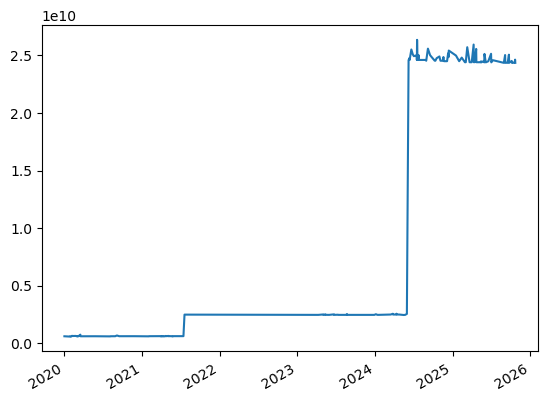

In [37]:
nvda_shares = tk.get_shares_full(start="2020-01-01")
nvda_shares.index = nvda_shares.index.tz_localize(None)
nvda_shares = nvda_shares.groupby(nvda_shares.index).last()
nvda_shares.plot()
plt.show()

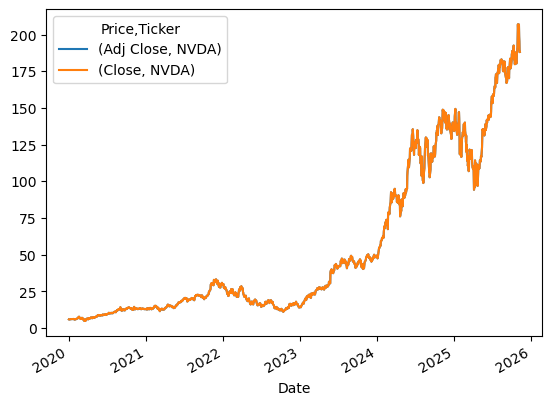

In [43]:
nvda2[['Adj Close', 'Close']].plot()
plt.show()

## Cross-Sectional Factors  
### Size (Market Cap)  
Market Capt(t) = SharesOutstanding(t) × Price(t)
DV(t) (Dollar Volume, daily traded dollars) = Close(t) x Volume(t)  
logDV(t) = log(1 + DV(t))  
ADV(k) = k days moving average on DV  
Turnover(proxy) = Volume z score in k days moving window  
Price Proxy = log(Close[t])  
### Value (P/E, P/B, EV/EBITDA)  
P/E = Price / Earning Per Share  
P/B = Price / Book Value Per Share  
EV (Enterprise Value) = Market Cap + Net Debit  
EBITDA (Earning before interest[I], tax[T], depreciation[D], amortization[A]))) = Net Income + Interest + Tax + Depreciation + Amortization  
EV / EBITDA
### Growth (EPS growth)  
EPS Growth (YoY) = (EPS[this year] - EPS[last year]) / EPS[last year]  
### Quality (ROE, margins)  
ROE = Net Income / Shareholder Equity  
Gross Margin = Gross Profit / Revenue  
### Cross-Sectional Momentum (return rank vs universe)

In [3]:
nvda = yf.download("NVDA", start='2020-01-01', end=None, interval='1d', auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [3]:
text = """
Symbol	Security	GICS Sector	GICS Sub-Industry	Headquarters Location	Date added	CIK	Founded
MMM	3M	Industrials	Industrial Conglomerates	Saint Paul, Minnesota	1957-03-04	0000066740	1902
AOS	A. O. Smith	Industrials	Building Products	Milwaukee, Wisconsin	2017-07-26	0000091142	1916
ABT	Abbott Laboratories	Health Care	Health Care Equipment	North Chicago, Illinois	1957-03-04	0000001800	1888
ABBV	AbbVie	Health Care	Biotechnology	North Chicago, Illinois	2012-12-31	0001551152	2013 (1888)
ACN	Accenture	Information Technology	IT Consulting & Other Services	Dublin, Ireland	2011-07-06	0001467373	1989
ADBE	Adobe Inc.	Information Technology	Application Software	San Jose, California	1997-05-05	0000796343	1982
AMD	Advanced Micro Devices	Information Technology	Semiconductors	Santa Clara, California	2017-03-20	0000002488	1969
AES	AES Corporation	Utilities	Independent Power Producers & Energy Traders	Arlington, Virginia	1998-10-02	0000874761	1981
AFL	Aflac	Financials	Life & Health Insurance	Columbus, Georgia	1999-05-28	0000004977	1955
A	Agilent Technologies	Health Care	Life Sciences Tools & Services	Santa Clara, California	2000-06-05	0001090872	1999
APD	Air Products	Materials	Industrial Gases	Upper Macungie Township, Pennsylvania	1985-04-30	0000002969	1940
ABNB	Airbnb	Consumer Discretionary	Hotels, Resorts & Cruise Lines	San Francisco, California	2023-09-18	0001559720	2008
AKAM	Akamai Technologies	Information Technology	Internet Services & Infrastructure	Cambridge, Massachusetts	2007-07-12	0001086222	1998
ALB	Albemarle Corporation	Materials	Specialty Chemicals	Charlotte, North Carolina	2016-07-01	0000915913	1994
ARE	Alexandria Real Estate Equities	Real Estate	Office REITs	Pasadena, California	2017-03-20	0001035443	1994
ALGN	Align Technology	Health Care	Health Care Supplies	Tempe, Arizona	2017-06-19	0001097149	1997
ALLE	Allegion	Industrials	Building Products	Dublin, Ireland	2013-12-02	0001579241	1908
LNT	Alliant Energy	Utilities	Electric Utilities	Madison, Wisconsin	2016-07-01	0000352541	1917
ALL	Allstate	Financials	Property & Casualty Insurance	Northbrook, Illinois	1995-07-13	0000899051	1931
GOOGL	Alphabet Inc. (Class A)	Communication Services	Interactive Media & Services	Mountain View, California	2006-04-03	0001652044	1998
GOOG	Alphabet Inc. (Class C)	Communication Services	Interactive Media & Services	Mountain View, California	2014-04-03	0001652044	1998
MO	Altria	Consumer Staples	Tobacco	Richmond, Virginia	1957-03-04	0000764180	1985
AMZN	Amazon	Consumer Discretionary	Broadline Retail	Seattle, Washington	2005-11-18	0001018724	1994
AMCR	Amcor	Materials	Paper & Plastic Packaging Products & Materials	Warmley, Bristol, United Kingdom	2019-06-07	0001748790	2019 (1860)
AEE	Ameren	Utilities	Multi-Utilities	St. Louis, Missouri	1991-09-19	0001002910	1902
AEP	American Electric Power	Utilities	Electric Utilities	Columbus, Ohio	1957-03-04	0000004904	1906
AXP	American Express	Financials	Consumer Finance	New York City, New York	1976-06-30	0000004962	1850
AIG	American International Group	Financials	Multi-line Insurance	New York City, New York	1980-03-31	0000005272	1919
AMT	American Tower	Real Estate	Telecom Tower REITs	Boston, Massachusetts	2007-11-19	0001053507	1995
AWK	American Water Works	Utilities	Water Utilities	Camden, New Jersey	2016-03-04	0001410636	1886
AMP	Ameriprise Financial	Financials	Asset Management & Custody Banks	Minneapolis, Minnesota	2005-10-03	0000820027	1894
AME	Ametek	Industrials	Electrical Components & Equipment	Berwyn, Pennsylvania	2013-09-23	0001037868	1930
AMGN	Amgen	Health Care	Biotechnology	Thousand Oaks, California	1992-01-02	0000318154	1980
APH	Amphenol	Information Technology	Electronic Components	Wallingford, Connecticut	2008-09-30	0000820313	1932
ADI	Analog Devices	Information Technology	Semiconductors	Wilmington, Massachusetts	1999-10-12	0000006281	1965
AON	Aon plc	Financials	Insurance Brokers	London, United Kingdom	1996-04-23	0000315293	1982 (1919)
APA	APA Corporation	Energy	Oil & Gas Exploration & Production	Houston, Texas	1997-07-28	0001841666	1954
APO	Apollo Global Management	Financials	Asset Management & Custody Banks	New York City, New York	2024-12-23	0001858681	1990
AAPL	Apple Inc.	Information Technology	Technology Hardware, Storage & Peripherals	Cupertino, California	1982-11-30	0000320193	1977
AMAT	Applied Materials	Information Technology	Semiconductor Materials & Equipment	Santa Clara, California	1995-03-16	0000006951	1967
APP	AppLovin	Information Technology	Application Software	Palo Alto, California	2025-09-22	0001751008	2012
APTV	Aptiv	Consumer Discretionary	Automotive Parts & Equipment	Dublin, Ireland	2012-12-24	0001521332	1994
ACGL	Arch Capital Group	Financials	Property & Casualty Insurance	Hamilton, Bermuda	2022-11-01	0000947484	1995
ADM	Archer Daniels Midland	Consumer Staples	Agricultural Products & Services	Chicago, Illinois	1957-03-04	0000007084	1902
ANET	Arista Networks	Information Technology	Communications Equipment	Santa Clara, California	2018-08-28	0001596532	2004
AJG	Arthur J. Gallagher & Co.	Financials	Insurance Brokers	Rolling Meadows, Illinois	2016-05-31	0000354190	1927
AIZ	Assurant	Financials	Multi-line Insurance	Atlanta, Georgia	2007-04-10	0001267238	1892
T	AT&T	Communication Services	Integrated Telecommunication Services	Dallas, Texas	1983-11-30	0000732717	1983 (1885)
ATO	Atmos Energy	Utilities	Gas Utilities	Dallas, Texas	2019-02-15	0000731802	1906
ADSK	Autodesk	Information Technology	Application Software	San Francisco, California	1989-12-01	0000769397	1982
ADP	Automatic Data Processing	Industrials	Human Resource & Employment Services	Roseland, New Jersey	1981-03-31	0000008670	1949
AZO	AutoZone	Consumer Discretionary	Automotive Retail	Memphis, Tennessee	1997-01-02	0000866787	1979
AVB	AvalonBay Communities	Real Estate	Multi-Family Residential REITs	Arlington, Virginia	2007-01-10	0000915912	1978
AVY	Avery Dennison	Materials	Paper & Plastic Packaging Products & Materials	Mentor, Ohio	1987-12-31	0000008818	1935
AXON	Axon Enterprise	Industrials	Aerospace & Defense	Scottsdale, Arizona	2023-05-04	0001069183	1993
BKR	Baker Hughes	Energy	Oil & Gas Equipment & Services	Houston, Texas	2017-07-07	0001701605	2017
BALL	Ball Corporation	Materials	Metal, Glass & Plastic Containers	Broomfield, Colorado	1984-10-31	0000009389	1880
BAC	Bank of America	Financials	Diversified Banks	Charlotte, North Carolina	1976-06-30	0000070858	1998 (1923 / 1874)
BAX	Baxter International	Health Care	Health Care Equipment	Deerfield, Illinois	1972-09-30	0000010456	1931
BDX	Becton Dickinson	Health Care	Health Care Equipment	Franklin Lakes, New Jersey	1972-09-30	0000010795	1897
BRK.B	Berkshire Hathaway	Financials	Multi-Sector Holdings	Omaha, Nebraska	2010-02-16	0001067983	1839
BBY	Best Buy	Consumer Discretionary	Computer & Electronics Retail	Richfield, Minnesota	1999-06-29	0000764478	1966
TECH	Bio-Techne	Health Care	Life Sciences Tools & Services	Minneapolis, Minnesota	2021-08-30	0000842023	1976
BIIB	Biogen	Health Care	Biotechnology	Cambridge, Massachusetts	2003-11-13	0000875045	1978
BLK	BlackRock	Financials	Asset Management & Custody Banks	New York City, New York	2011-04-04	0002012383	1988
BX	Blackstone Inc.	Financials	Asset Management & Custody Banks	New York City, New York	2023-09-18	0001393818	1985
XYZ	Block, Inc.	Financials	Transaction & Payment Processing Services	none	2025-07-23	0001512673	2009
BK	BNY Mellon	Financials	Asset Management & Custody Banks	New York City, New York	1995-03-31	0001390777	1784
BA	Boeing	Industrials	Aerospace & Defense	Arlington, Virginia	1957-03-04	0000012927	1916
BKNG	Booking Holdings	Consumer Discretionary	Hotels, Resorts & Cruise Lines	Norwalk, Connecticut	2009-11-06	0001075531	1996
BSX	Boston Scientific	Health Care	Health Care Equipment	Marlborough, Massachusetts	1995-02-24	0000885725	1979
BMY	Bristol Myers Squibb	Health Care	Pharmaceuticals	New York City, New York	1957-03-04	0000014272	1989 (1887)
AVGO	Broadcom	Information Technology	Semiconductors	Palo Alto, California	2014-05-08	0001730168	1961
BR	Broadridge Financial Solutions	Industrials	Data Processing & Outsourced Services	Lake Success, New York	2018-06-18	0001383312	1962
BRO	Brown & Brown	Financials	Insurance Brokers	Daytona Beach, Florida	2021-09-20	0000079282	1939
BF.B	Brown–Forman	Consumer Staples	Distillers & Vintners	Louisville, Kentucky	1982-10-31	0000014693	1870
BLDR	Builders FirstSource	Industrials	Building Products	Irving, Texas	2023-12-18	0001316835	1998
BG	Bunge Global	Consumer Staples	Agricultural Products & Services	Chesterfield, Missouri	2023-03-15	0001996862	1818
BXP	BXP, Inc.	Real Estate	Office REITs	Boston, Massachusetts	2006-04-03	0001037540	1970
CHRW	C.H. Robinson	Industrials	Air Freight & Logistics	Eden Prairie, Minnesota	2007-03-02	0001043277	1905
CDNS	Cadence Design Systems	Information Technology	Application Software	San Jose, California	2017-09-18	0000813672	1988
CPT	Camden Property Trust	Real Estate	Multi-Family Residential REITs	Houston, Texas	2022-04-04	0000906345	1981
CPB	Campbell's Company (The)	Consumer Staples	Packaged Foods & Meats	Camden, New Jersey	1957-03-04	0000016732	1869
COF	Capital One	Financials	Consumer Finance	Tysons Corner, Virginia	1998-07-01	0000927628	1994
CAH	Cardinal Health	Health Care	Health Care Distributors	Dublin, Ohio	1997-05-27	0000721371	1971
CCL	Carnival	Consumer Discretionary	Hotels, Resorts & Cruise Lines	Miami, Florida	1998-12-22	0000815097	1972
CARR	Carrier Global	Industrials	Building Products	Palm Beach Gardens, Florida	2020-04-03	0001783180	2020 (1915, United Technologies spinoff)
CAT	Caterpillar Inc.	Industrials	Construction Machinery & Heavy Transportation Equipment	Irving, Texas	1957-03-04	0000018230	1925
CBOE	Cboe Global Markets	Financials	Financial Exchanges & Data	Chicago, Illinois	2017-03-01	0001374310	1973
CBRE	CBRE Group	Real Estate	Real Estate Services	Dallas, Texas	2006-11-10	0001138118	1906
CDW	CDW Corporation	Information Technology	Technology Distributors	Vernon Hills, Illinois	2019-09-23	0001402057	1984
COR	Cencora	Health Care	Health Care Distributors	Conshohocken, Pennsylvania	2001-08-30	0001140859	1985
CNC	Centene Corporation	Health Care	Managed Health Care	St. Louis, Missouri	2016-03-30	0001071739	1984
CNP	CenterPoint Energy	Utilities	Multi-Utilities	Houston, Texas	1985-07-31	0001130310	1882
CF	CF Industries	Materials	Fertilizers & Agricultural Chemicals	Deerfield, Illinois	2008-08-27	0001324404	1946
CRL	Charles River Laboratories	Health Care	Life Sciences Tools & Services	Wilmington, Massachusetts	2021-05-14	0001100682	1947
SCHW	Charles Schwab Corporation	Financials	Investment Banking & Brokerage	Westlake, Texas	1997-06-02	0000316709	1971
CHTR	Charter Communications	Communication Services	Cable & Satellite	Stamford, Connecticut	2016-09-08	0001091667	1993
CVX	Chevron Corporation	Energy	Integrated Oil & Gas	Houston, Texas	1957-03-04	0000093410	1879
CMG	Chipotle Mexican Grill	Consumer Discretionary	Restaurants	Newport Beach, California	2011-04-28	0001058090	1993
CB	Chubb Limited	Financials	Property & Casualty Insurance	Zurich, Switzerland	2010-07-15	0000896159	1985
CHD	Church & Dwight	Consumer Staples	Household Products	Ewing, New Jersey	2015-12-29	0000313927	1847
CI	Cigna	Health Care	Health Care Services	Bloomfield, Connecticut	1976-06-30	0001739940	1982
CINF	Cincinnati Financial	Financials	Property & Casualty Insurance	Fairfield, Ohio	1997-12-18	0000020286	1950
CTAS	Cintas	Industrials	Diversified Support Services	Mason, Ohio	2001-03-01	0000723254	1929
CSCO	Cisco	Information Technology	Communications Equipment	San Jose, California	1993-12-01	0000858877	1984
C	Citigroup	Financials	Diversified Banks	New York City, New York	1988-05-31	0000831001	1998
CFG	Citizens Financial Group	Financials	Regional Banks	Providence, Rhode Island	2016-01-29	0000759944	1828
CLX	Clorox	Consumer Staples	Household Products	Oakland, California	1969-03-31	0000021076	1913
CME	CME Group	Financials	Financial Exchanges & Data	Chicago, Illinois	2006-08-11	0001156375	1848
CMS	CMS Energy	Utilities	Multi-Utilities	Jackson, Michigan	1957-03-04	0000811156	1886
KO	Coca-Cola Company (The)	Consumer Staples	Soft Drinks & Non-alcoholic Beverages	Atlanta, Georgia	1957-03-04	0000021344	1886
CTSH	Cognizant	Information Technology	IT Consulting & Other Services	Teaneck, New Jersey	2006-11-17	0001058290	1994
COIN	Coinbase	Financials	Financial Exchanges & Data	New York City, New York	2025-05-19	0001679788	2012
CL	Colgate-Palmolive	Consumer Staples	Household Products	New York City, New York	1957-03-04	0000021665	1806
CMCSA	Comcast	Communication Services	Cable & Satellite	Philadelphia, Pennsylvania	2002-11-19	0001166691	1963
CAG	Conagra Brands	Consumer Staples	Packaged Foods & Meats	Chicago, Illinois	1983-08-31	0000023217	1919
COP	ConocoPhillips	Energy	Oil & Gas Exploration & Production	Houston, Texas	1957-03-04	0001163165	2002
ED	Consolidated Edison	Utilities	Multi-Utilities	New York City, New York	1957-03-04	0001047862	1823
STZ	Constellation Brands	Consumer Staples	Distillers & Vintners	Rochester, New York	2005-07-01	0000016918	1945
CEG	Constellation Energy	Utilities	Electric Utilities	Baltimore, Maryland	2022-02-02	0001868275	1999
COO	Cooper Companies (The)	Health Care	Health Care Supplies	San Ramon, California	2016-09-23	0000711404	1958
CPRT	Copart	Industrials	Diversified Support Services	Dallas, Texas	2018-07-02	0000900075	1982
GLW	Corning Inc.	Information Technology	Electronic Components	Corning, New York	1995-02-27	0000024741	1851
CPAY	Corpay	Financials	Transaction & Payment Processing Services	Atlanta, Georgia	2018-06-20	0001175454	2000
CTVA	Corteva	Materials	Fertilizers & Agricultural Chemicals	Indianapolis, Indiana	2019-06-03	0001755672	2019
CSGP	CoStar Group	Real Estate	Real Estate Services	Washington, D.C.	2022-09-19	0001057352	1987
COST	Costco	Consumer Staples	Consumer Staples Merchandise Retail	Issaquah, Washington	1993-10-01	0000909832	1976
CTRA	Coterra	Energy	Oil & Gas Exploration & Production	Houston, Texas	2008-06-23	0000858470	2021 (1989)
CRWD	CrowdStrike	Information Technology	Systems Software	Austin, Texas	2024-06-24	0001535527	2011
CCI	Crown Castle	Real Estate	Telecom Tower REITs	Houston, Texas	2012-03-14	0001051470	1994
CSX	CSX Corporation	Industrials	Rail Transportation	Jacksonville, Florida	1957-03-04	0000277948	1980
CMI	Cummins	Industrials	Construction Machinery & Heavy Transportation Equipment	Columbus, Indiana	1965-03-31	0000026172	1919
CVS	CVS Health	Health Care	Health Care Services	Woonsocket, Rhode Island	1957-03-04	0000064803	1996
DHR	Danaher Corporation	Health Care	Life Sciences Tools & Services	Washington, D.C.	1998-11-18	0000313616	1969
DRI	Darden Restaurants	Consumer Discretionary	Restaurants	Orlando, Florida	1995-05-31	0000940944	1938
DDOG	Datadog	Information Technology	Application Software	New York City, New York	2025-07-09	0001561550	2010
DVA	DaVita	Health Care	Health Care Services	Denver, Colorado	2008-07-31	0000927066	1979
DAY	Dayforce	Industrials	Human Resource & Employment Services	Minneapolis, Minnesota	2021-09-20	0001725057	1992
DECK	Deckers Brands	Consumer Discretionary	Footwear	Goleta, California	2024-03-18	0000910521	1973
DE	Deere & Company	Industrials	Agricultural & Farm Machinery	Moline, Illinois	1957-03-04	0000315189	1837
DELL	Dell Technologies	Information Technology	Technology Hardware, Storage & Peripherals	Round Rock, Texas	2024-09-23	0001571996	2016
DAL	Delta Air Lines	Industrials	Passenger Airlines	Atlanta, Georgia	2013-09-11	0000027904	1929
DVN	Devon Energy	Energy	Oil & Gas Exploration & Production	Oklahoma City, Oklahoma	2000-08-30	0001090012	1971
DXCM	Dexcom	Health Care	Health Care Equipment	San Diego, California	2020-05-12	0001093557	1999
FANG	Diamondback Energy	Energy	Oil & Gas Exploration & Production	Midland, Texas	2018-12-03	0001539838	2007
DLR	Digital Realty	Real Estate	Data Center REITs	Austin, Texas	2016-05-18	0001297996	2004
DG	Dollar General	Consumer Staples	Consumer Staples Merchandise Retail	Goodlettsville, Tennessee	2012-12-03	0000029534	1939
DLTR	Dollar Tree	Consumer Staples	Consumer Staples Merchandise Retail	Chesapeake, Virginia	2011-12-19	0000935703	1986
D	Dominion Energy	Utilities	Multi-Utilities	Richmond, Virginia	2016-11-30	0000715957	1983
DPZ	Domino's	Consumer Discretionary	Restaurants	Ann Arbor, Michigan	2020-05-12	0001286681	1960
DASH	DoorDash	Consumer Discretionary	Specialized Consumer Services	San Francisco, California	2025-03-24	0001792789	2012
DOV	Dover Corporation	Industrials	Industrial Machinery & Supplies & Components	Downers Grove, Illinois	1985-10-31	0000029905	1955
DOW	Dow Inc.	Materials	Commodity Chemicals	Midland, Michigan	2019-04-01	0001751788	2019 (1897)
DHI	D. R. Horton	Consumer Discretionary	Homebuilding	Arlington, Texas	2005-06-22	0000882184	1978
DTE	DTE Energy	Utilities	Multi-Utilities	Detroit, Michigan	1957-03-04	0000936340	1995
DUK	Duke Energy	Utilities	Electric Utilities	Charlotte, North Carolina	1976-06-30	0001326160	1904
DD	DuPont	Materials	Specialty Chemicals	Wilmington, Delaware	2019-06-03	0001666700	2017 (1802)
ETN	Eaton Corporation	Industrials	Electrical Components & Equipment	Dublin, Ireland	1957-03-04	0001551182	1911
EBAY	eBay Inc.	Consumer Discretionary	Broadline Retail	San Jose, California	2002-07-22	0001065088	1995
ECL	Ecolab	Materials	Specialty Chemicals	Saint Paul, Minnesota	1989-01-31	0000031462	1923
EIX	Edison International	Utilities	Electric Utilities	Rosemead, California	1957-03-04	0000827052	1886
EW	Edwards Lifesciences	Health Care	Health Care Equipment	Irvine, California	2011-04-01	0001099800	1958
EA	Electronic Arts	Communication Services	Interactive Home Entertainment	Redwood City, California	2002-07-22	0000712515	1982
ELV	Elevance Health	Health Care	Managed Health Care	Indianapolis, Indiana	2002-07-25	0001156039	2014 (1946)
EME	Emcor	Industrials	Construction & Engineering	Norwalk, Connecticut	2025-09-22	0000105634	1994
EMR	Emerson Electric	Industrials	Electrical Components & Equipment	Ferguson, Missouri	1965-03-31	0000032604	1890
ETR	Entergy	Utilities	Electric Utilities	New Orleans, Louisiana	1957-03-04	0000065984	1913
EOG	EOG Resources	Energy	Oil & Gas Exploration & Production	Houston, Texas	2000-11-02	0000821189	1999
EPAM	EPAM Systems	Information Technology	IT Consulting & Other Services	Newtown, Pennsylvania	2021-12-14	0001352010	1993
EQT	EQT Corporation	Energy	Oil & Gas Exploration & Production	Pittsburgh, Pennsylvania	2022-10-03	0000033213	1888
EFX	Equifax	Industrials	Research & Consulting Services	Atlanta, Georgia	1997-06-19	0000033185	1899
EQIX	Equinix	Real Estate	Data Center REITs	Redwood City, California	2015-03-20	0001101239	1998
EQR	Equity Residential	Real Estate	Multi-Family Residential REITs	Chicago, Illinois	2001-12-03	0000906107	1969
ERIE	Erie Indemnity	Financials	Insurance Brokers	Erie, Pennsylvania	2024-09-23	0000922621	1925
ESS	Essex Property Trust	Real Estate	Multi-Family Residential REITs	San Mateo, California	2014-04-02	0000920522	1971
EL	Estée Lauder Companies (The)	Consumer Staples	Personal Care Products	New York City, New York	2006-01-05	0001001250	1946
EG	Everest Group	Financials	Reinsurance	Hamilton, Bermuda	2017-06-19	0001095073	1973
EVRG	Evergy	Utilities	Electric Utilities	Kansas City, Missouri	2018-06-05	0001711269	1909
ES	Eversource Energy	Utilities	Electric Utilities	Hartford, Connecticut	2009-07-24	0000072741	1966
EXC	Exelon	Utilities	Electric Utilities	Chicago, Illinois	1957-03-04	0001109357	2000
EXE	Expand Energy	Energy	Oil & Gas Exploration & Production	Oklahoma City, Oklahoma	2025-03-24	0000895126	1989
EXPE	Expedia Group	Consumer Discretionary	Hotels, Resorts & Cruise Lines	Seattle, Washington	2007-10-02	0001324424	1996
EXPD	Expeditors International	Industrials	Air Freight & Logistics	Seattle, Washington	2007-10-10	0000746515	1979
EXR	Extra Space Storage	Real Estate	Self-Storage REITs	Salt Lake City, Utah	2016-01-19	0001289490	1977
XOM	ExxonMobil	Energy	Integrated Oil & Gas	Irving, Texas	1957-03-04	0000034088	1999
FFIV	F5, Inc.	Information Technology	Communications Equipment	Seattle, Washington	2010-12-20	0001048695	1996
FDS	FactSet	Financials	Financial Exchanges & Data	Norwalk, Connecticut	2021-12-20	0001013237	1978
FICO	Fair Isaac	Information Technology	Application Software	Bozeman, Montana	2023-03-20	0000814547	1956
FAST	Fastenal	Industrials	Trading Companies & Distributors	Winona, Minnesota	2008-09-15	0000815556	1967
FRT	Federal Realty Investment Trust	Real Estate	Retail REITs	Rockville, Maryland	2016-02-01	0000034903	1962
FDX	FedEx	Industrials	Air Freight & Logistics	Memphis, Tennessee	1980-12-31	0001048911	1971
FIS	Fidelity National Information Services	Financials	Transaction & Payment Processing Services	Jacksonville, Florida	2006-11-10	0001136893	1968
FITB	Fifth Third Bancorp	Financials	Regional Banks	Cincinnati, Ohio	1996-03-29	0000035527	1858
FSLR	First Solar	Information Technology	Semiconductors	Tempe, Arizona	2022-12-19	0001274494	1999
FE	FirstEnergy	Utilities	Electric Utilities	Akron, Ohio	1997-11-28	0001031296	1997
FISV	Fiserv	Financials	Transaction & Payment Processing Services	Brookfield, Wisconsin	2001-04-02	0000798354	1984
F	Ford Motor Company	Consumer Discretionary	Automobile Manufacturers	Dearborn, Michigan	1957-03-04	0000037996	1903
FTNT	Fortinet	Information Technology	Systems Software	Sunnyvale, California	2018-10-11	0001262039	2000
FTV	Fortive	Industrials	Industrial Machinery & Supplies & Components	Everett, Washington	2016-07-01	0001659166	2016
FOXA	Fox Corporation (Class A)	Communication Services	Broadcasting	New York City, New York	2019-03-19	0001754301	2019
FOX	Fox Corporation (Class B)	Communication Services	Broadcasting	New York City, New York	2019-03-19	0001754301	2019
BEN	Franklin Resources	Financials	Asset Management & Custody Banks	San Mateo, California	1998-04-30	0000038777	1947
FCX	Freeport-McMoRan	Materials	Copper	Phoenix, Arizona	2011-07-01	0000831259	1912
GRMN	Garmin	Consumer Discretionary	Consumer Electronics	Schaffhausen, Switzerland	2012-12-12	0001121788	1989
IT	Gartner	Information Technology	IT Consulting & Other Services	Stamford, Connecticut	2017-04-05	0000749251	1979
GE	GE Aerospace	Industrials	Aerospace & Defense	Evendale, Ohio	1957-03-04	0000040545	1892
GEHC	GE HealthCare	Health Care	Health Care Equipment	Chicago, Illinois	2023-01-04	0001932393	1994
GEV	GE Vernova	Industrials	Heavy Electrical Equipment	Cambridge, Massachusetts	2024-04-02	0001996810	2024
GEN	Gen Digital	Information Technology	Systems Software	Tempe, Arizona	2003-03-25	0000849399	1982
GNRC	Generac	Industrials	Electrical Components & Equipment	Waukesha, Wisconsin	2021-03-22	0001474735	1959
GD	General Dynamics	Industrials	Aerospace & Defense	Reston, Virginia	1957-03-04	0000040533	1899
GIS	General Mills	Consumer Staples	Packaged Foods & Meats	Golden Valley, Minnesota	1957-03-04	0000040704	1856
GM	General Motors	Consumer Discretionary	Automobile Manufacturers	Detroit, Michigan	2013-06-06	0001467858	1908
GPC	Genuine Parts Company	Consumer Discretionary	Distributors	Atlanta, Georgia	1973-12-31	0000040987	1925
GILD	Gilead Sciences	Health Care	Biotechnology	Foster City, California	2004-07-01	0000882095	1987
GPN	Global Payments	Financials	Transaction & Payment Processing Services	Atlanta, Georgia	2016-04-25	0001123360	2000
GL	Globe Life	Financials	Life & Health Insurance	McKinney, Texas	1989-04-30	0000320335	1900
GDDY	GoDaddy	Information Technology	Internet Services & Infrastructure	Tempe, Arizona	2024-06-24	0001609711	1997
GS	Goldman Sachs	Financials	Investment Banking & Brokerage	New York City, New York	2002-07-22	0000886982	1869
HAL	Halliburton	Energy	Oil & Gas Equipment & Services	Houston, Texas	1957-03-04	0000045012	1919
HIG	Hartford (The)	Financials	Property & Casualty Insurance	Hartford, Connecticut	1957-03-04	0000874766	1810
HAS	Hasbro	Consumer Discretionary	Leisure Products	Pawtucket, Rhode Island	1984-09-30	0000046080	1923
HCA	HCA Healthcare	Health Care	Health Care Facilities	Nashville, Tennessee	2015-01-27	0000860730	1968
DOC	Healthpeak Properties	Real Estate	Health Care REITs	Denver, Colorado	2008-03-31	0000765880	1985
HSIC	Henry Schein	Health Care	Health Care Distributors	Melville, New York	2015-03-17	0001000228	1932
HSY	Hershey Company (The)	Consumer Staples	Packaged Foods & Meats	Hershey, Pennsylvania	1957-03-04	0000047111	1894
HPE	Hewlett Packard Enterprise	Information Technology	Technology Hardware, Storage & Peripherals	Houston, Texas	2015-11-02	0001645590	2015
HLT	Hilton Worldwide	Consumer Discretionary	Hotels, Resorts & Cruise Lines	Tysons Corner, Virginia	2017-06-19	0001585689	1919
HOLX	Hologic	Health Care	Health Care Equipment	Marlborough, Massachusetts	2016-03-30	0000859737	1985
HD	Home Depot (The)	Consumer Discretionary	Home Improvement Retail	Atlanta, Georgia	1988-03-31	0000354950	1978
HON	Honeywell	Industrials	Industrial Conglomerates	Charlotte, North Carolina	1957-03-04	0000773840	1906
HRL	Hormel Foods	Consumer Staples	Packaged Foods & Meats	Austin, Minnesota	2009-03-04	0000048465	1891
HST	Host Hotels & Resorts	Real Estate	Hotel & Resort REITs	Bethesda, Maryland	2007-03-20	0001070750	1993
HWM	Howmet Aerospace	Industrials	Aerospace & Defense	Pittsburgh, Pennsylvania	2016-10-21	0000004281	1888
HPQ	HP Inc.	Information Technology	Technology Hardware, Storage & Peripherals	Palo Alto, California	1974-12-31	0000047217	1939 (2015)
HUBB	Hubbell Incorporated	Industrials	Industrial Machinery & Supplies & Components	Shelton, Connecticut	2023-10-18	0000048898	1888
HUM	Humana	Health Care	Managed Health Care	Louisville, Kentucky	2012-12-10	0000049071	1961
HBAN	Huntington Bancshares	Financials	Regional Banks	Columbus, Ohio; Detroit, Michigan	1997-08-28	0000049196	1866
HII	Huntington Ingalls Industries	Industrials	Aerospace & Defense	Newport News, Virginia	2018-01-03	0001501585	2011
IBM	IBM	Information Technology	IT Consulting & Other Services	Armonk, New York	1957-03-04	0000051143	1911
IEX	IDEX Corporation	Industrials	Industrial Machinery & Supplies & Components	Northbrook, Illinois	2019-08-09	0000832101	1988
IDXX	Idexx Laboratories	Health Care	Health Care Equipment	Westbrook, Maine	2017-01-05	0000874716	1983
ITW	Illinois Tool Works	Industrials	Industrial Machinery & Supplies & Components	Glenview, Illinois	1986-02-28	0000049826	1912
INCY	Incyte	Health Care	Biotechnology	Wilmington, Delaware	2017-02-28	0000879169	1991
IR	Ingersoll Rand	Industrials	Industrial Machinery & Supplies & Components	Davidson, North Carolina	2020-03-03	0001699150	1859
PODD	Insulet Corporation	Health Care	Health Care Equipment	Acton, Massachusetts	2023-03-15	0001145197	2000
INTC	Intel	Information Technology	Semiconductors	Santa Clara, California	1976-12-31	0000050863	1968
IBKR	Interactive Brokers	Financials	Investment Banking & Brokerage	Greenwich, Connecticut	2025-08-28	0001381197	1977
ICE	Intercontinental Exchange	Financials	Financial Exchanges & Data	Atlanta, Georgia	2007-09-26	0001571949	2000
IFF	International Flavors & Fragrances	Materials	Specialty Chemicals	New York City, New York	1976-03-31	0000051253	1958 (1889)
IP	International Paper	Materials	Paper & Plastic Packaging Products & Materials	Memphis, Tennessee	1957-03-04	0000051434	1898
IPG	Interpublic Group of Companies (The)	Communication Services	Advertising	New York City, New York	1992-10-01	0000051644	1961 (1930)
INTU	Intuit	Information Technology	Application Software	Mountain View, California	2000-12-05	0000896878	1983
ISRG	Intuitive Surgical	Health Care	Health Care Equipment	Sunnyvale, California	2008-06-02	0001035267	1995
IVZ	Invesco	Financials	Asset Management & Custody Banks	Atlanta, Georgia	2008-08-21	0000914208	1935
INVH	Invitation Homes	Real Estate	Single-Family Residential REITs	Dallas, Texas	2022-09-19	0001687229	2012
IQV	IQVIA	Health Care	Life Sciences Tools & Services	Durham, North Carolina	2017-08-29	0001478242	1982
IRM	Iron Mountain	Real Estate	Other Specialized REITs	Portsmouth, New Hampshire	2009-01-06	0001020569	1951
JBHT	J.B. Hunt	Industrials	Cargo Ground Transportation	Lowell, Arkansas	2015-07-01	0000728535	1961
JBL	Jabil	Information Technology	Electronic Manufacturing Services	St. Petersburg, Florida	2023-12-18	0000898293	1966
JKHY	Jack Henry & Associates	Financials	Transaction & Payment Processing Services	Monett, Missouri	2018-11-13	0000779152	1976
J	Jacobs Solutions	Industrials	Construction & Engineering	Dallas, Texas	2007-10-26	0000052988	1947
JNJ	Johnson & Johnson	Health Care	Pharmaceuticals	New Brunswick, New Jersey	1973-06-30	0000200406	1886
JCI	Johnson Controls	Industrials	Building Products	Cork, Ireland	2010-08-27	0000833444	1885
JPM	JPMorgan Chase	Financials	Diversified Banks	New York City, New York	1975-06-30	0000019617	2000 (1799 / 1871)
K	Kellanova	Consumer Staples	Packaged Foods & Meats	Chicago, Illinois	1989-09-11	0000055067	1906
KVUE	Kenvue	Consumer Staples	Personal Care Products	Skillman, New Jersey	2023-08-25	0001944048	2022 (Johnson & Johnson spinoff)
KDP	Keurig Dr Pepper	Consumer Staples	Soft Drinks & Non-alcoholic Beverages	Burlington, Massachusetts	2022-06-21	0001418135	1981
KEY	KeyCorp	Financials	Regional Banks	Cleveland, Ohio	1994-03-01	0000091576	1825
KEYS	Keysight Technologies	Information Technology	Electronic Equipment & Instruments	Santa Rosa, California	2018-11-06	0001601046	2014 (1939)
KMB	Kimberly-Clark	Consumer Staples	Household Products	Irving, Texas	1957-03-04	0000055785	1872
KIM	Kimco Realty	Real Estate	Retail REITs	Jericho, New York	2006-04-04	0000879101	1958
KMI	Kinder Morgan	Energy	Oil & Gas Storage & Transportation	Houston, Texas	2012-05-25	0001506307	1997
KKR	KKR & Co.	Financials	Asset Management & Custody Banks	New York City, New York	2024-06-24	0001404912	1976
KLAC	KLA Corporation	Information Technology	Semiconductor Materials & Equipment	Milpitas, California	1997-09-30	0000319201	1975/1977 (1997)
KHC	Kraft Heinz	Consumer Staples	Packaged Foods & Meats	Chicago, Illinois; Pittsburgh, Pennsylvania	2015-07-06	0001637459	2015 (1869)
KR	Kroger	Consumer Staples	Food Retail	Cincinnati, Ohio	1957-03-04	0000056873	1883
LHX	L3Harris	Industrials	Aerospace & Defense	Melbourne, Florida	2008-09-22	0000202058	2019 (L3 1997, Harris 1895)
LH	Labcorp	Health Care	Health Care Services	Burlington, North Carolina	2004-11-01	0000920148	1978
LRCX	Lam Research	Information Technology	Semiconductor Materials & Equipment	Fremont, California	2012-06-29	0000707549	1980
LW	Lamb Weston	Consumer Staples	Packaged Foods & Meats	Eagle, Idaho	2018-12-03	0001679273	2016 (1950)
LVS	Las Vegas Sands	Consumer Discretionary	Casinos & Gaming	Las Vegas, Nevada	2019-10-03	0001300514	1988
LDOS	Leidos	Industrials	Diversified Support Services	Reston, Virginia	2019-08-09	0001336920	1969
LEN	Lennar	Consumer Discretionary	Homebuilding	Miami, Florida	2005-10-04	0000920760	1954
LII	Lennox International	Industrials	Building Products	Richardson, Texas	2024-12-23	0001069202	1895
LLY	Lilly (Eli)	Health Care	Pharmaceuticals	Indianapolis, Indiana	1970-12-31	0000059478	1876
LIN	Linde plc	Materials	Industrial Gases	Guildford, United Kingdom	1992-07-01	0001707925	1879
LYV	Live Nation Entertainment	Communication Services	Movies & Entertainment	Beverly Hills, California	2019-12-23	0001335258	2010
LKQ	LKQ Corporation	Consumer Discretionary	Distributors	Nashville, Tennessee	2016-05-23	0001065696	1998
LMT	Lockheed Martin	Industrials	Aerospace & Defense	Bethesda, Maryland	1957-03-04	0000936468	1995
L	Loews Corporation	Financials	Multi-line Insurance	New York City, New York	1995-05-31	0000060086	1959
LOW	Lowe's	Consumer Discretionary	Home Improvement Retail	Mooresville, North Carolina	1984-02-29	0000060667	1904/1946/1959
LULU	Lululemon Athletica	Consumer Discretionary	Apparel, Accessories & Luxury Goods	Vancouver, Canada	2023-10-18	0001397187	1998
LYB	LyondellBasell	Materials	Specialty Chemicals	Rotterdam, Netherlands	2012-09-05	0001489393	2007
MTB	M&T Bank	Financials	Regional Banks	Buffalo, New York	2004-02-23	0000036270	1856
MPC	Marathon Petroleum	Energy	Oil & Gas Refining & Marketing	Findlay, Ohio	2011-07-01	0001510295	2009 (1887)
MAR	Marriott International	Consumer Discretionary	Hotels, Resorts & Cruise Lines	Bethesda, Maryland	1998-05-29	0001048286	1927
MMC	Marsh McLennan	Financials	Insurance Brokers	New York City, New York	1987-08-31	0000062709	1905
MLM	Martin Marietta Materials	Materials	Construction Materials	Raleigh, North Carolina	2014-07-02	0000916076	1993
MAS	Masco	Industrials	Building Products	Livonia, Michigan	1981-06-30	0000062996	1929
MA	Mastercard	Financials	Transaction & Payment Processing Services	Harrison, New York	2008-07-18	0001141391	1966
MTCH	Match Group	Communication Services	Interactive Media & Services	Dallas, Texas	2021-09-20	0000891103	1986
MKC	McCormick & Company	Consumer Staples	Packaged Foods & Meats	Hunt Valley, Maryland	2003-03-20	0000063754	1889
MCD	McDonald's	Consumer Discretionary	Restaurants	Chicago, Illinois	1970-06-30	0000063908	1940
MCK	McKesson Corporation	Health Care	Health Care Distributors	Irving, Texas	1999-01-13	0000927653	1833
MDT	Medtronic	Health Care	Health Care Equipment	Dublin, Ireland	1986-10-31	0001613103	1949
MRK	Merck & Co.	Health Care	Pharmaceuticals	Kenilworth, New Jersey	1957-03-04	0000310158	1891
META	Meta Platforms	Communication Services	Interactive Media & Services	Menlo Park, California	2013-12-23	0001326801	2004
MET	MetLife	Financials	Life & Health Insurance	New York City, New York	2000-12-11	0001099219	1868
MTD	Mettler Toledo	Health Care	Life Sciences Tools & Services	Columbus, Ohio	2016-09-06	0001037646	1945
MGM	MGM Resorts	Consumer Discretionary	Casinos & Gaming	Paradise, Nevada	2017-07-26	0000789570	1986
MCHP	Microchip Technology	Information Technology	Semiconductors	Chandler, Arizona	2007-09-07	0000827054	1989
MU	Micron Technology	Information Technology	Semiconductors	Boise, Idaho	1994-09-27	0000723125	1978
MSFT	Microsoft	Information Technology	Systems Software	Redmond, Washington	1994-06-01	0000789019	1975
MAA	Mid-America Apartment Communities	Real Estate	Multi-Family Residential REITs	Memphis, Tennessee	2016-12-02	0000912595	1977
MRNA	Moderna	Health Care	Biotechnology	Cambridge, Massachusetts	2021-07-21	0001682852	2010
MHK	Mohawk Industries	Consumer Discretionary	Home Furnishings	Calhoun, Georgia	2013-12-23	0000851968	1878
MOH	Molina Healthcare	Health Care	Managed Health Care	Long Beach, California	2022-03-02	0001179929	1980
TAP	Molson Coors Beverage Company	Consumer Staples	Brewers	Chicago, Illinois	1976-06-30	0000024545	2005 (Molson 1786, Coors 1873)
MDLZ	Mondelez International	Consumer Staples	Packaged Foods & Meats	Chicago, Illinois	2012-10-02	0001103982	2012
MPWR	Monolithic Power Systems	Information Technology	Semiconductors	Kirkland, Washington	2021-02-12	0001280452	1997
MNST	Monster Beverage	Consumer Staples	Soft Drinks & Non-alcoholic Beverages	Corona, California	2012-06-28	0000865752	2012 (1935)
MCO	Moody's Corporation	Financials	Financial Exchanges & Data	New York City, New York	1998-07-01	0001059556	1909
MS	Morgan Stanley	Financials	Investment Banking & Brokerage	New York City, New York	1993-07-29	0000895421	1935
MOS	Mosaic Company (The)	Materials	Fertilizers & Agricultural Chemicals	Tampa, Florida	2011-09-26	0001285785	2004 (1865 / 1909)
MSI	Motorola Solutions	Information Technology	Communications Equipment	Chicago, Illinois	1957-03-04	0000068505	1928 (2011)
MSCI	MSCI Inc.	Financials	Financial Exchanges & Data	New York City, New York	2018-04-04	0001408198	1969
NDAQ	Nasdaq, Inc.	Financials	Financial Exchanges & Data	New York City, New York	2008-10-22	0001120193	1971
NTAP	NetApp	Information Technology	Technology Hardware, Storage & Peripherals	San Jose, California	1999-06-25	0001002047	1992
NFLX	Netflix	Communication Services	Movies & Entertainment	Los Gatos, California	2010-12-20	0001065280	1997
NEM	Newmont	Materials	Gold	Denver, Colorado	1969-06-30	0001164727	1921
NWSA	News Corp (Class A)	Communication Services	Publishing	New York City, New York	2013-08-01	0001564708	2013 (News Corporation 1980)
NWS	News Corp (Class B)	Communication Services	Publishing	New York City, New York	2015-09-18	0001564708	2013 (News Corporation 1980)
NEE	NextEra Energy	Utilities	Multi-Utilities	Juno Beach, Florida	1976-06-30	0000753308	1984 (1925)
NKE	Nike, Inc.	Consumer Discretionary	Apparel, Accessories & Luxury Goods	Washington County, Oregon	1988-11-30	0000320187	1964
NI	NiSource	Utilities	Multi-Utilities	Merrillville, Indiana	2000-11-02	0001111711	1912
NDSN	Nordson Corporation	Industrials	Industrial Machinery & Supplies & Components	Westlake, Ohio	2022-02-15	0000072331	1935
NSC	Norfolk Southern	Industrials	Rail Transportation	Atlanta, Georgia	1957-03-04	0000702165	1881/1894 (1980)
NTRS	Northern Trust	Financials	Asset Management & Custody Banks	Chicago, Illinois	1998-01-30	0000073124	1889
NOC	Northrop Grumman	Industrials	Aerospace & Defense	West Falls Church, Virginia[3]	1957-03-04	0001133421	1994 (Northrop 1939, Grumman 1930)
NCLH	Norwegian Cruise Line Holdings	Consumer Discretionary	Hotels, Resorts & Cruise Lines	Miami-Dade County, Florida[4]	2017-10-13	0001513761	2011 (1966)
NRG	NRG Energy	Utilities	Independent Power Producers & Energy Traders	Houston, Texas	2010-01-29	0001013871	1992
NUE	Nucor	Materials	Steel	Charlotte, North Carolina	1985-04-30	0000073309	1940
NVDA	Nvidia	Information Technology	Semiconductors	Santa Clara, California	2001-11-30	0001045810	1993
NVR	NVR, Inc.	Consumer Discretionary	Homebuilding	Reston, Virginia	2019-09-26	0000906163	1980
NXPI	NXP Semiconductors	Information Technology	Semiconductors	Eindhoven, Netherlands	2021-03-22	0001413447	1953
ORLY	O’Reilly Automotive	Consumer Discretionary	Automotive Retail	Springfield, Missouri	2009-03-27	0000898173	1957
OXY	Occidental Petroleum	Energy	Oil & Gas Exploration & Production	Houston, Texas	1957-03-04	0000797468	1920
ODFL	Old Dominion	Industrials	Cargo Ground Transportation	Thomasville, North Carolina	2019-12-09	0000878927	1934
OMC	Omnicom Group	Communication Services	Advertising	New York City, New York	1997-12-31	0000029989	1986
ON	ON Semiconductor	Information Technology	Semiconductors	Phoenix, Arizona	2022-06-21	0001097864	1999
OKE	Oneok	Energy	Oil & Gas Storage & Transportation	Tulsa, Oklahoma	2010-03-15	0001039684	1906
ORCL	Oracle Corporation	Information Technology	Application Software	Austin, Texas	1989-08-31	0001341439	1977
OTIS	Otis Worldwide	Industrials	Industrial Machinery & Supplies & Components	Farmington, Connecticut	2020-04-03	0001781335	2020 (1853, United Technologies spinoff)
PCAR	Paccar	Industrials	Construction Machinery & Heavy Transportation Equipment	Bellevue, Washington	1980-12-31	0000075362	1905
PKG	Packaging Corporation of America	Materials	Paper & Plastic Packaging Products & Materials	Lake Forest, Illinois	2017-07-26	0000075677	1959
PLTR	Palantir Technologies	Information Technology	Application Software	Denver, Colorado	2024-09-23	0001321655	2003
PANW	Palo Alto Networks	Information Technology	Systems Software	Santa Clara, California	2023-06-20	0001327567	2005
PSKY	Paramount Skydance Corporation	Communication Services	Movies & Entertainment	Los Angeles, California	1994-09-30	0002041610	2025 (Paramount Pictures 1912)
PH	Parker Hannifin	Industrials	Industrial Machinery & Supplies & Components	Cleveland, Ohio	1985-11-30	0000076334	1917
PAYX	Paychex	Industrials	Human Resource & Employment Services	Penfield, New York	1998-10-01	0000723531	1971
PAYC	Paycom	Industrials	Human Resource & Employment Services	Oklahoma City, Oklahoma	2020-01-28	0001590955	1998
PYPL	PayPal	Financials	Transaction & Payment Processing Services	San Jose, California	2015-07-20	0001633917	1998
PNR	Pentair	Industrials	Industrial Machinery & Supplies & Components	Worsley, United Kingdom	2012-10-01	0000077360	1966
PEP	PepsiCo	Consumer Staples	Soft Drinks & Non-alcoholic Beverages	Purchase, New York	1957-03-04	0000077476	1898
PFE	Pfizer	Health Care	Pharmaceuticals	New York City, New York	1957-03-04	0000078003	1849
PCG	PG&E Corporation	Utilities	Multi-Utilities	Oakland, California	2022-10-03	0001004980	1905
PM	Philip Morris International	Consumer Staples	Tobacco	New York City, New York	2008-03-31	0001413329	2008 (1847)
PSX	Phillips 66	Energy	Oil & Gas Refining & Marketing	Houston, Texas	2012-05-01	0001534701	2012 (1917)
PNW	Pinnacle West Capital	Utilities	Multi-Utilities	Phoenix, Arizona	1999-10-04	0000764622	1985
PNC	PNC Financial Services	Financials	Diversified Banks	Pittsburgh, Pennsylvania	1988-04-30	0000713676	1845
POOL	Pool Corporation	Consumer Discretionary	Distributors	Covington, Louisiana	2020-10-07	0000945841	1993
PPG	PPG Industries	Materials	Specialty Chemicals	Pittsburgh, Pennsylvania	1957-03-04	0000079879	1883
PPL	PPL Corporation	Utilities	Electric Utilities	Allentown, Pennsylvania	2001-10-01	0000922224	1920
PFG	Principal Financial Group	Financials	Life & Health Insurance	Des Moines, Iowa	2002-07-22	0001126328	1879
PG	Procter & Gamble	Consumer Staples	Personal Care Products	Cincinnati, Ohio	1957-03-04	0000080424	1837
PGR	Progressive Corporation	Financials	Property & Casualty Insurance	Mayfield Village, Ohio	1997-08-04	0000080661	1937
PLD	Prologis	Real Estate	Industrial REITs	San Francisco, California	2003-07-17	0001045609	1983
PRU	Prudential Financial	Financials	Life & Health Insurance	Newark, New Jersey	2002-07-22	0001137774	1875
PEG	Public Service Enterprise Group	Utilities	Electric Utilities	Newark, New Jersey	1957-03-04	0000788784	1903
PTC	PTC Inc.	Information Technology	Application Software	Boston, Massachusetts	2021-04-20	0000857005	1985
PSA	Public Storage	Real Estate	Self-Storage REITs	Glendale, California	2005-08-19	0001393311	1972
PHM	PulteGroup	Consumer Discretionary	Homebuilding	Atlanta, Georgia	1984-04-30	0000822416	1956
PWR	Quanta Services	Industrials	Construction & Engineering	Houston, Texas	2009-07-01	0001050915	1997
QCOM	Qualcomm	Information Technology	Semiconductors	San Diego, California	1999-07-22	0000804328	1985
DGX	Quest Diagnostics	Health Care	Health Care Services	Secaucus, New Jersey	2002-12-12	0001022079	1967
Q	Qnity Electronics	Information Technology	Semiconductor Materials & Equipment	Wilmington, Delaware	2025-11-03	0002058873	2025
RL	Ralph Lauren Corporation	Consumer Discretionary	Apparel, Accessories & Luxury Goods	New York City, New York	2007-02-02	0001037038	1967
RJF	Raymond James Financial	Financials	Investment Banking & Brokerage	St. Petersburg, Florida	2017-03-20	0000720005	1962
RTX	RTX Corporation	Industrials	Aerospace & Defense	Waltham, Massachusetts	1957-03-04	0000101829	1922
O	Realty Income	Real Estate	Retail REITs	San Diego, California	2015-04-07	0000726728	1969
REG	Regency Centers	Real Estate	Retail REITs	Jacksonville, Florida	2017-03-02	0000910606	1963
REGN	Regeneron Pharmaceuticals	Health Care	Biotechnology	Tarrytown, New York	2013-05-01	0000872589	1988
RF	Regions Financial Corporation	Financials	Regional Banks	Birmingham, Alabama	1998-08-28	0001281761	1971
RSG	Republic Services	Industrials	Environmental & Facilities Services	Phoenix, Arizona	2008-12-05	0001060391	1998 (1981)
RMD	ResMed	Health Care	Health Care Equipment	San Diego, California	2017-07-26	0000943819	1989
RVTY	Revvity	Health Care	Health Care Equipment	Waltham, Massachusetts	1985-05-31	0000031791	1937
HOOD	Robinhood Markets	Financials	Investment Banking & Brokerage	Menlo Park, California	2025-09-22	0001783879	2013
ROK	Rockwell Automation	Industrials	Electrical Components & Equipment	Milwaukee, Wisconsin	2000-03-12	0001024478	1903
ROL	Rollins, Inc.	Industrials	Environmental & Facilities Services	Atlanta, Georgia	2018-10-01	0000084839	1948
ROP	Roper Technologies	Information Technology	Electronic Equipment & Instruments	Sarasota, Florida	2009-12-23	0000882835	1981
ROST	Ross Stores	Consumer Discretionary	Apparel Retail	Dublin, California	2009-12-21	0000745732	1982
RCL	Royal Caribbean Group	Consumer Discretionary	Hotels, Resorts & Cruise Lines	Miami, Florida	2014-12-05	0000884887	1997
SPGI	S&P Global	Financials	Financial Exchanges & Data	New York City, New York	1957-03-04	0000064040	1917
CRM	Salesforce	Information Technology	Application Software	San Francisco, California	2008-09-15	0001108524	1999
SBAC	SBA Communications	Real Estate	Telecom Tower REITs	Boca Raton, Florida	2017-09-01	0001034054	1989
SLB	Schlumberger	Energy	Oil & Gas Equipment & Services	Houston, Texas	1957-03-04	0000087347	1926
STX	Seagate Technology	Information Technology	Technology Hardware, Storage & Peripherals	Dublin, Ireland	2012-07-02	0001137789	1979
SRE	Sempra	Utilities	Multi-Utilities	San Diego, California	2017-03-17	0001032208	1998
NOW	ServiceNow	Information Technology	Systems Software	Santa Clara, California	2019-11-21	0001373715	2003
SHW	Sherwin-Williams	Materials	Specialty Chemicals	Cleveland, Ohio	1964-06-30	0000089800	1866
SPG	Simon Property Group	Real Estate	Retail REITs	Indianapolis, Indiana	2002-06-26	0001063761	2003
SWKS	Skyworks Solutions	Information Technology	Semiconductors	Irvine, California	2015-03-12	0000004127	2002
SJM	J.M. Smucker Company (The)	Consumer Staples	Packaged Foods & Meats	Orrville, Ohio	2008-11-06	0000091419	1897
SW	Smurfit Westrock	Materials	Paper & Plastic Packaging Products & Materials	Dublin, Ireland	2024-07-08	0002005951	1934
SNA	Snap-on	Industrials	Industrial Machinery & Supplies & Components	Kenosha, Wisconsin	1982-09-30	0000091440	1920
SOLS	Solstice Advanced Materials	Materials	TBD	Morris Plains, New Jersey	2025-10-30	0002064953	2025
SOLV	Solventum	Health Care	Health Care Technology	Saint Paul, Minnesota	2024-04-01	0001964738	2023
SO	Southern Company	Utilities	Electric Utilities	Atlanta, Georgia	1957-03-04	0000092122	1945
LUV	Southwest Airlines	Industrials	Passenger Airlines	Dallas, Texas	1994-07-01	0000092380	1967
SWK	Stanley Black & Decker	Industrials	Industrial Machinery & Supplies & Components	New Britain, Connecticut	1982-09-30	0000093556	1843
SBUX	Starbucks	Consumer Discretionary	Restaurants	Seattle, Washington	2000-06-07	0000829224	1971
STT	State Street Corporation	Financials	Asset Management & Custody Banks	Boston, Massachusetts	2003-03-14	0000093751	1792
STLD	Steel Dynamics	Materials	Steel	Fort Wayne, Indiana	2022-12-22	0001022671	1993
STE	Steris	Health Care	Health Care Equipment	Dublin, Ireland	2019-12-23	0001757898	1985
SYK	Stryker Corporation	Health Care	Health Care Equipment	Kalamazoo, Michigan	2000-12-12	0000310764	1941
SMCI	Supermicro	Information Technology	Technology Hardware, Storage & Peripherals	San Jose, California	2024-03-18	0001375365	1993
SYF	Synchrony Financial	Financials	Consumer Finance	Stamford, Connecticut	2015-11-18	0001601712	2003
SNPS	Synopsys	Information Technology	Application Software	Sunnyvale, California	2017-03-16	0000883241	1986
SYY	Sysco	Consumer Staples	Food Distributors	Houston, Texas	1986-12-31	0000096021	1969
TMUS	T-Mobile US	Communication Services	Wireless Telecommunication Services	Bellevue, Washington	2019-07-15	0001283699	1994
TROW	T. Rowe Price	Financials	Asset Management & Custody Banks	Baltimore, Maryland	2019-07-29	0001113169	1937
TTWO	Take-Two Interactive	Communication Services	Interactive Home Entertainment	New York City, New York	2018-03-19	0000946581	1993
TPR	Tapestry, Inc.	Consumer Discretionary	Apparel, Accessories & Luxury Goods	New York City, New York	2004-09-01	0001116132	2017
TRGP	Targa Resources	Energy	Oil & Gas Storage & Transportation	Houston, Texas	2022-10-12	0001389170	2005
TGT	Target Corporation	Consumer Staples	Consumer Staples Merchandise Retail	Minneapolis, Minnesota	1976-12-31	0000027419	1902
TEL	TE Connectivity	Information Technology	Electronic Manufacturing Services	Galway, Ireland	2011-10-17	0001385157	2007
TDY	Teledyne Technologies	Information Technology	Electronic Equipment & Instruments	Thousand Oaks, California	2020-06-22	0001094285	1960
TER	Teradyne	Information Technology	Semiconductor Materials & Equipment	North Reading, Massachusetts	2020-09-21	0000097210	1960
TSLA	Tesla, Inc.	Consumer Discretionary	Automobile Manufacturers	Austin, Texas	2020-12-21	0001318605	2003
TXN	Texas Instruments	Information Technology	Semiconductors	Dallas, Texas	2001-03-12	0000097476	1930
TPL	Texas Pacific Land Corporation	Energy	Oil & Gas Exploration & Production	Dallas, Texas	2024-11-26	0001811074	1888
TXT	Textron	Industrials	Aerospace & Defense	Providence, Rhode Island	1978-12-31	0000217346	1923
TMO	Thermo Fisher Scientific	Health Care	Life Sciences Tools & Services	Waltham, Massachusetts	2004-08-03	0000097745	2006 (1902)
TJX	TJX Companies	Consumer Discretionary	Apparel Retail	Framingham, Massachusetts	1985-09-30	0000109198	1987
TKO	TKO Group Holdings	Communication Services	Movies & Entertainment	New York City, New York	2025-03-24	0001973266	2023
TTD	Trade Desk (The)	Communication Services	Advertising	Ventura, California	2025-07-18	0001671933	2009
TSCO	Tractor Supply	Consumer Discretionary	Other Specialty Retail	Brentwood, Tennessee	2014-01-24	0000916365	1938
TT	Trane Technologies	Industrials	Building Products	Dublin, Ireland	2010-11-17	0001466258	1871
TDG	TransDigm Group	Industrials	Aerospace & Defense	Cleveland, Ohio	2016-06-03	0001260221	1993
TRV	Travelers Companies (The)	Financials	Property & Casualty Insurance	New York City, New York	2002-08-21	0000086312	1853
TRMB	Trimble Inc.	Information Technology	Electronic Equipment & Instruments	Westminster, Colorado	2021-01-21	0000864749	1978
TFC	Truist Financial	Financials	Diversified Banks	Charlotte, North Carolina	1997-12-04	0000092230	1872
TYL	Tyler Technologies	Information Technology	Application Software	Plano, Texas	2020-06-22	0000860731	1966
TSN	Tyson Foods	Consumer Staples	Packaged Foods & Meats	Springdale, Arkansas	2005-08-10	0000100493	1935
USB	U.S. Bancorp	Financials	Diversified Banks	Minneapolis, Minnesota	1999-11-01	0000036104	1968
UBER	Uber	Industrials	Passenger Ground Transportation	San Francisco, California	2023-12-18	0001543151	2009
UDR	UDR, Inc.	Real Estate	Multi-Family Residential REITs	Highlands Ranch, Colorado	2016-03-07	0000074208	1972
ULTA	Ulta Beauty	Consumer Discretionary	Other Specialty Retail	Bolingbrook, Illinois	2016-04-18	0001403568	1990
UNP	Union Pacific Corporation	Industrials	Rail Transportation	Omaha, Nebraska	1957-03-04	0000100885	1862
UAL	United Airlines Holdings	Industrials	Passenger Airlines	Chicago, Illinois	2015-09-03	0000100517	1967
UPS	United Parcel Service	Industrials	Air Freight & Logistics	Sandy Springs, Georgia	2002-07-22	0001090727	1907
URI	United Rentals	Industrials	Trading Companies & Distributors	Stamford, Connecticut	2014-09-20	0001067701	1997
UNH	UnitedHealth Group	Health Care	Managed Health Care	Eden Prairie, Minnesota	1994-07-01	0000731766	1977
UHS	Universal Health Services	Health Care	Health Care Facilities	King of Prussia, Pennsylvania	2014-09-20	0000352915	1979
VLO	Valero Energy	Energy	Oil & Gas Refining & Marketing	San Antonio, Texas	2002-12-20	0001035002	1980
VTR	Ventas	Real Estate	Health Care REITs	Chicago, Illinois	2009-03-04	0000740260	1998
VLTO	Veralto	Industrials	Environmental & Facilities Services	Waltham, Massachusetts	2023-10-02	0001967680	2023
VRSN	Verisign	Information Technology	Internet Services & Infrastructure	Reston, Virginia	2006-02-01	0001014473	1995
VRSK	Verisk Analytics	Industrials	Research & Consulting Services	Jersey City, New Jersey	2015-10-08	0001442145	1971
VZ	Verizon	Communication Services	Integrated Telecommunication Services	New York City, New York	1983-11-30	0000732712	1983 (1877)
VRTX	Vertex Pharmaceuticals	Health Care	Biotechnology	Boston, Massachusetts	2013-09-23	0000875320	1989
VTRS	Viatris	Health Care	Pharmaceuticals	Pittsburgh, Pennsylvania	2004-04-23	0001792044	1961
VICI	Vici Properties	Real Estate	Hotel & Resort REITs	New York City, New York	2022-06-08	0001705696	2017
V	Visa Inc.	Financials	Transaction & Payment Processing Services	San Francisco, California	2009-12-21	0001403161	1958
VST	Vistra Corp.	Utilities	Electric Utilities	Irving, Texas	2024-05-08	0001692819	2016
VMC	Vulcan Materials Company	Materials	Construction Materials	Birmingham, Alabama	1999-06-30	0001396009	1909
WRB	W. R. Berkley Corporation	Financials	Property & Casualty Insurance	Greenwich, Connecticut	2019-12-05	0000011544	1967
GWW	W. W. Grainger	Industrials	Industrial Machinery & Supplies & Components	Lake Forest, Illinois	1981-06-30	0000277135	1927
WAB	Wabtec	Industrials	Construction Machinery & Heavy Transportation Equipment	Pittsburgh, Pennsylvania	2019-02-27	0000943452	1999 (1869)
WMT	Walmart	Consumer Staples	Consumer Staples Merchandise Retail	Bentonville, Arkansas	1982-08-31	0000104169	1962
DIS	Walt Disney Company (The)	Communication Services	Movies & Entertainment	Burbank, California	1976-06-30	0001744489	1923
WBD	Warner Bros. Discovery	Communication Services	Broadcasting	New York City, New York	2022-04-11	0001437107	2022 (Warner Bros. 1923)
WM	Waste Management	Industrials	Environmental & Facilities Services	Houston, Texas	1998-08-31	0000823768	1968
WAT	Waters Corporation	Health Care	Life Sciences Tools & Services	Milford, Massachusetts	2002-01-02	0001000697	1958
WEC	WEC Energy Group	Utilities	Electric Utilities	Milwaukee, Wisconsin	2008-10-31	0000783325	1896
WFC	Wells Fargo	Financials	Diversified Banks	San Francisco, California	1976-06-30	0000072971	1852
WELL	Welltower	Real Estate	Health Care REITs	Toledo, Ohio	2009-01-30	0000766704	1970
WST	West Pharmaceutical Services	Health Care	Health Care Supplies	Exton, Pennsylvania	2020-05-22	0000105770	1923
WDC	Western Digital	Information Technology	Technology Hardware, Storage & Peripherals	San Jose, California	2009-07-01	0000106040	1970
WY	Weyerhaeuser	Real Estate	Timber REITs	Seattle, Washington	1979-10-01	0000106535	1900
WSM	Williams-Sonoma, Inc.	Consumer Discretionary	Homefurnishing Retail	San Francisco, California	2025-03-24	0000719955	1956
WMB	Williams Companies	Energy	Oil & Gas Storage & Transportation	Tulsa, Oklahoma	1975-03-31	0000107263	1908
WTW	Willis Towers Watson	Financials	Insurance Brokers	London, United Kingdom	2016-01-05	0001140536	2016
WDAY	Workday, Inc.	Information Technology	Application Software	Pleasanton, California	2024-12-23	0001327811	2005
WYNN	Wynn Resorts	Consumer Discretionary	Casinos & Gaming	Paradise, Nevada	2008-11-14	0001174922	2002
XEL	Xcel Energy	Utilities	Multi-Utilities	Minneapolis, Minnesota	1957-03-04	0000072903	1909
XYL	Xylem Inc.	Industrials	Industrial Machinery & Supplies & Components	White Plains, New York	2011-11-01	0001524472	2011
YUM	Yum! Brands	Consumer Discretionary	Restaurants	Louisville, Kentucky	1997-10-06	0001041061	1997
ZBRA	Zebra Technologies	Information Technology	Electronic Equipment & Instruments	Lincolnshire, Illinois	2019-12-23	0000877212	1969
ZBH	Zimmer Biomet	Health Care	Health Care Equipment	Warsaw, Indiana	2001-08-07	0001136869	1927
ZTS	Zoetis	Health Care	Pharmaceuticals	Parsippany, New Jersey	2013-06-21	0001555280	1952
"""
text_list = [x.split('\t') for x in text.split('\n')[1:-1]]
sp500_info = pd.DataFrame(text_list[1:], columns=text_list[0])
sp500_info

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,0000066740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,0000091142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,0000001800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,0001551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,0001467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,0001524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,0001041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,0000877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,0001136869,1927


In [23]:
sp500_df = yf.download(sp500_info['Symbol'].tolist(), start='2025-01-01', end=None, interval='1d', auto_adjust=True)

[*********************100%***********************]  503 of 503 completed

2 Failed downloads:
['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')
['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2025-01-01 -> 2025-11-13)')


In [30]:
sp500_close_df = sp500_df['Close']
sp500_vol_df = sp500_df['Volume']

### Market Cap

In [45]:
# True PIT market cap requires raw (unadjusted) price which is not available through yf, will improve in the future
# PIT sharesOutstanding * PIT price

### Dollar Volume (DV)

In [45]:
log_dv_all = np.log(1 + sp500_close_df * sp500_vol_df)
# log_dv_all.head()

In [46]:
# log_dv_all.rank(axis=1).tail(10)

In [47]:
log_madv50_all = log_dv_all.rolling(50).mean()
# log_madv50_all.tail(10)

In [48]:
# log_madv50_all.rank(axis=1).tail(10)

### Turnover Proxy (Volume Zscore)

In [43]:
volz_ma50 = (sp500_vol_df - sp500_vol_df.rolling(50).mean()) / sp500_vol_df.rolling(50).std()

In [49]:
# volz_ma50.tail(10)

### P/E

In [50]:
t = yf.Ticker("NVDA")

In [58]:
t.info['trailingPE']

53.23647

In [60]:
t.get_eps_revisions()

,upLast7days,upLast30days,downLast30days,downLast7Days
period,,,,
0q,4,6,0,0
+1q,4,6,2,2
0y,7,11,1,1
+1y,13,16,0,0


In [61]:
t.get_eps_trend()

,current,7daysAgo,30daysAgo,60daysAgo,90daysAgo
period,,,,,
0q,1.24929,1.24649,1.24314,1.23972,1.18399
+1q,1.42145,1.41874,1.41630,1.41285,1.35057
0y,4.53916,4.53238,4.50875,4.49887,4.29866
+1y,6.72200,6.68368,6.38230,6.32370,5.86146


In [63]:
t.income_stmt 

,2025-01-31,2024-01-31,2023-01-31,2022-01-31
Tax Effect Of Unusual Items,0.000000e+00,0.000000e+00,-2.841300e+08,0.000000e+00
Tax Rate For Calcs,1.330000e-01,1.200000e-01,2.100000e-01,1.900000e-02
Normalized EBITDA,8.613700e+10,3.558300e+10,7.339000e+09,1.135100e+10
Total Unusual Items,0.000000e+00,0.000000e+00,-1.353000e+09,0.000000e+00
Total Unusual Items Excluding Goodwill,0.000000e+00,0.000000e+00,-1.353000e+09,0.000000e+00
Net Income From Continuing Operation Net Minority Interest,7.288000e+10,2.976000e+10,4.368000e+09,9.752000e+09
Reconciled Depreciation,1.864000e+09,1.508000e+09,1.543000e+09,1.174000e+09
Reconciled Cost Of Revenue,3.263900e+10,1.662100e+10,1.161800e+10,9.439000e+09
EBITDA,8.613700e+10,3.558300e+10,5.986000e+09,1.135100e+10
EBIT,8.427300e+10,3.407500e+10,4.443000e+09,1.017700e+10


In [64]:
t.get_income_stmt(freq='quarterly')

,2025-07-31,2025-04-30,2025-01-31,2024-10-31,2024-07-31
TaxEffectOfUnusualItems,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
TaxRateForCalcs,1.530000e-01,1.430000e-01,1.239640e-01,1.350000e-01,1.360000e-01
NormalizedEBITDA,3.193700e+10,2.258400e+10,2.582100e+10,2.285500e+10,1.970800e+10
NetIncomeFromContinuingOperationNetMinorityInterest,2.642200e+10,1.877500e+10,2.209100e+10,1.930900e+10,1.659900e+10
ReconciledDepreciation,6.690000e+08,6.110000e+08,5.430000e+08,4.780000e+08,4.330000e+08
ReconciledCostOfRevenue,1.289000e+10,1.739400e+10,1.060800e+10,8.926000e+09,7.466000e+09
EBITDA,3.193700e+10,2.258400e+10,2.582100e+10,2.285500e+10,1.970800e+10
EBIT,3.126800e+10,2.197300e+10,2.527800e+10,2.237700e+10,1.927500e+10
NetInterestIncome,5.300000e+08,4.520000e+08,4.500000e+08,4.110000e+08,3.830000e+08
InterestExpense,6.200000e+07,6.300000e+07,6.100000e+07,6.100000e+07,6.100000e+07


In [65]:
tk = yf.Ticker("NVDA")
inc = tk.get_income_stmt(freq="quarterly")
print(inc.columns)

DatetimeIndex(['2025-07-31', '2025-04-30', '2025-01-31', '2024-10-31',
               '2024-07-31'],
              dtype='datetime64[ns]', freq=None)


In [66]:
print(inc.T.columns)
print(inc.T[["BasicEPS", "DilutedEPS"]])

Index(['TaxEffectOfUnusualItems', 'TaxRateForCalcs', 'NormalizedEBITDA',
       'NetIncomeFromContinuingOperationNetMinorityInterest',
       'ReconciledDepreciation', 'ReconciledCostOfRevenue', 'EBITDA', 'EBIT',
       'NetInterestIncome', 'InterestExpense', 'InterestIncome',
       'NormalizedIncome', 'NetIncomeFromContinuingAndDiscontinuedOperation',
       'TotalExpenses', 'TotalOperatingIncomeAsReported',
       'DilutedAverageShares', 'BasicAverageShares', 'DilutedEPS', 'BasicEPS',
       'DilutedNIAvailtoComStockholders', 'NetIncomeCommonStockholders',
       'NetIncome', 'NetIncomeIncludingNoncontrollingInterests',
       'NetIncomeContinuousOperations', 'TaxProvision', 'PretaxIncome',
       'OtherIncomeExpense', 'OtherNonOperatingIncomeExpenses',
       'NetNonOperatingInterestIncomeExpense', 'InterestExpenseNonOperating',
       'InterestIncomeNonOperating', 'OperatingIncome', 'OperatingExpense',
       'ResearchAndDevelopment', 'SellingGeneralAndAdministration',
       'Gro

# FMP API

In [4]:
sp500_info

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,0000066740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,0000091142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,0000001800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,0001551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,0001467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,0001524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,0001041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,0000877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,0001136869,1927


In [5]:
import os
from dotenv import load_dotenv
load_dotenv()
import requests


def getFMPData(ticker, info, period=None, limit=None, apikey=None, urlhead=None):
    if urlhead is None:
        urlhead = "https://financialmodelingprep.com/stable/"
    if apikey is None:
        apikey = os.getenv("FMP_API_KEY")
    if period is None:
        period = 'quarter'
    if limit is None:
        limit = 20
    url = f"{urlhead}{info}?symbol={ticker}&apikey={apikey}&period={period}&limit={limit}"
    data = requests.get(url).json()
    return data

## Income Statement

In [6]:
# fmp_api_key = os.getenv("FMP_API_KEY")
# infoType = 'income-statement'
# ticker = 'MMM'

# url = f"https://financialmodelingprep.com/stable/{infoType}?symbol={ticker}&apikey={fmp_api_key}&period=quarter&limit=20"
# data = requests.get(url).json()

In [7]:
data = getFMPData('MMM', 'income-statement')

In [9]:
mmm_incm_stmt = pd.DataFrame(data)
mmm_incm_stmt.head(10)

,date,symbol,reportedCurrency,cik,filingDate,acceptedDate,fiscalYear,period,revenue,costOfRevenue,grossProfit,researchAndDevelopmentExpenses,generalAndAdministrativeExpenses,sellingAndMarketingExpenses,sellingGeneralAndAdministrativeExpenses,otherExpenses,operatingExpenses,costAndExpenses,netInterestIncome,interestIncome,interestExpense,depreciationAndAmortization,ebitda,ebit,nonOperatingIncomeExcludingInterest,operatingIncome,totalOtherIncomeExpensesNet,incomeBeforeTax,incomeTaxExpense,netIncomeFromContinuingOperations,netIncomeFromDiscontinuedOperations,otherAdjustmentsToNetIncome,netIncome,netIncomeDeductions,bottomLineNetIncome,eps,epsDiluted,weightedAverageShsOut,weightedAverageShsOutDil
0,2025-09-30,MMM,USD,0000066740,2025-10-21,2025-10-21 12:12:22,2025,Q3,6517000000,3792000000,2725000000,297000000,0,0,820000000,161000000,1278000000,5070000000,-186000000,46000000,232000000,298000000,1679000000,1381000000,66000000,1447000000,-298000000,1149000000,308000000,841000000,0,0,834000000,0,834000000,1.56,1.55,538400000,542100000
1,2025-06-30,MMM,USD,0000066740,2025-07-18,2025-07-18 11:44:44,2025,Q2,6344000000,3695000000,2649000000,288000000,0,0,1259000000,0,1547000000,5242000000,-185000000,50000000,235000000,290000000,1448000000,1158000000,-56000000,1102000000,-132000000,970000000,245000000,725000000,0,0,723000000,0,723000000,1.35,1.34,540600000,544200000
2,2025-03-31,MMM,USD,0000066740,2025-04-22,2025-04-22 12:24:49,2025,Q1,5954000000,3518000000,2436000000,285000000,0,0,933000000,0,1218000000,4736000000,-174000000,79000000,253000000,290000000,1928000000,1638000000,-420000000,1218000000,169000000,1387000000,265000000,1122000000,0,0,1116000000,0,1116000000,2.05,2.04,543800000,547700000
3,2024-12-31,MMM,USD,0000066740,2025-02-05,2025-02-05 09:57:15,2024,Q4,6010000000,3738000000,2272000000,281000000,0,0,898000000,0,1179000000,4917000000,-157000000,92000000,249000000,322000000,1330000000,1008000000,85000000,1093000000,-332000000,761000000,33000000,728000000,0,0,728000000,0,728000000,1.34,1.33,543600000,546300000
4,2024-09-30,MMM,USD,0000066740,2024-10-22,2024-10-22 11:48:29,2024,Q3,6294000000,3651000000,2643000000,266000000,0,0,1044000000,0,1310000000,4961000000,-167000000,107000000,274000000,310000000,2305000000,1995000000,-662000000,1333000000,391000000,1724000000,348000000,1376000000,0,0,1372000000,0,1372000000,2.49,2.48,550600000,552700000
5,2024-06-30,MMM,USD,0000066740,2024-07-26,2024-07-26 11:11:32,2024,Q2,6255000000,3599000000,2656000000,279000000,0,0,1100000000,0,1379000000,4978000000,-173000000,143000000,316000000,301000000,2027000000,1726000000,-449000000,1277000000,136000000,1413000000,203000000,1210000000,-59000000,0,1145000000,0,1145000000,2.07,2.06,553800000,554800000
6,2024-03-31,MMM,USD,0000066740,2024-04-30,2024-04-30 11:38:15,2024,Q1,6016000000,3507000000,2509000000,244000000,0,0,1037000000,0,1281000000,4788000000,-229000000,110000000,339000000,430000000,1698000000,1268000000,-40000000,1228000000,-298000000,930000000,220000000,710000000,223000000,0,928000000,0,928000000,1.67,1.67,555000000,555900000
7,2023-12-31,MMM,USD,0000066740,2024-02-07,2024-02-07 09:25:16,2023,Q4,6002000000,3783000000,2219000000,286000000,0,0,-3255000000,0,-2969000000,814000000,-277000000,90000000,367000000,399000000,1417000000,1018000000,4170000000,5188000000,-4526000000,662000000,26000000,636000000,311000000,0,945000000,0,945000000,1.70,1.70,554700000,555400000
8,2023-09-30,MMM,USD,0000066740,2023-10-24,2023-10-24 12:17:55,2023,Q3,6270000000,3759000000,2511000000,264000000,0,0,5366000000,0,5630000000,9389000000,-232000000,72000000,304000000,535000000,-2463000000,-2998000000,-121000000,-3119000000,-181000000,-3300000000,-777000000,-2523000000,452000000,0,-2075000000,0,-2075000000,-3.74,-3.74,554300000,554300000
9,2023-06-30,MMM,USD,0000066740,2023-07-25,2023-07-25 14:07:02,2023,Q2,6283000000,3725000000,2558000000,280000000,0,0,1175000000,0,1455000000,5180000000,-134000000,47000000,181000000,449000000,-8800000000,-9249000000,10352000000,11030

In [12]:
date_val = [
    'date',
    'filingDate',
    'acceptedDate',
]

num_val = [
    'revenue',
    'costOfRevenue',
    'grossProfit',
    'researchAndDevelopmentExpenses',
    'generalAndAdministrativeExpenses',
    'sellingAndMarketingExpenses',
    'sellingGeneralAndAdministrativeExpenses',
    'otherExpenses',
    'operatingExpenses',
    'costAndExpenses',
    'netInterestIncome',
    'interestIncome',
    'interestExpense',
    'depreciationAndAmortization',
    'ebitda',
    'ebit',
    'nonOperatingIncomeExcludingInterest',
    'operatingIncome',
    'totalOtherIncomeExpensesNet',
    'incomeBeforeTax',
    'incomeTaxExpense',
    'netIncomeFromContinuingOperations',
    'netIncomeFromDiscontinuedOperations',
    'otherAdjustmentsToNetIncome',
    'netIncome',
    'netIncomeDeductions',
    'bottomLineNetIncome',
    'weightedAverageShsOut',
    'weightedAverageShsOutDil',
]

ratio_val = [
    'eps',
    'epsDiluted',
]

for v in date_val:
    mmm_incm_stmt[v] = pd.to_datetime(mmm_incm_stmt[v])

mmm_incm_stmt[num_val] = mmm_incm_stmt[num_val] / 1000000


mmm_incm_stmt.head(10)

,date,symbol,reportedCurrency,cik,filingDate,acceptedDate,fiscalYear,period,revenue,costOfRevenue,grossProfit,researchAndDevelopmentExpenses,generalAndAdministrativeExpenses,sellingAndMarketingExpenses,sellingGeneralAndAdministrativeExpenses,otherExpenses,operatingExpenses,costAndExpenses,netInterestIncome,interestIncome,interestExpense,depreciationAndAmortization,ebitda,ebit,nonOperatingIncomeExcludingInterest,operatingIncome,totalOtherIncomeExpensesNet,incomeBeforeTax,incomeTaxExpense,netIncomeFromContinuingOperations,netIncomeFromDiscontinuedOperations,otherAdjustmentsToNetIncome,netIncome,netIncomeDeductions,bottomLineNetIncome,eps,epsDiluted,weightedAverageShsOut,weightedAverageShsOutDil
0,2025-09-30,MMM,USD,0000066740,2025-10-21,2025-10-21 12:12:22,2025,Q3,6517.0,3792.0,2725.0,297.0,0.0,0.0,820.0,161.0,1278.0,5070.0,-186.0,46.0,232.0,298.0,1679.0,1381.0,66.0,1447.0,-298.0,1149.0,308.0,841.0,0.0,0.0,834.0,0.0,834.0,1.56,1.55,538.4,542.1
1,2025-06-30,MMM,USD,0000066740,2025-07-18,2025-07-18 11:44:44,2025,Q2,6344.0,3695.0,2649.0,288.0,0.0,0.0,1259.0,0.0,1547.0,5242.0,-185.0,50.0,235.0,290.0,1448.0,1158.0,-56.0,1102.0,-132.0,970.0,245.0,725.0,0.0,0.0,723.0,0.0,723.0,1.35,1.34,540.6,544.2
2,2025-03-31,MMM,USD,0000066740,2025-04-22,2025-04-22 12:24:49,2025,Q1,5954.0,3518.0,2436.0,285.0,0.0,0.0,933.0,0.0,1218.0,4736.0,-174.0,79.0,253.0,290.0,1928.0,1638.0,-420.0,1218.0,169.0,1387.0,265.0,1122.0,0.0,0.0,1116.0,0.0,1116.0,2.05,2.04,543.8,547.7
3,2024-12-31,MMM,USD,0000066740,2025-02-05,2025-02-05 09:57:15,2024,Q4,6010.0,3738.0,2272.0,281.0,0.0,0.0,898.0,0.0,1179.0,4917.0,-157.0,92.0,249.0,322.0,1330.0,1008.0,85.0,1093.0,-332.0,761.0,33.0,728.0,0.0,0.0,728.0,0.0,728.0,1.34,1.33,543.6,546.3
4,2024-09-30,MMM,USD,0000066740,2024-10-22,2024-10-22 11:48:29,2024,Q3,6294.0,3651.0,2643.0,266.0,0.0,0.0,1044.0,0.0,1310.0,4961.0,-167.0,107.0,274.0,310.0,2305.0,1995.0,-662.0,1333.0,391.0,1724.0,348.0,1376.0,0.0,0.0,1372.0,0.0,1372.0,2.49,2.48,550.6,552.7
5,2024-06-30,MMM,USD,0000066740,2024-07-26,2024-07-26 11:11:32,2024,Q2,6255.0,3599.0,2656.0,279.0,0.0,0.0,1100.0,0.0,1379.0,4978.0,-173.0,143.0,316.0,301.0,2027.0,1726.0,-449.0,1277.0,136.0,1413.0,203.0,1210.0,-59.0,0.0,1145.0,0.0,1145.0,2.07,2.06,553.8,554.8
6,2024-03-31,MMM,USD,0000066740,2024-04-30,2024-04-30 11:38:15,2024,Q1,6016.0,3507.0,2509.0,244.0,0.0,0.0,1037.0,0.0,1281.0,4788.0,-229.0,110.0,339.0,430.0,1698.0,1268.0,-40.0,1228.0,-298.0,930.0,220.0,710.0,223.0,0.0,928.0,0.0,928.0,1.67,1.67,555.0,555.9
7,2023-12-31,MMM,USD,0000066740,2024-02-07,2024-02-07 09:25:16,2023,Q4,6002.0,3783.0,2219.0,286.0,0.0,0.0,-3255.0,0.0,-2969.0,814.0,-277.0,90.0,367.0,399.0,1417.0,1018.0,4170.0,5188.0,-4526.0,662.0,26.0,636.0,311.0,0.0,945.0,0.0,945.0,1.70,1.70,554.7,555.4
8,2023-09-30,MMM,USD,0000066740,2023-10-24,2023-10-24 12:17:55,2023,Q3,6270.0,3759.0,2511.0,264.0,0.0,0.0,5366.0,0.0,5630.0,9389.0,-232.0,72.0,304.0,535.0,-2463.0,-2998.0,-121.0,-3119.0,-181.0,-3300.0,-777.0,-2523.0,452.0,0.0,-2075.0,0.0,-2075.0,-3.74,-3.74,554.3,554.3
9,2023-06-30,MMM,USD,0000066740,2023-07-25,2023-07-25 14:07:02,2023,Q2,6283.0,3725.0,2558.0,280.0,0.0,0.0,1175.0,0.0,1455.0,5180.0,-134.0,47.0,181.0,449.0,-8800.0,-9249.0,10352.0,1103.0,-10530.0,-9427.0,-2261.0,-7166.0,330.0,0.0,-6841.0,0.0,-6841.0,-12.35,-12.35,553.9,553.9


In [30]:
mmmGrossMargin = mmm_incm_stmt['grossProfit'] / mmm_incm_stmt['revenue']
mmmGrossMargin

0     0.418137
1     0.417560
2     0.409137
3     0.378037
4     0.419924
5     0.424620
6     0.417055
7     0.369710
8     0.400478
9     0.407130
10    0.422488
11    0.422329
12    0.452721
13    0.418065
14    0.454638
15    0.455295
16    0.459629
17    0.474972
18    0.489775
19    0.488174
dtype: float64

## Balance Sheet Statement

In [17]:
data = getFMPData('MMM', 'balance-sheet-statement')
mmm_bal_stmt = pd.DataFrame(data)
mmm_bal_stmt.head()

,date,symbol,reportedCurrency,cik,filingDate,acceptedDate,fiscalYear,period,cashAndCashEquivalents,shortTermInvestments,cashAndShortTermInvestments,netReceivables,accountsReceivables,otherReceivables,inventory,prepaids,otherCurrentAssets,totalCurrentAssets,propertyPlantEquipmentNet,goodwill,intangibleAssets,goodwillAndIntangibleAssets,longTermInvestments,taxAssets,otherNonCurrentAssets,totalNonCurrentAssets,otherAssets,totalAssets,totalPayables,accountPayables,otherPayables,accruedExpenses,shortTermDebt,capitalLeaseObligationsCurrent,taxPayables,deferredRevenue,otherCurrentLiabilities,totalCurrentLiabilities,longTermDebt,capitalLeaseObligationsNonCurrent,deferredRevenueNonCurrent,deferredTaxLiabilitiesNonCurrent,otherNonCurrentLiabilities,totalNonCurrentLiabilities,otherLiabilities,capitalLeaseObligations,totalLiabilities,treasuryStock,preferredStock,commonStock,retainedEarnings,additionalPaidInCapital,accumulatedOtherComprehensiveIncomeLoss,otherTotalStockholdersEquity,totalStockholdersEquity,totalEquity,minorityInterest,totalLiabilitiesAndTotalEquity,totalInvestments,totalDebt,netDebt
0,2025-09-30,MMM,USD,0000066740,2025-10-21,2025-10-21 12:12:22,2025,Q3,4671000000,517000000,5188000000,3777000000,3777000000,0,3893000000,514000000,2717000000,16089000000,7784000000,6416000000,1127000000,7543000000,0,0,6195000000,21522000000,0,37611000000,2735000000,2735000000,0,668000000,749000000,174000000,324000000,0,4407000000,8733000000,12233000000,379000000,0,0,1211000000,13823000000,10321000000,174000000,32936000000,-35759000000,0,9000000,38103000000,7397000000,-5122000000,0,4628000000,4675000000,47000000,37611000000,517000000,13535000000,8864000000
1,2025-06-30,MMM,USD,0000066740,2025-07-18,2025-07-18 11:44:44,2025,Q2,3712000000,502000000,4214000000,3760000000,3760000000,0,4077000000,642000000,734000000,13427000000,7966000000,6433000000,1162000000,7595000000,0,0,9001000000,24562000000,0,37989000000,3155000000,2840000000,315000000,594000000,669000000,180000000,315000000,0,3210000000,7808000000,12477000000,400000000,0,0,12953000000,25830000000,0,180000000,33638000000,-35542000000,0,9000000,37693000000,7345000000,-5215000000,0,4290000000,4351000000,61000000,37989000000,502000000,13726000000,10014000000
2,2025-03-31,MMM,USD,0000066740,2025-04-22,2025-04-22 12:24:49,2025,Q1,6326000000,698000000,7024000000,3501000000,3501000000,0,3869000000,485000000,778000000,15657000000,7943000000,6337000000,1185000000,7522000000,0,0,8829000000,24294000000,0,39951000000,3115000000,2756000000,359000000,451000000,1169000000,176000000,359000000,0,4540000000,9451000000,12307000000,415000000,0,0,13255000000,25977000000,0,591000000,35428000000,-34747000000,0,9000000,37432000000,7301000000,-5531000000,0,4464000000,4523000000,59000000,39951000000,698000000,14067000000,7741000000
3,2024-12-31,MMM,USD,0000066740,2025-02-05,2025-02-05 09:57:15,2024,Q4,5600000000,2128000000,7728000000,3272000000,3194000000,78000000,3698000000,436000000,750000000,15884000000,7953000000,6281000000,1210000000,7491000000,2505000000,4146000000,1889000000,23984000000,0,39868000000,3175000000,2660000000,515000000,1319000000,1919000000,163000000,331000000,15000000,4665000000,11256000000,11125000000,452000000,0,354000000,12787000000,24718000000,0,163000000,35974000000,-34462000000,0,9000000,36797000000,7229000000,-5731000000,0,3842000000,3894000000,52000000,39868000000,4633000000,13659000000,8059000000
4,2024-09-30,MMM,USD,0000066740,2024-10-22,2024-10-22 11:48:29,2024,Q3,6050000000,1245000000,7295000000,3528000000,3528000000,0,4039000000,470000000,967000000,16299000000,8135000000,6395000000,1242000000,7637000000,0,0,8804000000,24576000000,0,40875000000,3162000000,2689000000,473000000,703000000,1870000000,168000000,473000000,0,5488000000,11391000000,11319000000,443000000,0,0,13028000000,24790000000,0,611000000,36181000000,-33784000000,0,9000000,36459000000,7182000000,-5224000000,0,4642000000,4694000000,52000000,40875000000,1245000000,13800000000,7750000000


In [18]:
mmm_bal_stmt.columns.tolist()

num_val = [
    'cashAndCashEquivalents',
    'shortTermInvestments',
    'cashAndShortTermInvestments',
    'netReceivables',
    'accountsReceivables',
    'otherReceivables',
    'inventory',
    'prepaids',
    'otherCurrentAssets',
    'totalCurrentAssets',
    'propertyPlantEquipmentNet',
    'goodwill',
    'intangibleAssets',
    'goodwillAndIntangibleAssets',
    'longTermInvestments',
    'taxAssets',
    'otherNonCurrentAssets',
    'totalNonCurrentAssets',
    'otherAssets',
    'totalAssets',
    'totalPayables',
    'accountPayables',
    'otherPayables',
    'accruedExpenses',
    'shortTermDebt',
    'capitalLeaseObligationsCurrent',
    'taxPayables',
    'deferredRevenue',
    'otherCurrentLiabilities',
    'totalCurrentLiabilities',
    'longTermDebt',
    'capitalLeaseObligationsNonCurrent',
    'deferredRevenueNonCurrent',
    'deferredTaxLiabilitiesNonCurrent',
    'otherNonCurrentLiabilities',
    'totalNonCurrentLiabilities',
    'otherLiabilities',
    'capitalLeaseObligations',
    'totalLiabilities',
    'treasuryStock',
    'preferredStock',
    'commonStock',
    'retainedEarnings',
    'additionalPaidInCapital',
    'accumulatedOtherComprehensiveIncomeLoss',
    'otherTotalStockholdersEquity',
    'totalStockholdersEquity',
    'totalEquity',
    'minorityInterest',
    'totalLiabilitiesAndTotalEquity',
    'totalInvestments',
    'totalDebt',
    'netDebt'
]

mmm_bal_stmt2 = mmm_bal_stmt.copy()
mmm_bal_stmt2[num_val] = mmm_bal_stmt[num_val] / 1000000
mmm_bal_stmt2.head(10)

,date,symbol,reportedCurrency,cik,filingDate,acceptedDate,fiscalYear,period,cashAndCashEquivalents,shortTermInvestments,cashAndShortTermInvestments,netReceivables,accountsReceivables,otherReceivables,inventory,prepaids,otherCurrentAssets,totalCurrentAssets,propertyPlantEquipmentNet,goodwill,intangibleAssets,goodwillAndIntangibleAssets,longTermInvestments,taxAssets,otherNonCurrentAssets,totalNonCurrentAssets,otherAssets,totalAssets,totalPayables,accountPayables,otherPayables,accruedExpenses,shortTermDebt,capitalLeaseObligationsCurrent,taxPayables,deferredRevenue,otherCurrentLiabilities,totalCurrentLiabilities,longTermDebt,capitalLeaseObligationsNonCurrent,deferredRevenueNonCurrent,deferredTaxLiabilitiesNonCurrent,otherNonCurrentLiabilities,totalNonCurrentLiabilities,otherLiabilities,capitalLeaseObligations,totalLiabilities,treasuryStock,preferredStock,commonStock,retainedEarnings,additionalPaidInCapital,accumulatedOtherComprehensiveIncomeLoss,otherTotalStockholdersEquity,totalStockholdersEquity,totalEquity,minorityInterest,totalLiabilitiesAndTotalEquity,totalInvestments,totalDebt,netDebt
0,2025-09-30,MMM,USD,0000066740,2025-10-21,2025-10-21 12:12:22,2025,Q3,4671.0,517.0,5188.0,3777.0,3777.0,0.0,3893.0,514.0,2717.0,16089.0,7784.0,6416.0,1127.0,7543.0,0.0,0.0,6195.0,21522.0,0.0,37611.0,2735.0,2735.0,0.0,668.0,749.0,174.0,324.0,0.0,4407.0,8733.0,12233.0,379.0,0.0,0.0,1211.0,13823.0,10321.0,174.0,32936.0,-35759.0,0.0,9.0,38103.0,7397.0,-5122.0,0.0,4628.0,4675.0,47.0,37611.0,517.0,13535.0,8864.0
1,2025-06-30,MMM,USD,0000066740,2025-07-18,2025-07-18 11:44:44,2025,Q2,3712.0,502.0,4214.0,3760.0,3760.0,0.0,4077.0,642.0,734.0,13427.0,7966.0,6433.0,1162.0,7595.0,0.0,0.0,9001.0,24562.0,0.0,37989.0,3155.0,2840.0,315.0,594.0,669.0,180.0,315.0,0.0,3210.0,7808.0,12477.0,400.0,0.0,0.0,12953.0,25830.0,0.0,180.0,33638.0,-35542.0,0.0,9.0,37693.0,7345.0,-5215.0,0.0,4290.0,4351.0,61.0,37989.0,502.0,13726.0,10014.0
2,2025-03-31,MMM,USD,0000066740,2025-04-22,2025-04-22 12:24:49,2025,Q1,6326.0,698.0,7024.0,3501.0,3501.0,0.0,3869.0,485.0,778.0,15657.0,7943.0,6337.0,1185.0,7522.0,0.0,0.0,8829.0,24294.0,0.0,39951.0,3115.0,2756.0,359.0,451.0,1169.0,176.0,359.0,0.0,4540.0,9451.0,12307.0,415.0,0.0,0.0,13255.0,25977.0,0.0,591.0,35428.0,-34747.0,0.0,9.0,37432.0,7301.0,-5531.0,0.0,4464.0,4523.0,59.0,39951.0,698.0,14067.0,7741.0
3,2024-12-31,MMM,USD,0000066740,2025-02-05,2025-02-05 09:57:15,2024,Q4,5600.0,2128.0,7728.0,3272.0,3194.0,78.0,3698.0,436.0,750.0,15884.0,7953.0,6281.0,1210.0,7491.0,2505.0,4146.0,1889.0,23984.0,0.0,39868.0,3175.0,2660.0,515.0,1319.0,1919.0,163.0,331.0,15.0,4665.0,11256.0,11125.0,452.0,0.0,354.0,12787.0,24718.0,0.0,163.0,35974.0,-34462.0,0.0,9.0,36797.0,7229.0,-5731.0,0.0,3842.0,3894.0,52.0,39868.0,4633.0,13659.0,8059.0
4,2024-09-30,MMM,USD,0000066740,2024-10-22,2024-10-22 11:48:29,2024,Q3,6050.0,1245.0,7295.0,3528.0,3528.0,0.0,4039.0,470.0,967.0,16299.0,8135.0,6395.0,1242.0,7637.0,0.0,0.0,8804.0,24576.0,0.0,40875.0,3162.0,2689.0,473.0,703.0,1870.0,168.0,473.0,0.0,5488.0,11391.0,11319.0,443.0,0.0,0.0,13028.0,24790.0,0.0,611.0,36181.0,-33784.0,0.0,9.0,36459.0,7182.0,-5224.0,0.0,4642.0,4694.0,52.0,40875.0,1245.0,13800.0,7750.0
5,2024-06-30,MMM,USD,0000066740,2024-07-26,2024-07-26 11:11:32,2024,Q2,10083.0,255.0,10338.0,3575.0,3575.0,0.0,4060.0,444.0,1098.0,19515.0,8082.0,6318.0,1266.0,7584.0,0.0,0.0,8184.0,23862.0,0.0,43377.0,3220.0,2813.0,407.0,602.0,1302.0,169.0,407.0,0.0,9052.0,14345.0,11781.0,443.0,0.0,0.0,12820.0,25044.0,0.0,443.0,39389.0,-33147.0,0.0,9.0,35475.0,7146.0,-5567.0,0.0,3916.0,3988.0,72.0,43377.0,255.0,13695.0,3612.0
6,2024-03-31,MMM,USD,0000066740,2024-04-30,2024-04-30 11:38:15,2024,Q1,10911.0,60.0,10971.0,4750.0,4750.0,0.0,4897.0,655.0,340.0,21613.0,9816.0,12809.0,4105.0,16914.0,0.0,0.0,6900.0,33630.0,0.0,55243.0,3755.0,3372.0,383.0,607.0,820.0,227.0,383.0,0.0,7747.0,13156.0,20593.0,517.0,0.0,0.0,16044.0,37154.0,0.0,744.0,50310.0,-32762.0,0.0,9.0,37472.0,6973.0,-6826.0,0.0,4866.0,4933.0,67.0,55243.0,60.0,22157.0,11246.0
7

## Cash Flow Statement

In [19]:
data = getFMPData('MMM', 'cash-flow-statement')
mmm_cf_stmt = pd.DataFrame(data)
mmm_cf_stmt.head()

,date,symbol,reportedCurrency,cik,filingDate,acceptedDate,fiscalYear,period,netIncome,depreciationAndAmortization,deferredIncomeTax,stockBasedCompensation,changeInWorkingCapital,accountsReceivables,inventory,accountsPayables,otherWorkingCapital,otherNonCashItems,netCashProvidedByOperatingActivities,investmentsInPropertyPlantAndEquipment,acquisitionsNet,purchasesOfInvestments,salesMaturitiesOfInvestments,otherInvestingActivities,netCashProvidedByInvestingActivities,netDebtIssuance,longTermNetDebtIssuance,shortTermNetDebtIssuance,netStockIssuance,netCommonStockIssuance,commonStockIssuance,commonStockRepurchased,netPreferredStockIssuance,netDividendsPaid,commonDividendsPaid,preferredDividendsPaid,otherFinancingActivities,netCashProvidedByFinancingActivities,effectOfForexChangesOnCash,netChangeInCash,cashAtEndOfPeriod,cashAtBeginningOfPeriod,operatingCashFlow,capitalExpenditure,freeCashFlow,incomeTaxesPaid,interestPaid
0,2025-09-30,MMM,USD,0000066740,2025-10-21,2025-10-21 12:12:22,2025,Q3,2688000000,878000000,298000000,182000000,-601000000,-451000000,-92000000,67000000,-125000000,-2722000000,723000000,-662000000,5000000,-839000000,3185000000,66000000,1755000000,-705000000,-705000000,0,-2699000000,-2699000000,0,-2699000000,0,-1175000000,-1175000000,0,1180000000,-3399000000,-8000000,-929000000,4671000000,5600000000,723000000,-662000000,61000000,-125000000,0
1,2025-06-30,MMM,USD,0000066740,2025-07-18,2025-07-18 11:44:44,2025,Q2,725000000,290000000,67000000,44000000,-425000000,-160000000,-115000000,48000000,-198000000,-1655000000,-954000000,-208000000,0,-263000000,533000000,8000000,70000000,-500000000,-500000000,0,-953000000,-953000000,0,-953000000,0,-390000000,-390000000,0,74000000,-1769000000,39000000,-2614000000,3712000000,6326000000,-954000000,-208000000,-1162000000,0,0
2,2025-03-31,MMM,USD,0000066740,2025-04-22,2025-04-22 12:24:49,2025,Q1,1122000000,290000000,150000000,85000000,-253000000,-259000000,-125000000,134000000,-3000000,-1473000000,-79000000,-236000000,0,-156000000,1597000000,15000000,1220000000,349000000,349000000,0,-1274000000,-1274000000,0,-1274000000,0,-396000000,-396000000,0,899000000,-422000000,7000000,726000000,6326000000,5600000000,-79000000,-236000000,-315000000,0,0
3,2024-12-31,MMM,USD,0000066740,2025-02-05,2025-02-05 09:57:15,2024,Q4,728000000,322000000,28000000,47000000,649000000,201000000,213000000,38000000,197000000,44000000,1818000000,-291000000,-55000000,-1933000000,1052000000,81000000,-1146000000,-3000000,-3000000,0,-705000000,-705000000,0,-705000000,0,-378000000,-378000000,0,6000000,-1080000000,-42000000,-450000000,5600000000,6050000000,1818000000,-291000000,1527000000,0,0
4,2024-09-30,MMM,USD,0000066740,2024-10-22,2024-10-22 11:48:29,2024,Q3,1376000000,310000000,178000000,42000000,-3718000000,132000000,98000000,-158000000,-3790000000,25000000,-1787000000,-246000000,2000000,-1277000000,315000000,2000000,-1204000000,0,0,0,-675000000,-675000000,0,-675000000,0,-383000000,-383000000,0,-27000000,-1085000000,43000000,-4033000000,6050000000,10083000000,-1787000000,-246000000,-2033000000,0,0


## Key Metrics

In [26]:
data = getFMPData('MMM', 'key-metrics')

mmm_key_metrics = pd.DataFrame(data)
mmm_key_metrics.head()

,symbol,date,fiscalYear,period,reportedCurrency,marketCap,enterpriseValue,evToSales,evToOperatingCashFlow,evToFreeCashFlow,evToEBITDA,netDebtToEBITDA,currentRatio,incomeQuality,grahamNumber,grahamNetNet,taxBurden,interestBurden,workingCapital,investedCapital,returnOnAssets,operatingReturnOnAssets,returnOnTangibleAssets,returnOnEquity,returnOnInvestedCapital,returnOnCapitalEmployed,earningsYield,freeCashFlowYield,capexToOperatingCashFlow,capexToDepreciation,capexToRevenue,salesGeneralAndAdministrativeToRevenue,researchAndDevelopementToRevenue,stockBasedCompensationToRevenue,intangiblesToTotalAssets,averageReceivables,averagePayables,averageInventory,daysOfSalesOutstanding,daysOfPayablesOutstanding,daysOfInventoryOutstanding,operatingCycle,cashConversionCycle,freeCashFlowToEquity,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue
0,MMM,2025-09-30,2025,Q3,USD,8.354891e+10,9.241291e+10,14.180284,127.818689,1514.965770,55.040448,5.279333,1.842322,0.268973,17.308758,-42.661126,0.725849,0.832006,7356000000,22683000000,0.022174,0.038280,0.027737,0.180207,0.035540,0.050107,0.009982,0.000730,0.915629,0.753986,0.101580,0,0.045573,0.027927,0.200553,3768500000,2787500000,3985000000,52.160503,64.912975,92.397152,144.557655,79.644681,-8803000000,-1.090190e+09,-2868000000,-16847000000
1,MMM,2025-06-30,2025,Q2,USD,8.230094e+10,9.231494e+10,14.551536,-96.766189,-79.444874,63.753414,6.915746,1.719647,-1.315862,15.453007,-45.441176,0.745361,0.837651,5619000000,21180000000,0.019032,0.028278,0.023788,0.168531,0.026544,0.036513,0.008785,-0.014119,-0.218029,0.717241,0.032787,0,0.045397,0.006936,0.199926,3630500000,2798000000,3973000000,53.341740,69.174560,99.304465,152.646206,83.471646,-11176000000,1.534515e+09,-3244000000,-20211000000
2,MMM,2025-03-31,2025,Q1,USD,7.986247e+10,8.760347e+10,14.713381,-1108.904658,-278.106248,45.437483,4.015041,1.656650,-0.070410,19.469117,-43.846543,0.804614,0.846764,6206000000,21671000000,0.027934,0.030519,0.034414,0.250000,0.030940,0.039934,0.013974,-0.003944,-2.987342,0.813793,0.039637,0,0.047867,0.014276,0.188281,3386500000,2708000000,3783500000,52.920726,70.505969,98.979534,151.900259,81.394290,-8056000000,-1.989560e+08,-2999000000,-19771000000
3,MMM,2024-12-31,2024,Q4,USD,7.017332e+10,7.823232e+10,13.017026,43.032081,51.232694,58.821296,6.059398,1.411158,2.497253,14.593390,-44.045254,0.956636,0.754960,4628000000,20072000000,0.018260,0.027074,0.022485,0.189485,0.034065,0.038201,0.010374,0.021760,0.160066,0.903727,0.048419,0,0.046755,0.007820,0.187895,3400000000,2674500000,3868500000,48.998336,64.044944,89.036918,138.035254,73.990310,-6532000000,1.275289e+09,-3597000000,-20090000000
4,MMM,2024-09-30,2024,Q3,USD,7.526702e+10,8.301702e+10,13.189867,-46.456083,-40.834737,36.016061,3.362256,1.430866,-1.298692,21.741258,-43.989284,0.795824,0.864160,4908000000,20680000000,0.033566,0.031643,0.041278,0.295562,0.033752,0.045211,0.018228,-0.027011,-0.137661,0.793548,0.039085,0,0.042262,0.006673,0.186838,3551500000,2751000000,4049500000,50.448046,66.285949,99.564503,150.012549,83.726600,-9783000000,1.918297e+09,-2943000000,-19882000000


## Key Metrics TTM

In [28]:
data = getFMPData('MMM', 'key-metrics-ttm')

mmm_key_metrics_ttm = pd.DataFrame(data)
mmm_key_metrics_ttm.head()

,symbol,marketCap,enterpriseValueTTM,evToSalesTTM,evToOperatingCashFlowTTM,evToFreeCashFlowTTM,evToEBITDATTM,netDebtToEBITDATTM,currentRatioTTM,incomeQualityTTM,grahamNumberTTM,grahamNetNetTTM,taxBurdenTTM,interestBurdenTTM,workingCapitalTTM,investedCapitalTTM,returnOnAssetsTTM,operatingReturnOnAssetsTTM,returnOnTangibleAssetsTTM,returnOnEquityTTM,returnOnInvestedCapitalTTM,returnOnCapitalEmployedTTM,earningsYieldTTM,freeCashFlowYieldTTM,capexToOperatingCashFlowTTM,capexToDepreciationTTM,capexToRevenueTTM,salesGeneralAndAdministrativeToRevenueTTM,researchAndDevelopementToRevenueTTM,stockBasedCompensationToRevenueTTM,intangiblesToTotalAssetsTTM,averageReceivablesTTM,averagePayablesTTM,averageInventoryTTM,daysOfSalesOutstandingTTM,daysOfPayablesOutstandingTTM,daysOfInventoryOutstandingTTM,operatingCycleTTM,cashConversionCycleTTM,freeCashFlowToEquityTTM,freeCashFlowToFirmTTM,tangibleAssetValueTTM,netCurrentAssetValueTTM
0,MMM,87860257712,96724257712,3.896244,64.140754,871.389709,15.14867,1.388254,1.842322,0.286529,34.95314,-42.661126,0.797047,0.822951,7356000000,22683000000,0.090426,0.128571,0.11311,0.789828,0.130557,0.168294,0.038194,0.001263,0.926393,0.784831,0.056274,0,0.046365,0.014421,0.200553,3768500000,2787500000,3985000000,55.532931,67.711795,96.380994,151.913925,84.202129,-8753000000,2.216916e+09,-2868000000,-16847000000


## Financial Ratios

In [27]:
data = getFMPData('MMM', 'ratios')

mmm_ratios = pd.DataFrame(data)
mmm_ratios.head()

,symbol,date,fiscalYear,period,reportedCurrency,grossProfitMargin,ebitMargin,ebitdaMargin,operatingProfitMargin,pretaxProfitMargin,continuousOperationsProfitMargin,netProfitMargin,bottomLineProfitMargin,receivablesTurnover,payablesTurnover,inventoryTurnover,fixedAssetTurnover,assetTurnover,currentRatio,quickRatio,solvencyRatio,cashRatio,priceToEarningsRatio,priceToEarningsGrowthRatio,forwardPriceToEarningsGrowthRatio,priceToBookRatio,priceToSalesRatio,priceToFreeCashFlowRatio,priceToOperatingCashFlowRatio,debtToAssetsRatio,debtToEquityRatio,debtToCapitalRatio,longTermDebtToCapitalRatio,financialLeverageRatio,workingCapitalTurnoverRatio,operatingCashFlowRatio,operatingCashFlowSalesRatio,freeCashFlowOperatingCashFlowRatio,debtServiceCoverageRatio,interestCoverageRatio,shortTermOperatingCashFlowCoverageRatio,operatingCashFlowCoverageRatio,capitalExpenditureCoverageRatio,dividendPaidAndCapexCoverageRatio,dividendPayoutRatio,dividendYield,dividendYieldPercentage,revenuePerShare,netIncomePerShare,interestDebtPerShare,cashPerShare,bookValuePerShare,tangibleBookValuePerShare,shareholdersEquityPerShare,operatingCashFlowPerShare,capexPerShare,freeCashFlowPerShare,netIncomePerEBT,ebtPerEbit,priceToFairValue,debtToMarketCap,effectiveTaxRate,enterpriseValueMultiple,dividendPerShare
0,MMM,2025-09-30,2025,Q3,USD,0.418137,0.211907,0.257634,0.222035,0.176308,0.129047,0.127973,0.127973,1.725443,1.386472,0.974056,0.837230,0.173274,1.842322,1.396542,0.034370,0.534868,25.044638,1.610012,1.610012,18.052920,12.820149,1369.654295,115.558661,0.359868,2.924589,0.745196,0.725520,8.126837,1.004547,0.082789,0.110941,0.084371,1.397554,6.237069,0.965287,0.053417,1.092145,0.393576,1.408873,0.014064,1.406362,12.104383,1.549034,25.570208,9.635958,8.683135,-5.326895,8.595840,1.342868,1.229569,0.113299,0.725849,0.794057,18.052920,0.155382,0.268059,55.040448,2.182392
1,MMM,2025-06-30,2025,Q2,USD,0.417560,0.182535,0.228247,0.173707,0.152900,0.114281,0.113966,0.113966,1.687234,1.301056,0.906304,0.796385,0.166996,1.719647,1.197490,0.030115,0.475410,28.458141,-0.833417,-0.833417,19.184369,12.973037,-70.826974,-86.269333,0.361315,3.199534,0.761878,0.744140,8.855245,1.072981,-0.122182,-0.150378,1.218029,1.330752,4.689362,-1.426009,-0.069503,-4.586538,-1.595318,0.539419,0.004739,0.473871,11.735109,1.337403,25.825009,7.795043,8.048465,-6.000740,7.935627,-1.764706,0.384758,-2.149464,0.745361,0.880218,19.184369,0.159731,0.252577,63.753414,0.721421
2,MMM,2025-03-31,2025,Q1,USD,0.409137,0.275109,0.323816,0.204568,0.232953,0.188445,0.187437,0.187437,1.700657,1.276488,0.909279,0.749591,0.149033,1.656650,1.247275,0.039686,0.669347,17.890338,0.337649,0.337649,17.890338,13.413246,-253.531644,-1010.917316,0.352106,3.151210,0.759106,0.733826,8.949597,1.099132,-0.008359,-0.013268,3.987342,1.169480,4.814229,-0.067579,-0.005616,-0.334746,-0.125000,0.354839,0.004959,0.495852,10.948878,2.052225,26.333211,12.916513,8.317396,-5.514895,8.208900,-0.145274,0.433983,-0.579257,0.804614,1.138752,17.890338,0.168740,0.191060,45.437483,0.728209
3,MMM,2024-12-31,2024,Q4,USD,0.378037,0.167720,0.221298,0.181864,0.126622,0.121131,0.121131,0.121131,1.836797,1.405263,1.010817,0.755690,0.150747,1.411158,1.082623,0.029188,0.497512,24.097982,-0.521774,-0.521774,18.264790,11.676094,45.955026,38.599188,0.342606,3.555180,0.780470,0.743302,10.376887,1.260487,0.161514,0.302496,0.839934,0.598247,4.389558,0.947368,0.133099,6.247423,2.717489,0.519231,0.005387,0.538666,11.055923,1.339220,25.584989,14.216336,7.163355,-6.616998,7.067697,3.344371,0.535320,2.809051,0.956636,0.696249,18.264790,0.185883,0.043364,58.821296,0.695364
4,MMM,2024-09-30,2024,Q3,USD,0.419924,0.316969,0.366222,0.211789,0.273912,0.218621,0.217985,0.217985,1.784014,1.357754,0.903937,0.773694,0.153982,1.430866,1.076288,0.046488,0.531121,13.714836,0.675945,0.675945,16.214352,11.958535,-37.022636,-42.119205,0.337615,2.972857,0.748292,0.709166,8.805472,1.249057,-0.156878,-0.283921,1.137661,0.912780,4.864964,-0.955615,-0.129493,-7.264228,-2.841017,0.27

## Financial Ratios TTM

In [29]:
data = getFMPData('MMM', 'ratios-ttm')

mmm_ratios_ttm = pd.DataFrame(data)
mmm_ratios_ttm.head()

,symbol,grossProfitMarginTTM,ebitMarginTTM,ebitdaMarginTTM,operatingProfitMarginTTM,pretaxProfitMarginTTM,continuousOperationsProfitMarginTTM,netProfitMarginTTM,bottomLineProfitMarginTTM,receivablesTurnoverTTM,payablesTurnoverTTM,inventoryTurnoverTTM,fixedAssetTurnoverTTM,assetTurnoverTTM,currentRatioTTM,quickRatioTTM,solvencyRatioTTM,cashRatioTTM,priceToEarningsRatioTTM,priceToEarningsGrowthRatioTTM,forwardPriceToEarningsGrowthRatioTTM,priceToBookRatioTTM,priceToSalesRatioTTM,priceToFreeCashFlowRatioTTM,priceToOperatingCashFlowRatioTTM,debtToAssetsRatioTTM,debtToEquityRatioTTM,debtToCapitalRatioTTM,longTermDebtToCapitalRatioTTM,financialLeverageRatioTTM,workingCapitalTurnoverRatioTTM,operatingCashFlowRatioTTM,operatingCashFlowSalesRatioTTM,freeCashFlowOperatingCashFlowRatioTTM,debtServiceCoverageRatioTTM,interestCoverageRatioTTM,shortTermOperatingCashFlowCoverageRatioTTM,operatingCashFlowCoverageRatioTTM,capitalExpenditureCoverageRatioTTM,dividendPaidAndCapexCoverageRatioTTM,dividendPayoutRatioTTM,dividendYieldTTM,enterpriseValueTTM,revenuePerShareTTM,netIncomePerShareTTM,interestDebtPerShareTTM,cashPerShareTTM,bookValuePerShareTTM,tangibleBookValuePerShareTTM,shareholdersEquityPerShareTTM,operatingCashFlowPerShareTTM,capexPerShareTTM,freeCashFlowPerShareTTM,netIncomePerEBTTTM,ebtPerEbitTTM,priceToFairValueTTM,debtToMarketCapTTM,effectiveTaxRateTTM,enterpriseValueMultipleTTM,dividendPerShareTTM
0,MMM,0.406123,0.208862,0.2572,0.19577,0.171883,0.137603,0.136999,0.136999,6.572677,5.390494,3.787054,3.189234,0.660046,1.842322,1.396542,0.139695,0.534868,26.182292,-2.035462,2.281546,19.240704,3.539185,791.533853,59.049056,0.359868,2.924589,0.745196,0.72552,8.126837,3.82659,0.172678,0.060745,0.073607,3.221187,5.01548,2.013351,0.111415,1.079456,0.40364,0.687739,0.017655,96724257712,46.108841,6.316865,26.939079,9.635958,8.683135,-5.326895,8.59584,2.800892,2.594725,0.206166,0.797047,0.877984,19.240704,0.147757,0.199438,15.14867,2.92


## Enterprise Values

In [30]:
data = getFMPData('MMM', 'enterprise-values')

mmm_ev = pd.DataFrame(data)
mmm_ev.head()

,symbol,date,stockPrice,numberOfShares,marketCapitalization,minusCashAndCashEquivalents,addTotalDebt,enterpriseValue
0,MMM,2025-09-30,155.18,538400000,83548912000,4671000000,13535000000,92412912000
1,MMM,2025-06-30,152.24,540600000,82300944000,3712000000,13726000000,92314944000
2,MMM,2025-03-31,146.86,543800000,79862468000,6326000000,14067000000,87603468000
3,MMM,2024-12-31,129.09,543600000,70173324000,5600000000,13659000000,78232324000
4,MMM,2024-09-30,136.70,550600000,75267020000,6050000000,13800000000,83017020000


## Company Symbol List

In [5]:
import os
fmp_api_key = os.getenv("FMP_API_KEY")
pd.DataFrame(requests.get("https://financialmodelingprep.com/stable/stock-list?apikey={fmp_api_key}").json())

,symbol,companyName
0,SPC,CrossingBridge Pre-Merger SPAC ETF
1,MFOMX,BNY Mellon Focused Equity Opportunities Fund
2,PSFO,Pacer Swan SOS Flex (October) ETF
3,CPREX,Clarion Partners Real Estate Income Fund Inc.
4,IMSRW,Terrestrial Energy Inc.
...,...,...
47566,HIL,"Hill International, Inc."
47567,ATRRF,Altarea SCA
47568,IEA,"Infrastructure and Energy Alternatives, Inc."
47569,AENZ,Aenza S.A.A.


## Stock Price (EOD)

In [6]:
import os
fmp_api_key = os.getenv("FMP_API_KEY")
url = "https://financialmodelingprep.com/stable/historical-price-eod/full?symbol=AAPL&apikey={fmp_api_key}&from=2015-11-22"
data = requests.get(url).json()
df = pd.DataFrame(data)
df

,symbol,date,open,high,low,close,volume,change,changePercent,vwap
0,AAPL,2025-11-21,265.95,273.33,265.67,271.49,59030832,5.5400,2.08000,269.1100
1,AAPL,2025-11-20,270.83,275.43,265.92,266.25,45823600,-4.5800,-1.69000,269.6075
2,AAPL,2025-11-19,265.52,272.21,265.50,268.56,40424500,3.0400,1.14000,267.9475
3,AAPL,2025-11-18,269.99,270.71,265.32,267.44,45677300,-2.5500,-0.94448,268.3650
4,AAPL,2025-11-17,268.82,270.49,265.73,267.46,45018300,-1.3600,-0.50591,268.1250
...,...,...,...,...,...,...,...,...,...,...
2510,AAPL,2015-11-30,29.50,29.85,29.44,29.58,156721288,0.0775,0.27119,29.5925
2511,AAPL,2015-11-27,29.57,29.60,29.40,29.45,52185780,-0.1200,-0.40582,29.5050
2512,AAPL,2015-11-25,29.80,29.81,29.48,29.51,85553232,-0.2950,-0.97315,29.6500
2513,AAPL,2015-11-24,29.33,29.84,29.28,29.72,171212800,0.3875,1.33000,29.5425


In [7]:
import os
fmp_api_key = os.getenv("FMP_API_KEY")
url = "https://financialmodelingprep.com/stable/historical-price-eod/non-split-adjusted?symbol=AAPL&apikey={fmp_api_key}&from=2015-11-22"
data = requests.get(url).json()
df2 = pd.DataFrame(data)
df2

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,volume
0,AAPL,2025-11-21,265.95,273.33,265.67,271.49,59030832
1,AAPL,2025-11-20,270.83,275.43,265.92,266.25,45823600
2,AAPL,2025-11-19,265.52,272.21,265.50,268.56,40424500
3,AAPL,2025-11-18,269.99,270.71,265.32,267.44,45677300
4,AAPL,2025-11-17,268.82,270.49,265.73,267.46,45018300
...,...,...,...,...,...,...,...
2510,AAPL,2015-11-30,118.00,119.40,117.76,118.32,39180322
2511,AAPL,2015-11-27,118.28,118.40,117.60,117.80,13046445
2512,AAPL,2015-11-25,119.20,119.24,117.92,118.04,21388308
2513,AAPL,2015-11-24,117.32,119.36,117.12,118.88,42803200


In [8]:
import os
fmp_api_key = os.getenv("FMP_API_KEY")
url = "https://financialmodelingprep.com/stable/historical-price-eod/dividend-adjusted?symbol=AAPL&apikey={fmp_api_key}&from=2015-11-22"
data = requests.get(url).json()
df3 = pd.DataFrame(data)
df3

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,volume
0,AAPL,2025-11-21,265.95,273.33,265.67,271.49,59030832
1,AAPL,2025-11-20,270.83,275.43,265.92,266.25,45823600
2,AAPL,2025-11-19,265.52,272.21,265.50,268.56,40424500
3,AAPL,2025-11-18,269.99,270.71,265.32,267.44,45677300
4,AAPL,2025-11-17,268.82,270.49,265.73,267.46,45018300
...,...,...,...,...,...,...,...
2510,AAPL,2015-11-30,26.61,26.92,26.55,26.68,156721288
2511,AAPL,2015-11-27,26.67,26.70,26.51,26.56,52185780
2512,AAPL,2015-11-25,26.88,26.89,26.59,26.62,85553232
2513,AAPL,2015-11-24,26.46,26.92,26.41,26.81,171212800
